# Host Classification
- Class-Conditional Validity Envelopes - Rather than constructing a single 35-dimensional envelope  
- No Imputation
- No Empty Sets

In [1]:
import os
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

### Loading the Data

In [2]:
alpha = 0.1
NB = 5
M = 250

In [3]:
DATA_DIR = "../../Data"
SCORES_PATH = f"{DATA_DIR}/phage_host_scores.parquet"
METADATA_PATH = f"{DATA_DIR}/metadata.csv"
GRAM_PRED_PATH = "../gram_type_predictions.csv"

print("Loading phage-level scores ...")
t0 = time.time()
phage_scores = pd.read_parquet(SCORES_PATH)
print(f"  shape : {phage_scores.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata ...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
print(f"  shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading gram predictions ...")
t0 = time.time()
gram_pred_df = pd.read_csv(GRAM_PRED_PATH).set_index("accession")
for col in ["pred_gramneg", "pred_grampos"]:
    if gram_pred_df[col].dtype != bool:
        gram_pred_df[col] = (
            gram_pred_df[col].astype(str).str.strip().str.lower()
            .map({"true": True, "false": False, "1": True, "0": False})
        )
    assert gram_pred_df[col].isna().sum() == 0, f"{col}: unmapped/NaN values after normalization"
    assert gram_pred_df[col].dtype == bool, f"{col}: did not convert cleanly to bool"
print(f"  shape : {gram_pred_df.shape}  ({time.time()-t0:.1f}s)")

Loading phage-level scores ...
  shape : (18443, 2036)  (0.6s)
Loading metadata ...
  shape : (1853074, 8)  (3.8s)
Loading gram predictions ...
  shape : (18474, 2)  (0.0s)


#### Joining scores with labels

In [4]:
phage_meta = meta_df.reset_index().groupby("accession")[["host", "host_type", "split"]].first()
phage_df = phage_scores.join(phage_meta, how="inner")
phage_df["split"] = phage_df["split"].astype(int)

print(f"\nPhage-level shape after join: {phage_df.shape}")
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())
print("\nHost distribution (top 15):")
print(phage_df["host"].value_counts().head(15))


Phage-level shape after join: (18443, 2039)

Split distribution:
split
0    4422
1    3169
2    3638
3    3584
4    3630
Name: count, dtype: int64

Host distribution (top 15):
host
Mycobacterium     2352
Escherichia       2254
Pseudomonas       1023
Klebsiella         966
Salmonella         958
Vibrio             917
Streptococcus      740
Gordonia           657
Staphylococcus     652
Microbacterium     545
Bacillus           440
Ralstonia          412
Arthrobacter       397
Synechococcus      392
Lactococcus        388
Name: count, dtype: int64


#### Identifying the score columns and host 

In [5]:
score_cols = [c for c in phage_scores.columns]

# Host genus = prefix before first underscore
all_hosts = sorted(set(c.split("_")[0] for c in score_cols))
print(f"Host: {len(all_hosts)}")
print(all_hosts)

# Map each host to its column indices
host_col_map = {h: [i for i, c in enumerate(score_cols) if c.split("_")[0] == h] for h in all_hosts}
print("\nColumns per host (sample):")
for h in all_hosts:
    print(f"  {h}: {len(host_col_map[h])} columns")

Host: 54
['Campylobacter', 'Caulobacter', 'Cellulophaga', 'Citrobacter', 'Clostridioides', 'Clostridium', 'Corynebacterium', 'Cronobacter', 'Dickeya', 'Edwardsiella', 'Enterobacter', 'Enterococcus', 'Erwinia', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Haloarcula', 'Halorubrum', 'Klebsiella', 'Lacticaseibacillus', 'Lactobacillus', 'Lactococcus', 'Listeria', 'Microbacterium', 'Microcystis', 'Mycobacterium', 'Paenibacillus', 'Pantoea', 'Pectobacterium', 'Pelagibacter', 'Prochlorococcus', 'Propionibacterium', 'Proteus', 'Providencia', 'Pseudoalteromonas', 'Pseudomonas', 'Ralstonia', 'Rhizobium', 'Rhodobacter', 'Roseobacter', 'Salmonella', 'Serratia', 'Shewanella', 'Shigella', 'Sinorhizobium', 'Staphylococcus', 'Stenotrophomonas', 'Streptococcus', 'Streptomyces', 'Sulfolobus', 'Synechococcus', 'Vibrio', 'Xanthomonas', 'Yersinia']

Columns per host (sample):
  Campylobacter: 40 columns
  Caulobacter: 40 columns
  Cellulophaga: 36 columns
  Citrobacter: 40 columns
  Clostridioides: 36 col

### Gram-Type Setup
Moved here (before train/test split, before any envelope is built) instead of bolted on at the end. Two things are computed:

1. `host_to_gramtype` / `gram_pos_hosts` / `gram_neg_hosts` — ground truth, from metadata.
2. `candidate_hosts_for(accession)` — the actually-usable restriction at test time, based on the **predicted** gram-type from `Gram_Classification.ipynb`'s output, not the ground truth (you don't know ground truth at prediction time).

Added a check that was missing before: whether every host actually has a gram-type label, and whether the label strings (`"gram-pos"` / `"gram-neg"`) actually match what's in the metadata. If this prints hosts with no gram-type or the counts look off, stop — the restriction below will silently fall back to `all_hosts` for those and the whole exercise does nothing for them.

In [6]:
# Ground-truth host -> gram-type lookup (from metadata, not a prediction)
host_to_gramtype = (
    phage_df.dropna(subset=["host_type"])
    .drop_duplicates("host")
    .set_index("host")["host_type"]
    .to_dict()
)
print("Observed host_type values in metadata:", phage_df["host_type"].dropna().unique().tolist())

gram_pos_hosts = sorted(h for h in all_hosts if host_to_gramtype.get(h) == "gram-pos")
gram_neg_hosts = sorted(h for h in all_hosts if host_to_gramtype.get(h) == "gram-neg")

missing_gram = [h for h in all_hosts if h not in host_to_gramtype]
print(f"Gram-pos hosts: {len(gram_pos_hosts)}  |  Gram-neg hosts: {len(gram_neg_hosts)}")
if missing_gram:
    print(f"Missing Gram labels for: {missing_gram}")
assert not missing_gram, (
    "Hosts with no gram-type label will silently fall back to all_hosts in "
    "candidate_hosts_for() — fix the metadata before continuing."
)

observed_values = set(phage_df["host_type"].dropna().unique())
assert observed_values <= {"gram-pos", "gram-neg"}, (
    f"Unexpected host_type values: {observed_values - {'gram-pos', 'gram-neg'}}"
)

Observed host_type values in metadata: ['gram-neg', 'gram-pos']
Gram-pos hosts: 16  |  Gram-neg hosts: 38


In [7]:
def candidate_hosts_for(accession):
    """
    Restricts candidate host targets strictly based on the model's 
    predicted gram-type output.
    """
    if accession not in gram_pred_df.index:
        return all_hosts
    row = gram_pred_df.loc[accession]
    allowed = []
    if row["pred_gramneg"]: allowed += gram_neg_hosts
    if row["pred_grampos"]: allowed += gram_pos_hosts
    return allowed if allowed else all_hosts

### Train Test Split

In [8]:
# phage_df = phage_df[phage_df["host"].isin(all_hosts)].copy()

# train_df = phage_df[phage_df["split"] != 0].copy()
# test_df = phage_df[phage_df["split"] == 0].copy()

# print(f"Training phages (folds 1-4) : {len(train_df)}")
# print(f"Test phages     (fold 0)    : {len(test_df)}")
# print("\nTest host distribution:")
# print(test_df["host"].value_counts())

phage_df = phage_df[phage_df["host"].isin(all_hosts)].copy()

test_df  = phage_df[phage_df["split"] == 0].copy()          # touch ONLY once, at the very end
val_df   = phage_df[phage_df["split"] == 1].copy()          # tune M, NB, monotonization direction, thresholds here
train_df = phage_df[~phage_df["split"].isin([0, 1])].copy() # folds 2-4 only

print(f"Training phages (folds 2-4) : {len(train_df)}")
print(f"Validation phages (fold 1)  : {len(val_df)}")
print(f"Test phages     (fold 0)    : {len(test_df)}")
print("\nValidation host distribution:")
print(val_df["host"].value_counts())
print("\nTest host distribution:")
print(test_df["host"].value_counts())

Training phages (folds 2-4) : 9101
Validation phages (fold 1)  : 2593
Test phages     (fold 0)    : 3944

Validation host distribution:
host
Mycobacterium         435
Streptococcus         270
Salmonella            198
Escherichia           183
Pseudomonas           176
Vibrio                164
Staphylococcus        112
Lactococcus           111
Klebsiella            103
Gordonia               81
Flavobacterium         74
Streptomyces           58
Pectobacterium         58
Microbacterium         47
Campylobacter          46
Yersinia               41
Synechococcus          39
Erwinia                35
Serratia               31
Enterococcus           28
Xanthomonas            24
Ralstonia              24
Cellulophaga           23
Dickeya                20
Rhizobium              20
Sulfolobus             19
Shigella               19
Clostridium            13
Lactobacillus          12
Cronobacter            11
Pseudoalteromonas      11
Listeria               10
Prochlorococcus        10
H

In [9]:
# Requires meta_df to have the protein-cluster column — check its actual name first:
print([c for c in meta_df.columns if "pc" in c.lower() or "cluster" in c.lower()])

['pc']


In [10]:
CLUSTER_COL = "pc"  # replace with whatever the printed list above actually shows

phage_meta_full = meta_df.reset_index().groupby("accession")[["host", "host_type", "split", CLUSTER_COL]].first()

ralstonia_clusters_train = set(phage_meta_full[(phage_meta_full["host"] == "Ralstonia") & (phage_meta_full["split"] != 0)][CLUSTER_COL])
ralstonia_clusters_test  = set(phage_meta_full[(phage_meta_full["host"] == "Ralstonia") & (phage_meta_full["split"] == 0)][CLUSTER_COL])

overlap = ralstonia_clusters_train & ralstonia_clusters_test
print(f"Ralstonia train clusters: {len(ralstonia_clusters_train)}")
print(f"Ralstonia test clusters:  {len(ralstonia_clusters_test)}")
print(f"Overlapping clusters (train+test contamination): {len(overlap)}")
print(f"Fraction of test clusters contaminated: {len(overlap) / max(len(ralstonia_clusters_test), 1):.2%}")

Ralstonia train clusters: 91
Ralstonia test clusters:  46
Overlapping clusters (train+test contamination): 4
Fraction of test clusters contaminated: 8.70%


### Score characteristics
 -  For each host, the columns specific to that host should have higher mean scores for phages that actually infect that host.

In [11]:
print("Mean score at true-host columns vs all columns (training set):")
sample_hosts = all_hosts[:5]
for h in sample_hosts:
    h_idx = host_col_map[h]
    mask_h = train_df["host"] == h
    if mask_h.sum() == 0:
        continue
    true_host_mean = np.nanmean(train_df.loc[mask_h, score_cols].values[:, h_idx])
    all_mean = np.nanmean(train_df.loc[mask_h, score_cols].values)
    print(f"  {h}: true-host cols mean={true_host_mean:.3f}, all cols mean={all_mean:.3f}, n={mask_h.sum()}")

Mean score at true-host columns vs all columns (training set):
  Campylobacter: true-host cols mean=0.131, all cols mean=0.050, n=50
  Caulobacter: true-host cols mean=0.280, all cols mean=0.058, n=30
  Cellulophaga: true-host cols mean=0.290, all cols mean=0.054, n=22
  Citrobacter: true-host cols mean=0.072, all cols mean=0.053, n=35
  Clostridioides: true-host cols mean=0.381, all cols mean=0.092, n=14


### Score Transformation
 -  For host classification: NC = 1 - raw_score
 - High raw score = strong infection evidence = low nonconformity

In [12]:
def raw_to_nc(raw_array):
    """Transforming scores to NC: NC = 1 - raw_score"""
    return np.where(np.isnan(raw_array), np.nan, 1.0 - raw_array)

In [13]:
# train_raw = train_df[score_cols].values   # (n_train, K)
# test_raw = test_df[score_cols].values    # (n_test,  K)
# train_labels = train_df["host"].to_numpy(dtype=str)
# test_labels = test_df["host"].to_numpy(dtype=str)

# train_nc = raw_to_nc(train_raw)
# test_nc = raw_to_nc(test_raw)

# print(f"Train NC shape: {train_nc.shape}")
# print(f"Test NC shape : {test_nc.shape}")
# print(f"NaN fraction in train NC: {np.isnan(train_nc).mean():.3f}")
# print(f"NaN fraction in test NC : {np.isnan(test_nc).mean():.3f}")]


train_raw = train_df[score_cols].values
val_raw = val_df[score_cols].values
test_raw = test_df[score_cols].values
train_labels = train_df["host"].to_numpy(dtype=str)
val_labels = val_df["host"].to_numpy(dtype=str)
test_labels = test_df["host"].to_numpy(dtype=str)

train_nc = raw_to_nc(train_raw)
val_nc = raw_to_nc(val_raw)
test_nc = raw_to_nc(test_raw)

print(f"Train shape: {train_nc.shape}")
print(f"Validation shape: {val_nc.shape}")
print(f"Test shape : {test_nc.shape}")

print(f"NaN fraction in train : {np.isnan(train_nc).mean():.3f}")
print(f"NaN fraction in validation : {np.isnan(val_nc).mean():.3f}")
print(f"NaN fraction in test : {np.isnan(test_nc).mean():.3f}")

Train shape: (9101, 2036)
Validation shape: (2593, 2036)
Test shape : (3944, 2036)
NaN fraction in train : 0.621
NaN fraction in validation : 0.632
NaN fraction in test : 0.631


### Functions

In [14]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    vals = np.sort(tau_scores[labels == cls])
    n = len(vals)
    if n == 0:
        return 0.0
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]

def compute_t_hat_multiclass(tau_scores, labels, classes, alpha):
    """t_hat = max over all classes of the per-class (1-alpha) quantile."""
    return max(quantile_for_class(tau_scores, labels, c, alpha) for c in classes)

#### 1D Collapsed Envelope

In [15]:
def collapsed_build_envelope(S1, S2, labels_S2, classes, alpha):
    S1_1d = np.nanmean(S1, axis=1, keepdims=True)
    S2_1d = np.nanmean(S2, axis=1, keepdims=True)
    q_tilde = np.nanquantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}

def collapsed_tau(scores, envelope):
    scores_1d = np.nanmean(scores, axis=1)
    return scores_1d / (envelope["q_tilde"] * envelope["t_hat"] + 1e-12)

def collapsed_is_in_region(scores, envelope):
    return np.nanmean(scores, axis=1) <= envelope["q_tilde"] * envelope["t_hat"]

#### Radial Envelope

In [16]:
def sample_positive_sphere(rng, M, K):
    V = np.abs(rng.standard_normal((M, K)))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

def radial_boundary_radius(dirs_query, U, q_tilde, kappa=8.0):
    """
    dirs_query: (N, K) unit direction vectors for the query points
    U: (M, K) sampled unit directions
    q_tilde: (M,) calibrated radius for each sampled direction
    Smoothly blends the M sampled radii by directional closeness (a von
    Mises-Fisher-style kernel) instead of hard-assigning to one ray. Higher
    kappa -> sharper falloff, closer to nearest-neighbor; lower kappa -> more
    smoothing across the sphere. This is what actually makes the boundary a
    continuous function of direction, i.e. genuinely "radial."
    """
    cos_sim = dirs_query @ U.T
    w = np.exp(kappa * (cos_sim - cos_sim.max(axis=1, keepdims=True)))
    w /= w.sum(axis=1, keepdims=True)
    return w @ q_tilde

# Add angular_bandwidth_deg=30.0 to the end of the parameters here:
def radial_build_envelope(S1, S2, labels_S2, classes, alpha, M, neighbor_frac=0.2, rng=None, kappa=8.0, angular_bandwidth_deg=30.0):
    if rng is None:
        raise ValueError("radial_build_envelope requires an explicit rng for reproducibility")
    N1, K = S1.shape
   
    U = sample_positive_sphere(rng, M, K)

    mags = np.array([np.linalg.norm(S1[n, ~np.isnan(S1[n])]) for n in range(N1)])
    dirs = np.zeros((N1, K))
    for n in range(N1):
        valid = ~np.isnan(S1[n])
        if mags[n] > 1e-12:
            dirs[n, valid] = S1[n, valid] / mags[n]

    q_tilde = np.zeros(M)
    marginal_mag_q = np.quantile(mags, 1 - alpha)
    min_neighbors = max(10, int(neighbor_frac * N1))
    cos_band = np.cos(np.deg2rad(angular_bandwidth_deg))
    for m in range(M):
        cos_sims = dirs @ U[m]
        # Use an actual angular-bandwidth neighborhood instead of always grabbing a fixed
        # count of "nearest" points. With a fixed k, sparse directions end up borrowing
        # from points that are angularly far away just to fill the quota — that's what
        # inflates the boundary in directions with little real support.
        in_band = cos_sims >= cos_band
        n_in_band = int(in_band.sum())
        if n_in_band >= min_neighbors:
            q_tilde[m] = np.quantile(mags[in_band], 1 - alpha)
        elif n_in_band > 0:
            w = n_in_band / min_neighbors
            q_tilde[m] = w * np.quantile(mags[in_band], 1 - alpha) + (1 - w) * marginal_mag_q
        else:
            # No data at all in this direction — don't invent a number from unrelated points.
            q_tilde[m] = marginal_mag_q

    N2 = S2.shape[0]
    tau_scores = np.zeros(N2)
    for n in range(N2):
        valid = ~np.isnan(S2[n])
        if valid.sum() == 0:
            tau_scores[n] = 0.0
            continue
        mag = np.linalg.norm(S2[n, valid])
        if mag < 1e-12:
            tau_scores[n] = 0.0
            continue
        d = S2[n, valid] / mag
        U_valid = U[:, valid]
        U_valid_norm = np.linalg.norm(U_valid, axis=1, keepdims=True)
        U_valid = U_valid / (U_valid_norm + 1e-12)
        r = radial_boundary_radius(d[None, :], U_valid, q_tilde, kappa)[0]
        tau_scores[n] = mag / (r + 1e-12)

    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "kappa": kappa, "method": "radial"}


def radial_tau(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    kappa = envelope.get("kappa", 8.0)
    N, K = scores.shape
    tau = np.zeros(N)
    # for n in range(N):
    #     valid = ~np.isnan(scores[n])
    #     if valid.sum() == 0:
    #         tau[n] = 0.0
    #         continue
    #     mag = np.linalg.norm(scores[n, valid])
    #     if mag < 1e-12:
    #         tau[n] = 0.0
    #         continue
    #     d = scores[n, valid] / mag
    #     r = radial_boundary_radius(d[None, :], U[:, valid], q_tilde, kappa)[0]
    #     tau[n] = mag / (r * t_hat + 1e-12)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            tau[n] = 0.0
            continue
        mag = np.linalg.norm(scores[n, valid])
        if mag < 1e-12:
            tau[n] = 0.0
            continue
        d = scores[n, valid] / mag
        U_valid = U[:, valid]
        U_valid_norm = np.linalg.norm(U_valid, axis=1, keepdims=True)
        U_valid = U_valid / (U_valid_norm + 1e-12)
        r = radial_boundary_radius(d[None, :], U_valid, q_tilde, kappa)[0]
        tau[n] = mag / (r * t_hat + 1e-12)
    return tau


def radial_is_in_region(scores, envelope):
    return radial_tau(scores, envelope) <= 1.0


#### Strip Envelope

In [17]:
# def strip_shape_discovery(S1, alpha, NB):
#     N1, K = S1.shape
#     bin_edges = np.array([np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), NB + 1) for j in range(K)
#     ])
#     limits = np.zeros((K, K, NB))
#     marginal_quantiles = np.array([np.nanquantile(S1[:, i], 1 - alpha) for i in range(K)])
#     # FIX 1: a column with zero observations in S1 has no valid marginal quantile —
#     # fall back to 1.0 (the worst-case / max NC value), so it never poisons downstream limits with NaN
#     marginal_quantiles = np.where(np.isnan(marginal_quantiles), 1.0, marginal_quantiles)

#     for j in range(K):
#         for n in range(NB):
#             lo, hi = bin_edges[j, n], bin_edges[j, n + 1]
#             in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
#             for i in range(K):
#                 if i == j:
#                     continue
#                 src_mask = in_strip & (~np.isnan(S1[:, i]))
#                 if src_mask.sum() >= 3:
#                     limits[j, i, n] = np.quantile(S1[src_mask, i], 1 - alpha)
#                 else:
#                     non_nan_i = S1[~np.isnan(S1[:, i]), i]
#                     limits[j, i, n] = (np.quantile(non_nan_i, 1 - alpha) if len(non_nan_i) > 0 else marginal_quantiles[i])

#     for j in range(K):
#         for i in range(K):
#             if i == j:
#                continue
#             for n in range(NB - 2, -1, -1):
#                limits[j, i, n] = max(limits[j, i, n], limits[j, i, n + 1])
#     return bin_edges, limits, marginal_quantiles

def strip_shape_discovery(S1, alpha, NB, monotonic_window=2, min_samples=3):
    N1, K = S1.shape
    bin_edges = np.array([np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), NB + 1) for j in range(K)
    ])
    limits = np.zeros((K, K, NB))
    marginal_quantiles = np.array([np.nanquantile(S1[:, i], 1 - alpha) for i in range(K)])
    marginal_quantiles = np.where(np.isnan(marginal_quantiles), 1.0, marginal_quantiles)

    for j in range(K):
        for n in range(NB):
            lo, hi = bin_edges[j, n], bin_edges[j, n + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                n_src = src_mask.sum()
                non_nan_i = S1[~np.isnan(S1[:, i]), i]
                marginal_i = (np.quantile(non_nan_i, 1 - alpha) if len(non_nan_i) > 0 else marginal_quantiles[i])
                if n_src >= min_samples:
                    limits[j, i, n] = np.quantile(S1[src_mask, i], 1 - alpha)
                elif n_src == 0:
                    limits[j, i, n] = marginal_i
                else:
                    # Blend the noisy conditional quantile with the marginal quantile,
                    # weighted by how much local evidence there actually is, instead of
                    # jumping straight from "conditional" to "pure marginal" the moment
                    # n_src crosses below min_samples.
                    w = n_src / min_samples
                    conditional_i = np.quantile(S1[src_mask, i], 1 - alpha)
                    limits[j, i, n] = w * conditional_i + (1 - w) * marginal_i

    # Windowed monotonic smoothing: a bin's limit can only be pulled up by bins within
    # `monotonic_window` steps of it, using the PRE-propagation values (limits_raw), not a
    # chained running max. This keeps the "don't get narrower than a nearby bin" intent
    # local, instead of letting one sparse/fallback bin at the far end of the range set
    # the limit for every bin behind it.
    limits_raw = limits.copy()
    for j in range(K):
        for i in range(K):
            if i == j:
                continue
            for n in range(NB):
                hi_n = min(n + monotonic_window, NB - 1)
                limits[j, i, n] = limits_raw[j, i, n:hi_n + 1].max()

    return bin_edges, limits, marginal_quantiles


def get_bin_indices(scores, bin_edges):
    K = scores.shape[1]
    M = bin_edges.shape[1] - 1
    return np.array([np.clip(np.where(np.isnan(scores[:, j]), 0, np.digitize(scores[:, j], bin_edges[j]) - 1), 0, M - 1) for j in range(K)]).T


def strip_tau_scores(S, bin_edges, limits, marginal_quantiles):
    N, K = S.shape
    bin_idx = get_bin_indices(S, bin_edges)

    j_idx = np.arange(K)[None, :, None]
    i_idx = np.arange(K)[None, None, :]
    m_idx = bin_idx[:, :, None]

    lims = limits[j_idx, i_idx, m_idx]

    S_i = S[:, np.newaxis, :]
    S_j = S[:, :, np.newaxis]

    nan_i = np.isnan(S_i)
    nan_j = np.isnan(S_j)

    mq = marginal_quantiles[np.newaxis, np.newaxis, :]
    mq_i = np.broadcast_to(mq, (N, K, K))   # marginal quantile of the TARGET dim, broadcast to (N,K,K)

    ratio = np.zeros((N, K, K))
    both_avail = (~nan_i) & (~nan_j)
    miss_i = nan_i & (~nan_j)
    # Conditioning dim j missing, target i observed: can't tell which bin the point falls
    # into along j, so drop the bin-conditional limit and fall back to the target's own
    # marginal quantile instead. Generalizes to any K automatically — applied per target dim.
    miss_j = (~nan_i) & nan_j
    # Both i and j missing: no observed value and no bin to condition on. Left at the
    # ratio=0 initialization on purpose (no constraint contributed) — absence of evidence
    # shouldn't manufacture a rejection signal. Coverage validity is unaffected regardless
    # of this choice (same rule applies at calibration and test time); this only affects
    # efficiency, and "don't penalize" is the conservative option.

    ratio = np.where(both_avail, np.broadcast_to(S_i, (N, K, K)) / (lims + 1e-12), ratio)
    ratio = np.where(miss_i, mq_i / (lims + 1e-12), ratio)
    ratio = np.where(miss_j, np.broadcast_to(S_i, (N, K, K)) / (mq_i + 1e-12), ratio)

    diag_mask = np.eye(K, dtype=bool)[np.newaxis, :, :]
    ratio = np.where(diag_mask, 0.0, ratio)

    # FIX 2: use nanmax, not max — a stray NaN limit shouldn't poison the whole row's score.
    # Diagonal is always 0.0 (never NaN), so nanmax always has a valid value to fall back on.
    return np.nanmax(ratio, axis=(1, 2))


# def strip_build_envelope(S1, S2, labels_S2, classes, alpha, number_of_bins = NB):
#     bin_edges, limits, marginal_quantiles = strip_shape_discovery(S1, alpha, NB)
#     tau_scores = strip_tau_scores(S2, bin_edges, limits, marginal_quantiles)
#     t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
#     return {
#         "bin_edges": bin_edges,
#         "limits": limits,
#         "marginal_quantiles": marginal_quantiles,
#         "t_hat": t_hat,
#         "method": "strip"
#     }

def strip_build_envelope(S1, S2, labels_S2, classes, alpha, number_of_bins=NB, monotonic_window=2, min_samples=3):
    # This part accurately discovers shapes
    bin_edges, limits, marginal_quantiles = strip_shape_discovery(
        S1, alpha, number_of_bins, monotonic_window=monotonic_window, min_samples=min_samples
    )
    
    # Calculate the tau scores for calibration
    tau_scores = strip_tau_scores(S2, bin_edges, limits, marginal_quantiles)
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    
    # ADD THIS MISSING RETURN STATEMENT:
    return {
        "bin_edges": bin_edges,
        "limits": limits,
        "marginal_quantiles": marginal_quantiles,
        "t_hat": t_hat,
        "method": "strip"
    }

def strip_tau(scores, envelope):
    raw = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return raw / (envelope["t_hat"] + 1e-12)

def strip_is_in_region(scores, envelope):
    tau = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return tau <= envelope["t_hat"]

def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    return collapsed_is_in_region(scores, envelope)

def compute_tau(scores, envelope):
    if envelope["method"] == "collapsed":
        return collapsed_tau(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_tau(scores, envelope)
    return radial_tau(scores, envelope)

### Envelope construction
- Building an envelope per host. 
- For each host
    - Extract only the K_h columns specific to host h
    - Build a separate envelope calibrated on training phages with true host h
    - At test time, check each hypothesis h using its K_h-dim NC sub-vector

In [18]:
def build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                              method="collapsed", seed=None, **method_kwargs):
    """
    method_kwargs lets you override the method-specific hyperparameters at call time
    (instead of relying on the global NB / M / default kappa), e.g.:
      build_per_host_envelopes(..., method="strip",  NB=8)
      build_per_host_envelopes(..., method="radial", M=500, kappa=16, neighbor_frac=0.2)
    This is what makes validation-set hyperparameter sweeps actually work — previously
    strip's NB was bound as a default argument at function-definition time, so reassigning
    the global NB had no effect.
    """
    rng = np.random.default_rng(seed)
    envelopes = {}

    for h in all_hosts:
        h_idx_full = host_col_map[h]
        if len(h_idx_full) == 0:
            continue

        mask_h = train_labels == h
        n_h = mask_h.sum()
        if n_h < 3:
            print(f"  SKIP {h}: only {n_h} training phages")
            continue

        train_nc_h_full = train_nc[mask_h][:, h_idx_full]

        has_data = ~np.isnan(train_nc_h_full).all(axis=0)
        zero_data = np.array(h_idx_full)[~has_data]

        if method == "strip":
            # Strip handles a fully-missing dim itself: strip_shape_discovery falls
            # back to that dim's marginal quantile in every bin when it can't be
            # conditioned on (in_strip is empty for all n). So keep the column —
            # dropping it here would bypass that fallback and lose the constraint
            # entirely instead of relaxing it to the marginal.
            if len(zero_data) > 0:
                print(f"  {h}: {len(zero_data)} column(s) with zero data -> "
                      f"{np.array(score_cols)[zero_data].tolist()} "
                      f"(kept, marginal-quantile fallback will apply)")
            h_idx = list(h_idx_full)
            train_nc_h = train_nc_h_full
        else:
            # Collapsed/radial have no equivalent per-bin fallback, so dropping
            # zero-data columns here is still the right call for them.
            if len(zero_data) > 0:
                print(f"  {h}: dropping {len(zero_data)} column(s) with zero data -> "
                      f"{np.array(score_cols)[zero_data].tolist()}")
            h_idx = list(np.array(h_idx_full)[has_data])
            train_nc_h = train_nc_h_full[:, has_data]

        idx = rng.permutation(n_h)
        half = n_h // 2
        S1 = train_nc_h[idx[:half]]
        S2 = train_nc_h[idx[half:]]
        labels_S2 = np.array([h] * len(S2))

        if method == "collapsed":
            env = collapsed_build_envelope(S1, S2, labels_S2, [h], alpha)
        # elif method == "radial":
        #     env = radial_build_envelope(
        #         S1, S2, labels_S2, [h], alpha,
        #         M=method_kwargs.get("M", M),
        #         rng=rng,
        #         kappa=method_kwargs.get("kappa", 8.0),
        #         neighbor_frac=method_kwargs.get("neighbor_frac", 0.2),
        #     )

        elif method == "radial":
            env = radial_build_envelope(
                S1, S2, labels_S2, [h], alpha,
                M=method_kwargs.get("M", M),
                rng=rng,
                kappa=method_kwargs.get("kappa", 16.0),
                neighbor_frac=method_kwargs.get("neighbor_frac", 0.2),
                angular_bandwidth_deg=method_kwargs.get("angular_bandwidth_deg", 30.0),
            )
            
        # else:
            # env = strip_build_envelope(
            #     S1, S2, labels_S2, [h], alpha,
            #     number_of_bins=method_kwargs.get("NB", NB),
            # )

        else:
            env = strip_build_envelope(
                S1, S2, labels_S2, [h], alpha,
                number_of_bins=method_kwargs.get("NB", NB),
                monotonic_window=method_kwargs.get("monotonic_window", 2),
                min_samples=method_kwargs.get("min_samples", 3),
            )

        envelopes[h] = {"envelope": env, "col_indices": h_idx}   # reduced h_idx

    print(f"  Built {len(envelopes)} host envelopes")
    return envelopes

### Host prediction

In [19]:
def predict_host(test_raw, per_host_envelopes, active_hosts_list):
    N = len(test_raw)
    n_h = len(active_hosts_list)

    inside_matrix = np.zeros((N, n_h), dtype=bool)
    tau_matrix = np.zeros((N, n_h), dtype=float)

    for j, h in enumerate(active_hosts_list):
        h_idx = per_host_envelopes[h]["col_indices"]
        env_h = per_host_envelopes[h]["envelope"]

        raw_h = test_raw[:, h_idx]
        nc_h = np.where(np.isnan(raw_h), np.nan, 1.0 - raw_h)

        inside_matrix[:, j] = is_in_region(nc_h, env_h)
        tau_matrix[:, j] = compute_tau(nc_h, env_h)

    results = []
    for i in range(N):
        pred_set = [active_hosts_list[j] for j in range(n_h) if inside_matrix[i, j]]
        forced = False
        if len(pred_set) == 0:
            forced = True
            best_j = int(np.argmin(tau_matrix[i]))
            pred_set = [active_hosts_list[best_j]]
        results.append({
            "prediction_set": pred_set,
            "forced":         forced,
            "tau_per_host":   {active_hosts_list[j]: tau_matrix[i, j] for j in range(n_h)}
        })
    return results

#### Evaluation

In [20]:
def evaluate_multiclass(results, true_labels, all_hosts, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    forced = sum(r["forced"] for r in results)
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]

    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)

    per_host_coverage = {}
    for h in all_hosts:
        h_idx = [i for i, lbl in enumerate(true_labels) if lbl == h]
        if not h_idx:
            continue
        per_host_coverage[h] = sum(true_labels[i] in results[i]["prediction_set"] for i in h_idx) / len(h_idx)

    return {
        "coverage":           covered / n,
        "avg_set_size":       np.mean(set_sizes),
        "singleton_rate":     len(singletons) / n,
        "singleton_accuracy": (correct_singletons / len(singletons) if singletons else None),
        "forced_rate":        forced / n,
        "set_sizes":          set_sizes,
        "per_host_coverage":  per_host_coverage,
        "min_host_coverage":  min(per_host_coverage.values()) if per_host_coverage else None,
    }

### Hyperparameter tuning on the validation split (fold 1)

`val_df` / `val_nc` / `val_labels` were built back in the train/test split cell but never used anywhere. This is where they come in: sweep candidate `NB` (strip) and `M`/`kappa` (radial) values, fit envelopes on `train_nc` only, and score each candidate on the held-out validation fold. The `test_df` fold is not touched here at all — it stays reserved for a single final evaluation after the hyperparameters are locked in.

In [21]:
# def tune_strip_NB(candidate_NBs, target_coverage=1 - alpha):
#     """Sweep NB for the strip method; fit on train, score on val."""
#     rows = []
#     for nb_candidate in candidate_NBs:
#         envs = build_per_host_envelopes(
#             train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
#             method="strip", NB=nb_candidate
#         )
#         results = predict_host(val_raw, envs, list(envs.keys()))
#         metrics = evaluate_multiclass(results, val_labels, all_hosts, alpha)
#         rows.append({"NB": nb_candidate, "coverage": metrics["coverage"],
#                       "avg_set_size": metrics["avg_set_size"]})
#         print(f"  NB={nb_candidate:3d}  val_coverage={metrics['coverage']:.3f}  "
#               f"val_avg_set_size={metrics['avg_set_size']:.2f}")

#     ok = [r for r in rows if r["coverage"] >= target_coverage]
#     best = min(ok, key=lambda r: r["avg_set_size"]) if ok else \
#            min(rows, key=lambda r: abs(r["coverage"] - target_coverage))
#     return best["NB"], rows


# def tune_radial(candidate_Ms, candidate_kappas, target_coverage=1 - alpha, neighbor_frac=0.2):
#     """Sweep M x kappa for the radial method; fit on train, score on val."""
#     rows = []
#     for m_candidate in candidate_Ms:
#         for kappa_candidate in candidate_kappas:
#             envs = build_per_host_envelopes(
#                 train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
#                 method="radial", seed=42, M=m_candidate, kappa=kappa_candidate,
#                 neighbor_frac=neighbor_frac,
#             )
#             results = predict_host(val_raw, envs, list(envs.keys()))
#             metrics = evaluate_multiclass(results, val_labels, all_hosts, alpha)
#             rows.append({"M": m_candidate, "kappa": kappa_candidate,
#                           "coverage": metrics["coverage"], "avg_set_size": metrics["avg_set_size"]})
#             print(f"  M={m_candidate:4d}  kappa={kappa_candidate:5.1f}  "
#                   f"val_coverage={metrics['coverage']:.3f}  "
#                   f"val_avg_set_size={metrics['avg_set_size']:.2f}")

#     ok = [r for r in rows if r["coverage"] >= target_coverage]
#     best = min(ok, key=lambda r: r["avg_set_size"]) if ok else \
#            min(rows, key=lambda r: abs(r["coverage"] - target_coverage))
#     return (best["M"], best["kappa"]), rows

def tune_strip_NB(candidate_NBs, target_coverage=1 - alpha):
    """Sweep NB for the strip method; fit on train, score on val with Gram-type filtering."""
    rows = []
    for nb_candidate in candidate_NBs:
        envs = build_per_host_envelopes(
            train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
            method="strip", NB=nb_candidate
        )
        
        # --- GRAM-FILTERED PREDICTION LOOP ---
        results = []
        for i, acc in enumerate(val_df.index):
            allowed = candidate_hosts_for(acc)
            active = {h: envs[h] for h in allowed if h in envs}
            if not active:
                active = envs  # fallback
            results.append(predict_host(val_raw[i:i+1], active, list(active.keys()))[0])
            
        metrics = evaluate_multiclass(results, val_labels, all_hosts, alpha)
        rows.append({"NB": nb_candidate, "coverage": metrics["coverage"],
                     "avg_set_size": metrics["avg_set_size"]})
        print(f"  NB={nb_candidate:3d}  val_coverage={metrics['coverage']:.3f}  "
              f"val_avg_set_size={metrics['avg_set_size']:.2f}")

    ok = [r for r in rows if r["coverage"] >= target_coverage]
    best = min(ok, key=lambda r: r["avg_set_size"]) if ok else \
           min(rows, key=lambda r: abs(r["coverage"] - target_coverage))
    return best["NB"], rows


def tune_radial(candidate_Ms, candidate_kappas, target_coverage=1 - alpha, neighbor_frac=0.2):
    """Sweep M x kappa for the radial method; fit on train, score on val with Gram-type filtering."""
    rows = []
    for m_candidate in candidate_Ms:
        for kappa_candidate in candidate_kappas:
            envs = build_per_host_envelopes(
                train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                method="radial", seed=42, M=m_candidate, kappa=kappa_candidate,
                neighbor_frac=neighbor_frac,
            )
            
            # --- GRAM-FILTERED PREDICTION LOOP ---
            results = []
            for i, acc in enumerate(val_df.index):
                allowed = candidate_hosts_for(acc)
                active = {h: envs[h] for h in allowed if h in envs}
                if not active:
                    active = envs  # fallback
                results.append(predict_host(val_raw[i:i+1], active, list(active.keys()))[0])
                
            metrics = evaluate_multiclass(results, val_labels, all_hosts, alpha)
            rows.append({"M": m_candidate, "kappa": kappa_candidate,
                          "coverage": metrics["coverage"], "avg_set_size": metrics["avg_set_size"]})
            print(f"  M={m_candidate:4d}  kappa={kappa_candidate:5.1f}  "
                  f"val_coverage={metrics['coverage']:.3f}  "
                  f"val_avg_set_size={metrics['avg_set_size']:.2f}")

    ok = [r for r in rows if r["coverage"] >= target_coverage]
    best = min(ok, key=lambda r: r["avg_set_size"]) if ok else \
           min(rows, key=lambda r: abs(r["coverage"] - target_coverage))
    return (best["M"], best["kappa"]), rows


print("Tuning strip NB on validation fold...")
best_NB, strip_sweep_rows = tune_strip_NB([3, 5, 8, 10, 15, 20])
print(f"-> selected NB = {best_NB}\n")

print("Tuning radial M / kappa on validation fold...")
(best_M, best_kappa), radial_sweep_rows = tune_radial([100, 250, 500], [4, 8, 16])
print(f"-> selected M = {best_M}, kappa = {best_kappa}")

Tuning strip NB on validation fold...
  Campylobacter: 1 column(s) with zero data -> ['Campylobacter_ejection'] (kept, marginal-quantile fallback will apply)
  Cellulophaga: 1 column(s) with zero data -> ['Cellulophaga_val'] (kept, marginal-quantile fallback will apply)
  Clostridioides: 1 column(s) with zero data -> ['Clostridioides_primase'] (kept, marginal-quantile fallback will apply)
  Corynebacterium: 1 column(s) with zero data -> ['Corynebacterium_baseplate'] (kept, marginal-quantile fallback will apply)
  Dickeya: 1 column(s) with zero data -> ['Dickeya_lysis_inhibitor'] (kept, marginal-quantile fallback will apply)
  Edwardsiella: 6 column(s) with zero data -> ['Edwardsiella_lysis_inhibitor', 'Edwardsiella_nucleotide_metabolism', 'Edwardsiella_reductase', 'Edwardsiella_replication_initiation', 'Edwardsiella_super_infection', 'Edwardsiella_toxin'] (kept, marginal-quantile fallback will apply)
  Enterobacter: 1 column(s) with zero data -> ['Enterobacter_sir2'] (kept, marginal-qu

### Evaluating on split 0 phages

In [22]:
print("\n" + "="*60)
print(" BASELINE — no gram-type filtering (kept only for comparison) ")
print("="*60)
print("\nBuilding collapsed envelopes...")
baseline_envs_c = build_per_host_envelopes(          # renamed from per_host_envs_c
    train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
    method="collapsed", seed=42)
collapsed_results_unrestricted = predict_host(test_raw, baseline_envs_c, all_hosts)
collapsed_metrics_unrestricted = evaluate_multiclass(
    collapsed_results_unrestricted, test_labels, all_hosts, alpha)
print(f"  coverage={collapsed_metrics_unrestricted['coverage']:.3f}  "
      f"avg_set_size={collapsed_metrics_unrestricted['avg_set_size']:.2f}")


 BASELINE — no gram-type filtering (kept only for comparison) 

Building collapsed envelopes...
  Campylobacter: dropping 1 column(s) with zero data -> ['Campylobacter_ejection']
  Cellulophaga: dropping 1 column(s) with zero data -> ['Cellulophaga_val']
  Clostridioides: dropping 1 column(s) with zero data -> ['Clostridioides_primase']
  Corynebacterium: dropping 1 column(s) with zero data -> ['Corynebacterium_baseplate']
  Dickeya: dropping 1 column(s) with zero data -> ['Dickeya_lysis_inhibitor']
  Edwardsiella: dropping 6 column(s) with zero data -> ['Edwardsiella_lysis_inhibitor', 'Edwardsiella_nucleotide_metabolism', 'Edwardsiella_reductase', 'Edwardsiella_replication_initiation', 'Edwardsiella_super_infection', 'Edwardsiella_toxin']
  Enterobacter: dropping 1 column(s) with zero data -> ['Enterobacter_sir2']
  Flavobacterium: dropping 3 column(s) with zero data -> ['Flavobacterium_ejection', 'Flavobacterium_super_infection', 'Flavobacterium_toxin']
  Gordonia: dropping 1 column

### Prediction

In [23]:
print("\n" + "="*60)
print(" GRAM-TYPE FILTERED EVALUATION ")
print("="*60)

# print("\nBuilding collapsed envelopes...")
per_host_envs_c = baseline_envs_c   # identical build (collapsed, seed=42) — reuse, don't recompute

# print("\nBuilding radial envelopes...")
per_host_envs_r = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha, method="radial", seed=42, M=best_M, kappa=best_kappa)

# print("\nBuilding strip envelopes...")
per_host_envs_s = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha, method="strip", NB=best_NB)
envs_by_method = {"collapsed": per_host_envs_c, "radial": per_host_envs_r, "strip": per_host_envs_s}
results_by_method, metrics_by_method = {}, {}

for method_name, envs in envs_by_method.items():
    results = []
    for i, acc in enumerate(test_df.index):
        allowed = candidate_hosts_for(acc)
        active = {h: envs[h] for h in allowed if h in envs}
        if not active:
            active = envs  # fallback if no predicted metadata information is extracted
        
        # Test phage sequence calculation
        results.append(predict_host(test_raw[i:i+1], active, list(active.keys()))[0])
        
    metrics = evaluate_multiclass(results, test_labels, all_hosts, alpha)
    results_by_method[method_name] = results
    metrics_by_method[method_name] = metrics
    
    print(f"{method_name:10s}  coverage={metrics['coverage']:.3f}  "
          f"avg_set_size={metrics['avg_set_size']:.2f}  "
          f"singleton_rate={metrics['singleton_rate']:.3f}  "
          f"forced_rate={metrics['forced_rate']:.3f}")

collapsed_metrics = metrics_by_method["collapsed"]
radial_metrics = metrics_by_method["radial"]
strip_metrics = metrics_by_method["strip"]


 GRAM-TYPE FILTERED EVALUATION 
  Campylobacter: dropping 1 column(s) with zero data -> ['Campylobacter_ejection']
  Cellulophaga: dropping 1 column(s) with zero data -> ['Cellulophaga_val']
  Clostridioides: dropping 1 column(s) with zero data -> ['Clostridioides_primase']
  Corynebacterium: dropping 1 column(s) with zero data -> ['Corynebacterium_baseplate']
  Dickeya: dropping 1 column(s) with zero data -> ['Dickeya_lysis_inhibitor']
  Edwardsiella: dropping 6 column(s) with zero data -> ['Edwardsiella_lysis_inhibitor', 'Edwardsiella_nucleotide_metabolism', 'Edwardsiella_reductase', 'Edwardsiella_replication_initiation', 'Edwardsiella_super_infection', 'Edwardsiella_toxin']
  Enterobacter: dropping 1 column(s) with zero data -> ['Enterobacter_sir2']
  Flavobacterium: dropping 3 column(s) with zero data -> ['Flavobacterium_ejection', 'Flavobacterium_super_infection', 'Flavobacterium_toxin']
  Gordonia: dropping 1 column(s) with zero data -> ['Gordonia_ejection']
  Haloarcula: droppi

### Summary Table

In [24]:
import pandas as pd

methods_names = ["Radial", "Strip", "Collapsed 1D"]
all_metrics = [radial_metrics, strip_metrics, collapsed_metrics]

rows = []
for name, m in zip(methods_names, all_metrics):
    rows.append({
        "Method":           name,
        "Coverage":         f"{m['coverage']:.3f}",
        "Avg set size":     f"{m['avg_set_size']:.2f}",
        "Singleton rate":   f"{m['singleton_rate']:.3f}",
        "Singleton acc.":   f"{m['singleton_accuracy']:.3f}" if m["singleton_accuracy"] else "N/A",
        "Forced rate":      f"{m['forced_rate']:.3f}",
        "Min host cov.":    f"{m['min_host_coverage']:.3f}" if m["min_host_coverage"] else "N/A",
    })

print("=== TEST RESULTS (SPLIT 0) ===")
print(pd.DataFrame(rows).to_string(index=False))

=== TEST RESULTS (SPLIT 0) ===
      Method Coverage Avg set size Singleton rate Singleton acc. Forced rate Min host cov.
      Radial    0.933        15.74          0.066          0.762       0.016           N/A
       Strip    0.898        16.21          0.002          0.571       0.000           N/A
Collapsed 1D    0.927         7.11          0.166          0.907       0.006           N/A


### Plots

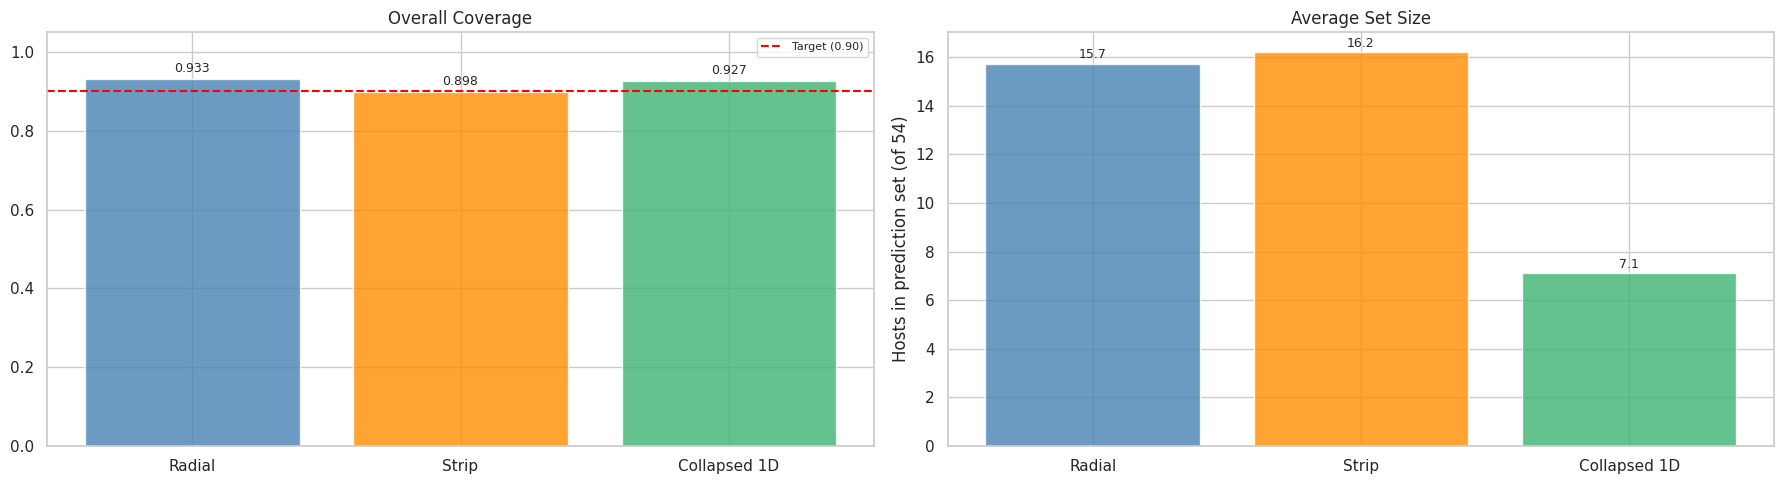

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Overall coverage
ax = axes[0]
vals = [m["coverage"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.legend(fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Average set size
ax = axes[1]
vals = [m["avg_set_size"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.set_title("Average Set Size")
ax.set_ylabel(f"Hosts in prediction set (of {len(all_hosts)})")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

#### Per host coverage results

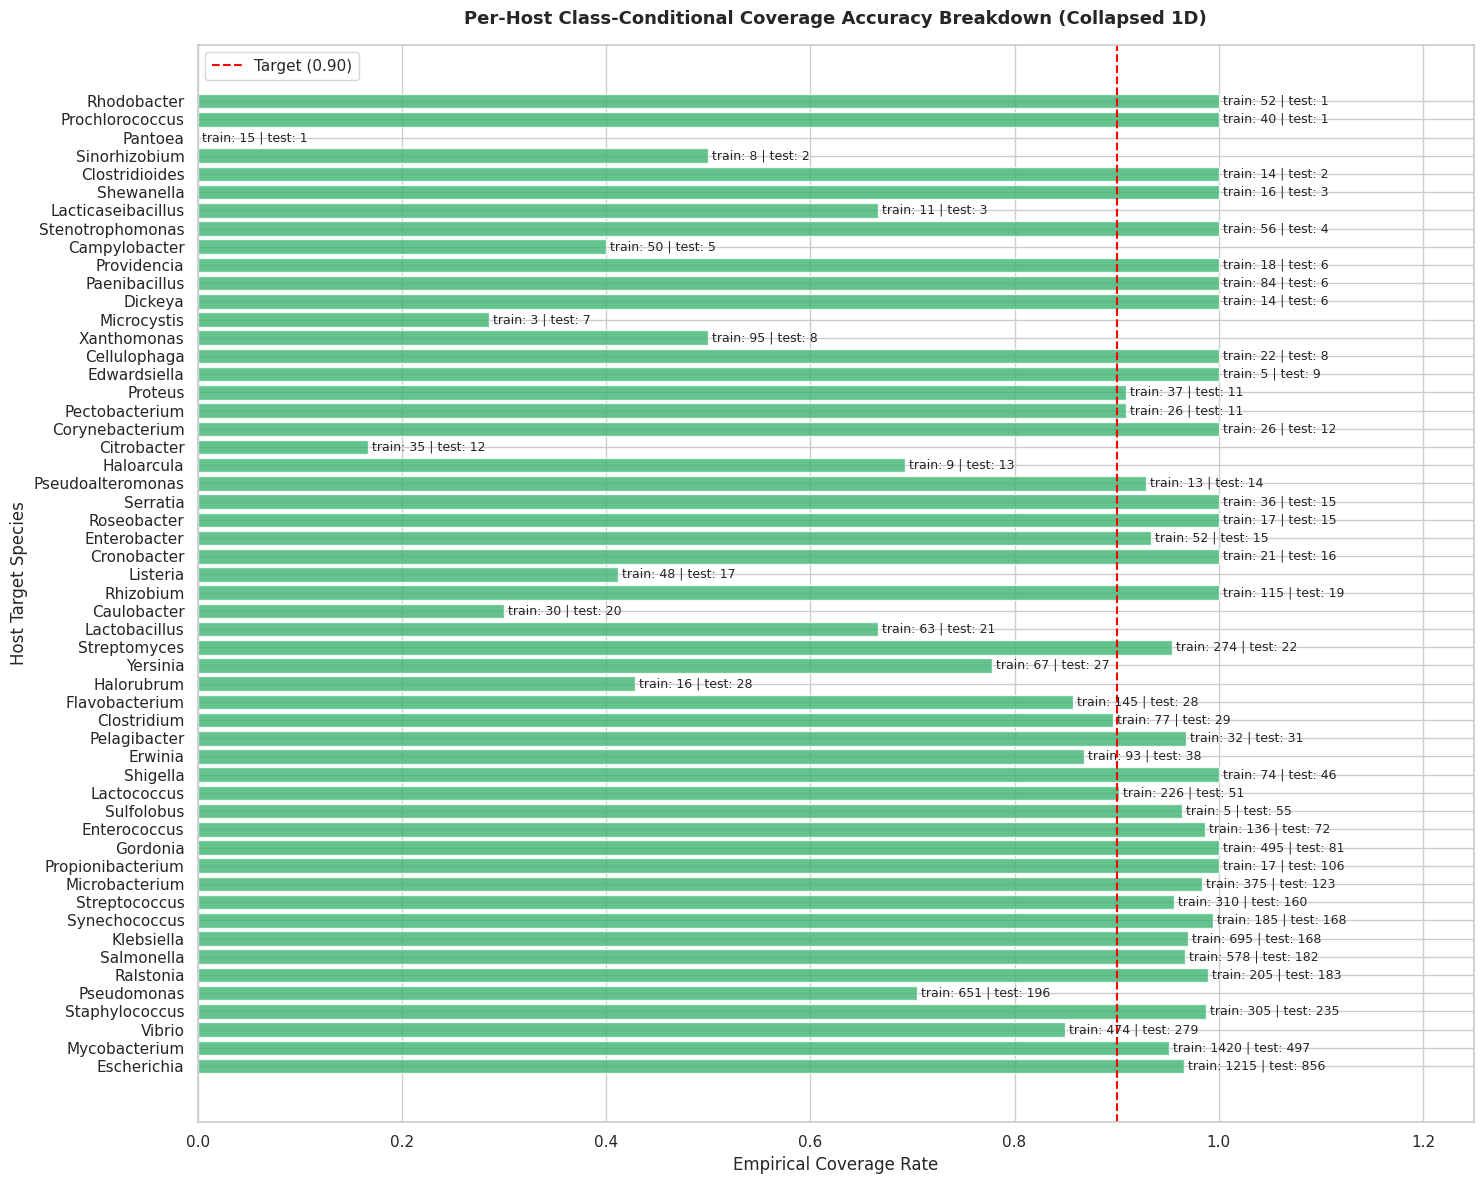

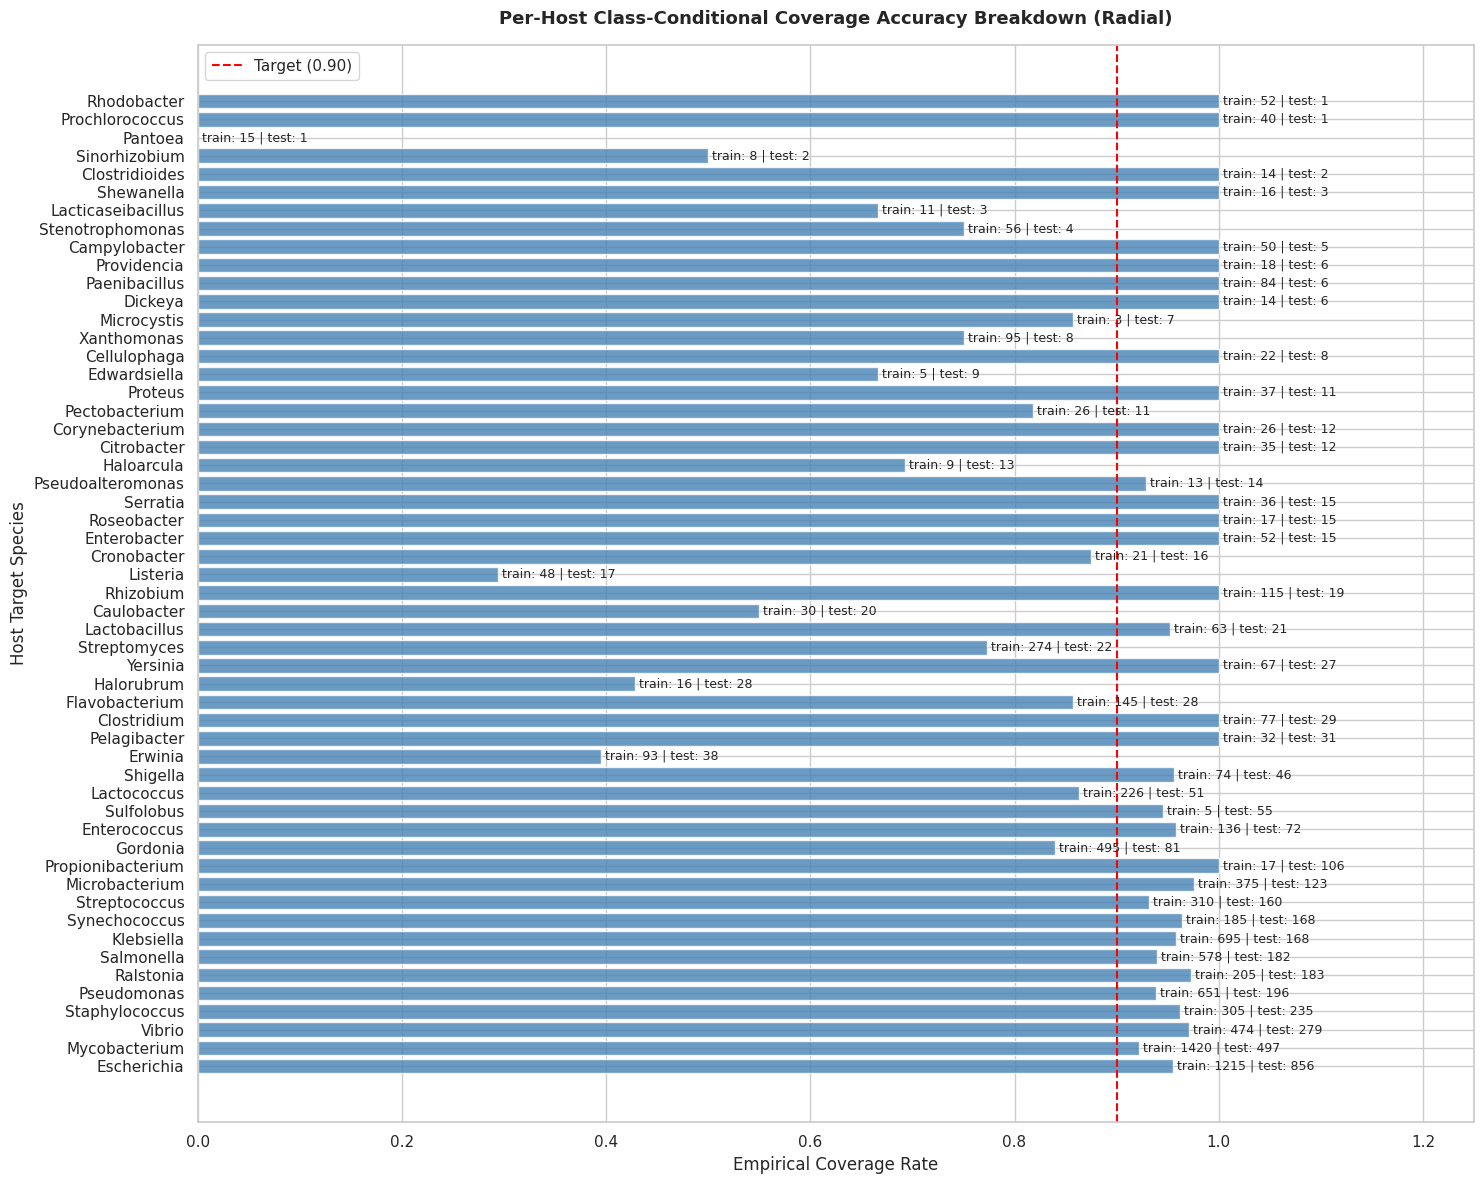

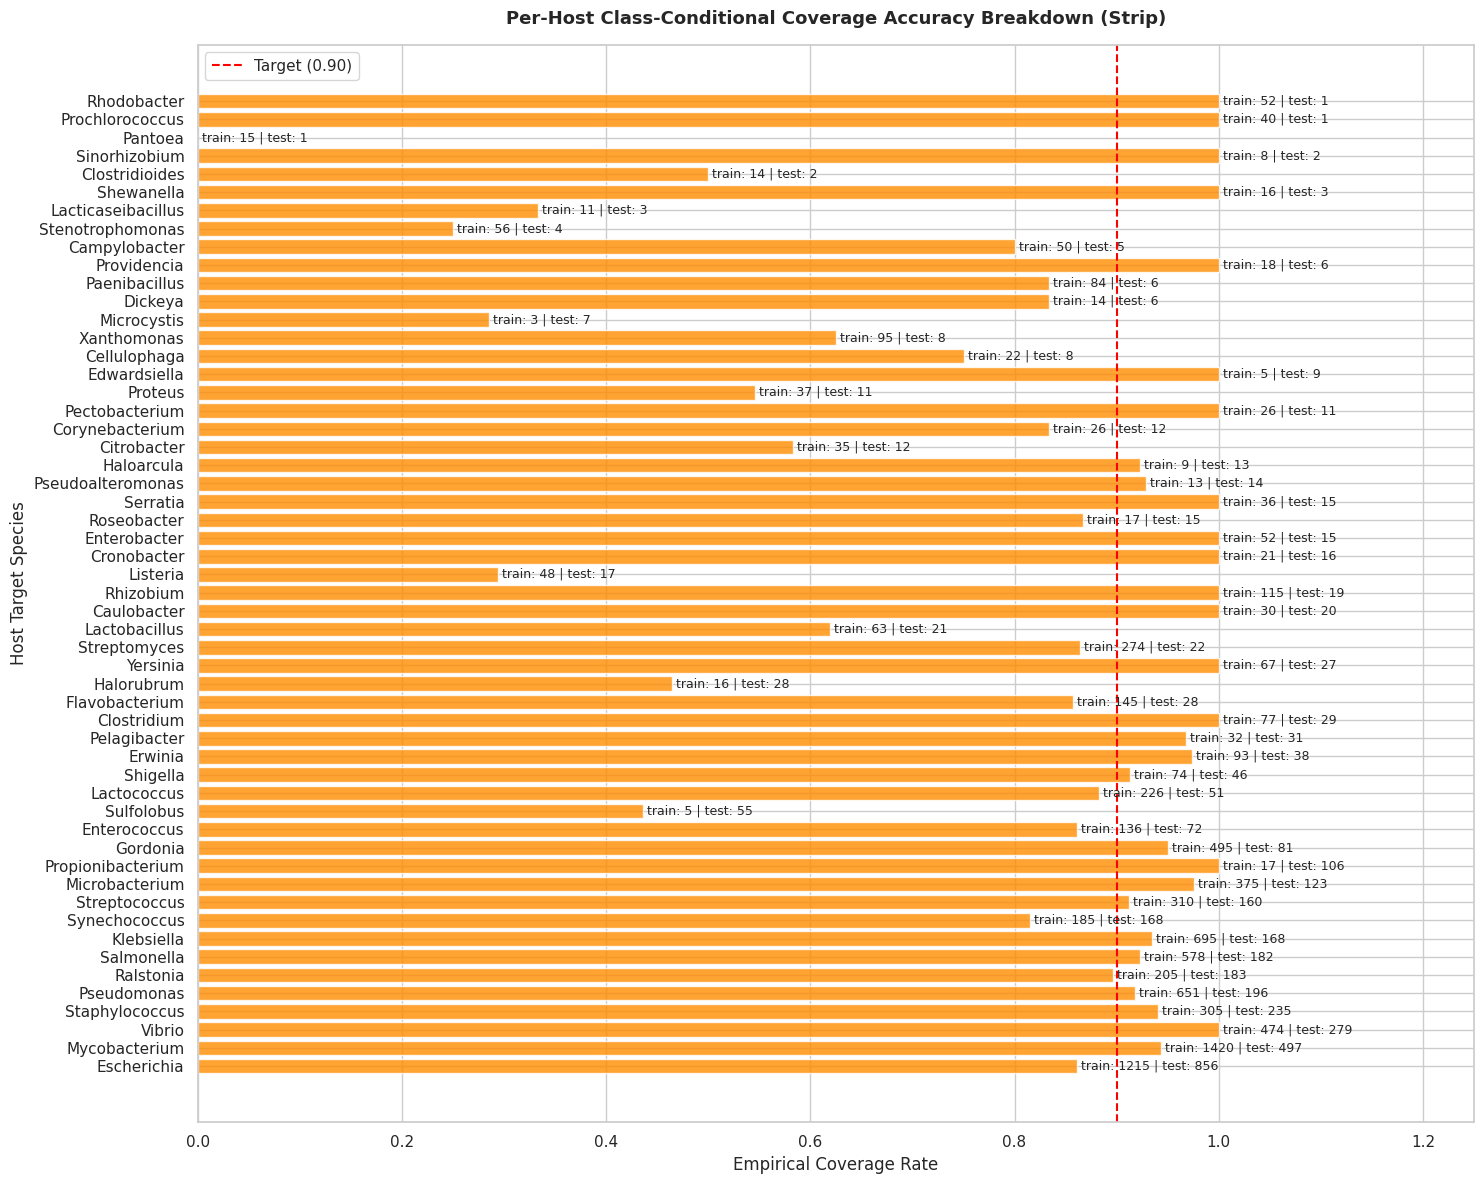

In [26]:
def plot_per_host_coverage(metrics, color, title):
    train_counts = train_df["host"].value_counts().to_dict()
    test_counts = test_df["host"].value_counts().to_dict()
    hosts_sorted = sorted(all_hosts, key=lambda h: test_counts.get(h, 0), reverse=True)

    plt.figure(figsize=(15, 12))
    coverage_vals = [metrics["per_host_coverage"].get(h, 0.0) for h in hosts_sorted]
    bars = plt.barh(hosts_sorted, coverage_vals, color=color, alpha=0.8)
    plt.axvline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
    for bar, h in zip(bars, hosts_sorted):
        plt.text(x=bar.get_width(), y=bar.get_y() + bar.get_height()/2,
                  s=f" train: {train_counts.get(h,0)} | test: {test_counts.get(h,0)}",
                  va="center", ha="left", fontsize=9)
    plt.xlim(0, 1.25)
    plt.title(f"Per-Host Class-Conditional Coverage Accuracy Breakdown ({title})",
              fontsize=13, fontweight="bold", pad=15)
    plt.xlabel("Empirical Coverage Rate"); plt.ylabel("Host Target Species")
    plt.legend(loc="upper left"); plt.tight_layout(); plt.show()

plot_per_host_coverage(collapsed_metrics, "mediumseagreen", "Collapsed 1D")
plot_per_host_coverage(radial_metrics, "steelblue", "Radial")
plot_per_host_coverage(strip_metrics, "darkorange", "Strip")

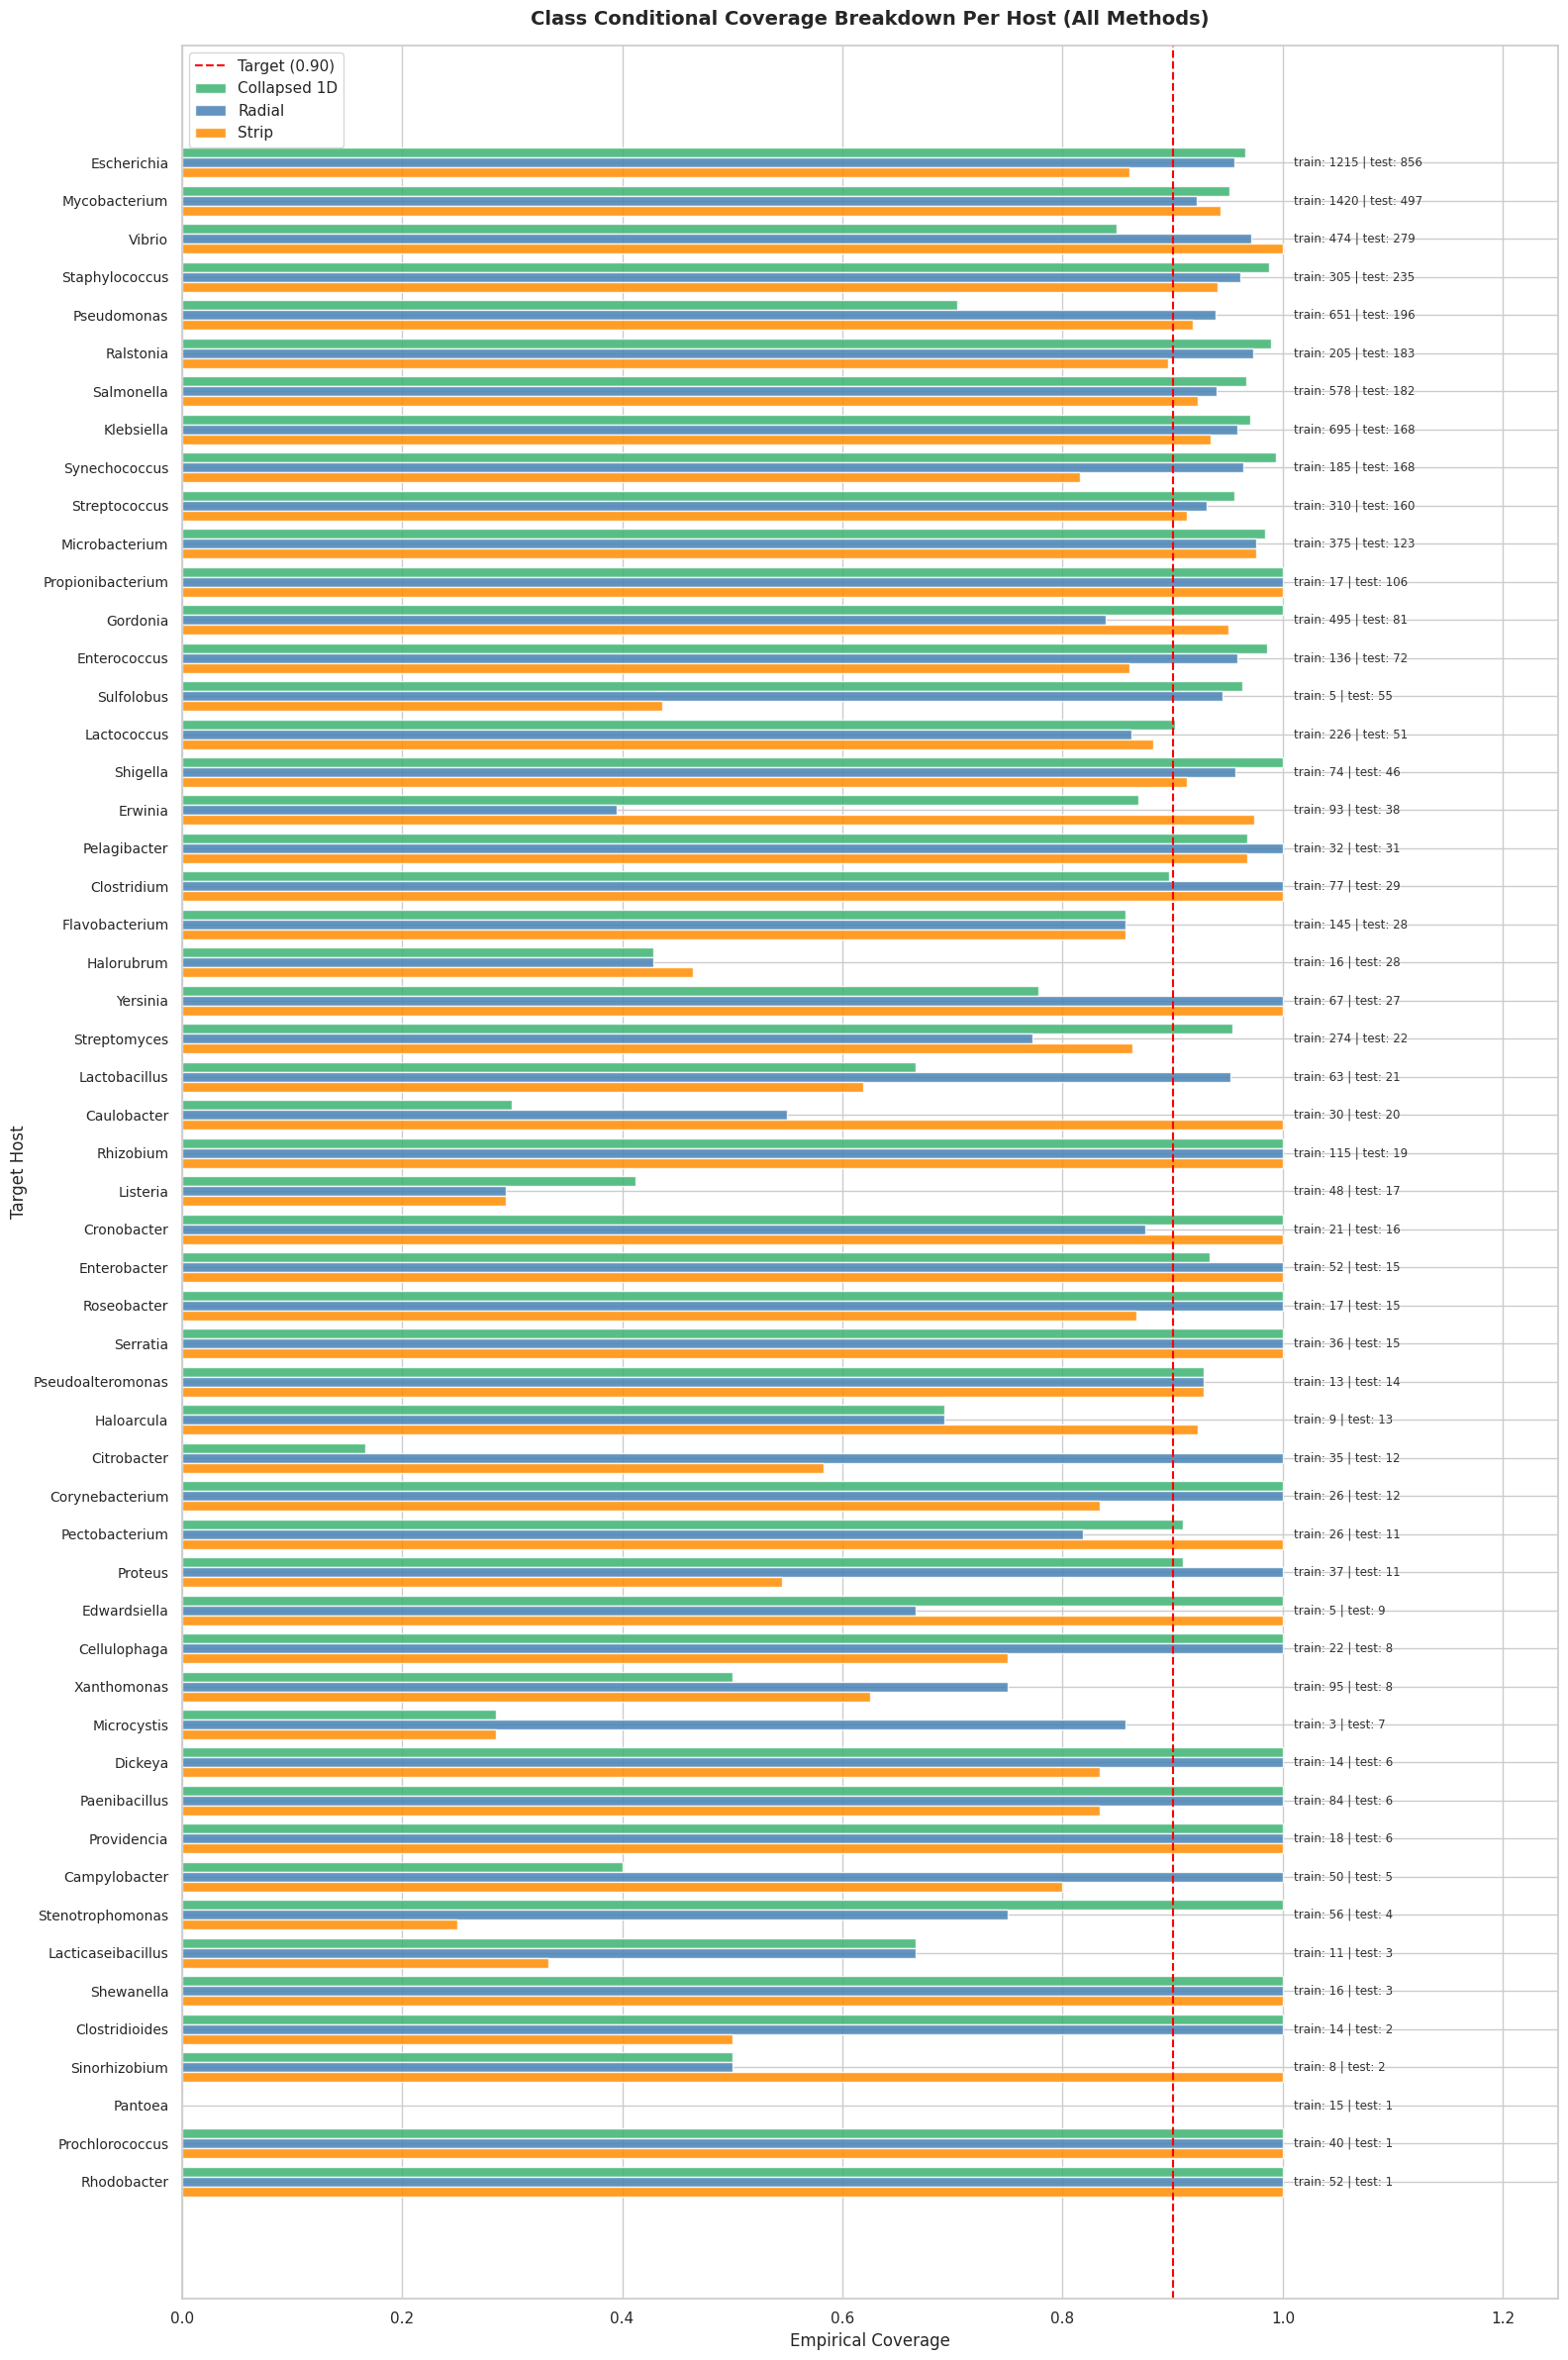

In [60]:
def plot_all_hosts_coverage_combined(all_metrics_dict):
    train_counts = train_df["host"].value_counts().to_dict()
    test_counts = test_df["host"].value_counts().to_dict()
    hosts_sorted = sorted(all_hosts, key=lambda h: test_counts.get(h, 0), reverse=True)

    y_indices = np.arange(len(hosts_sorted))
    bar_height = 0.26  # Height offset for each of the three bars

    # Color palette matching your previous plots
    colors = {
        "Collapsed 1D": "mediumseagreen",
        "Radial": "steelblue",
        "Strip": "darkorange"
    }

    plt.figure(figsize=(16, 24))
    
    # 1. Plot the three grouped bars with manual vertical offsets
    for idx, (name, metrics) in enumerate(all_metrics_dict.items()):
        coverage_vals = [metrics["per_host_coverage"].get(h, 0.0) for h in hosts_sorted]
        offset = (idx - 1) * bar_height  # -0.26 for Collapsed, 0 for Radial, +0.26 for Strip
        plt.barh(y_indices + offset, coverage_vals, height=bar_height, 
                 color=colors[name], label=name, alpha=0.85)

    # 2. Target dashed line at 0.90
    plt.axvline(1 - alpha, color="red", linestyle="--", linewidth=1.5, label=f"Target ({1-alpha:.2f})")

    # 3. Add sample count text at a fixed x position to prevent overlaps
    for i, h in enumerate(hosts_sorted):
        plt.text(x=1.01, y=i, 
                 s=f"train: {train_counts.get(h, 0)} | test: {test_counts.get(h, 0)}",
                 va="center", ha="left", fontsize=8.5, color="#333333")

    plt.yticks(y_indices, hosts_sorted, fontsize=10)
    plt.gca().invert_yaxis()  # Most frequent hosts at the top
    plt.xlim(0, 1.25)
    plt.xlabel("Empirical Coverage", fontsize=12)
    plt.ylabel("Target Host", fontsize=12)
    plt.title("Class Conditional Coverage Breakdown Per Host (All Methods)", 
              fontsize=14, fontweight="bold", pad=15)
    plt.legend(loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()

# Call the function with all three metric dictionaries
plot_all_hosts_coverage_combined({
    "Collapsed 1D": collapsed_metrics,
    "Radial": radial_metrics,
    "Strip": strip_metrics
})

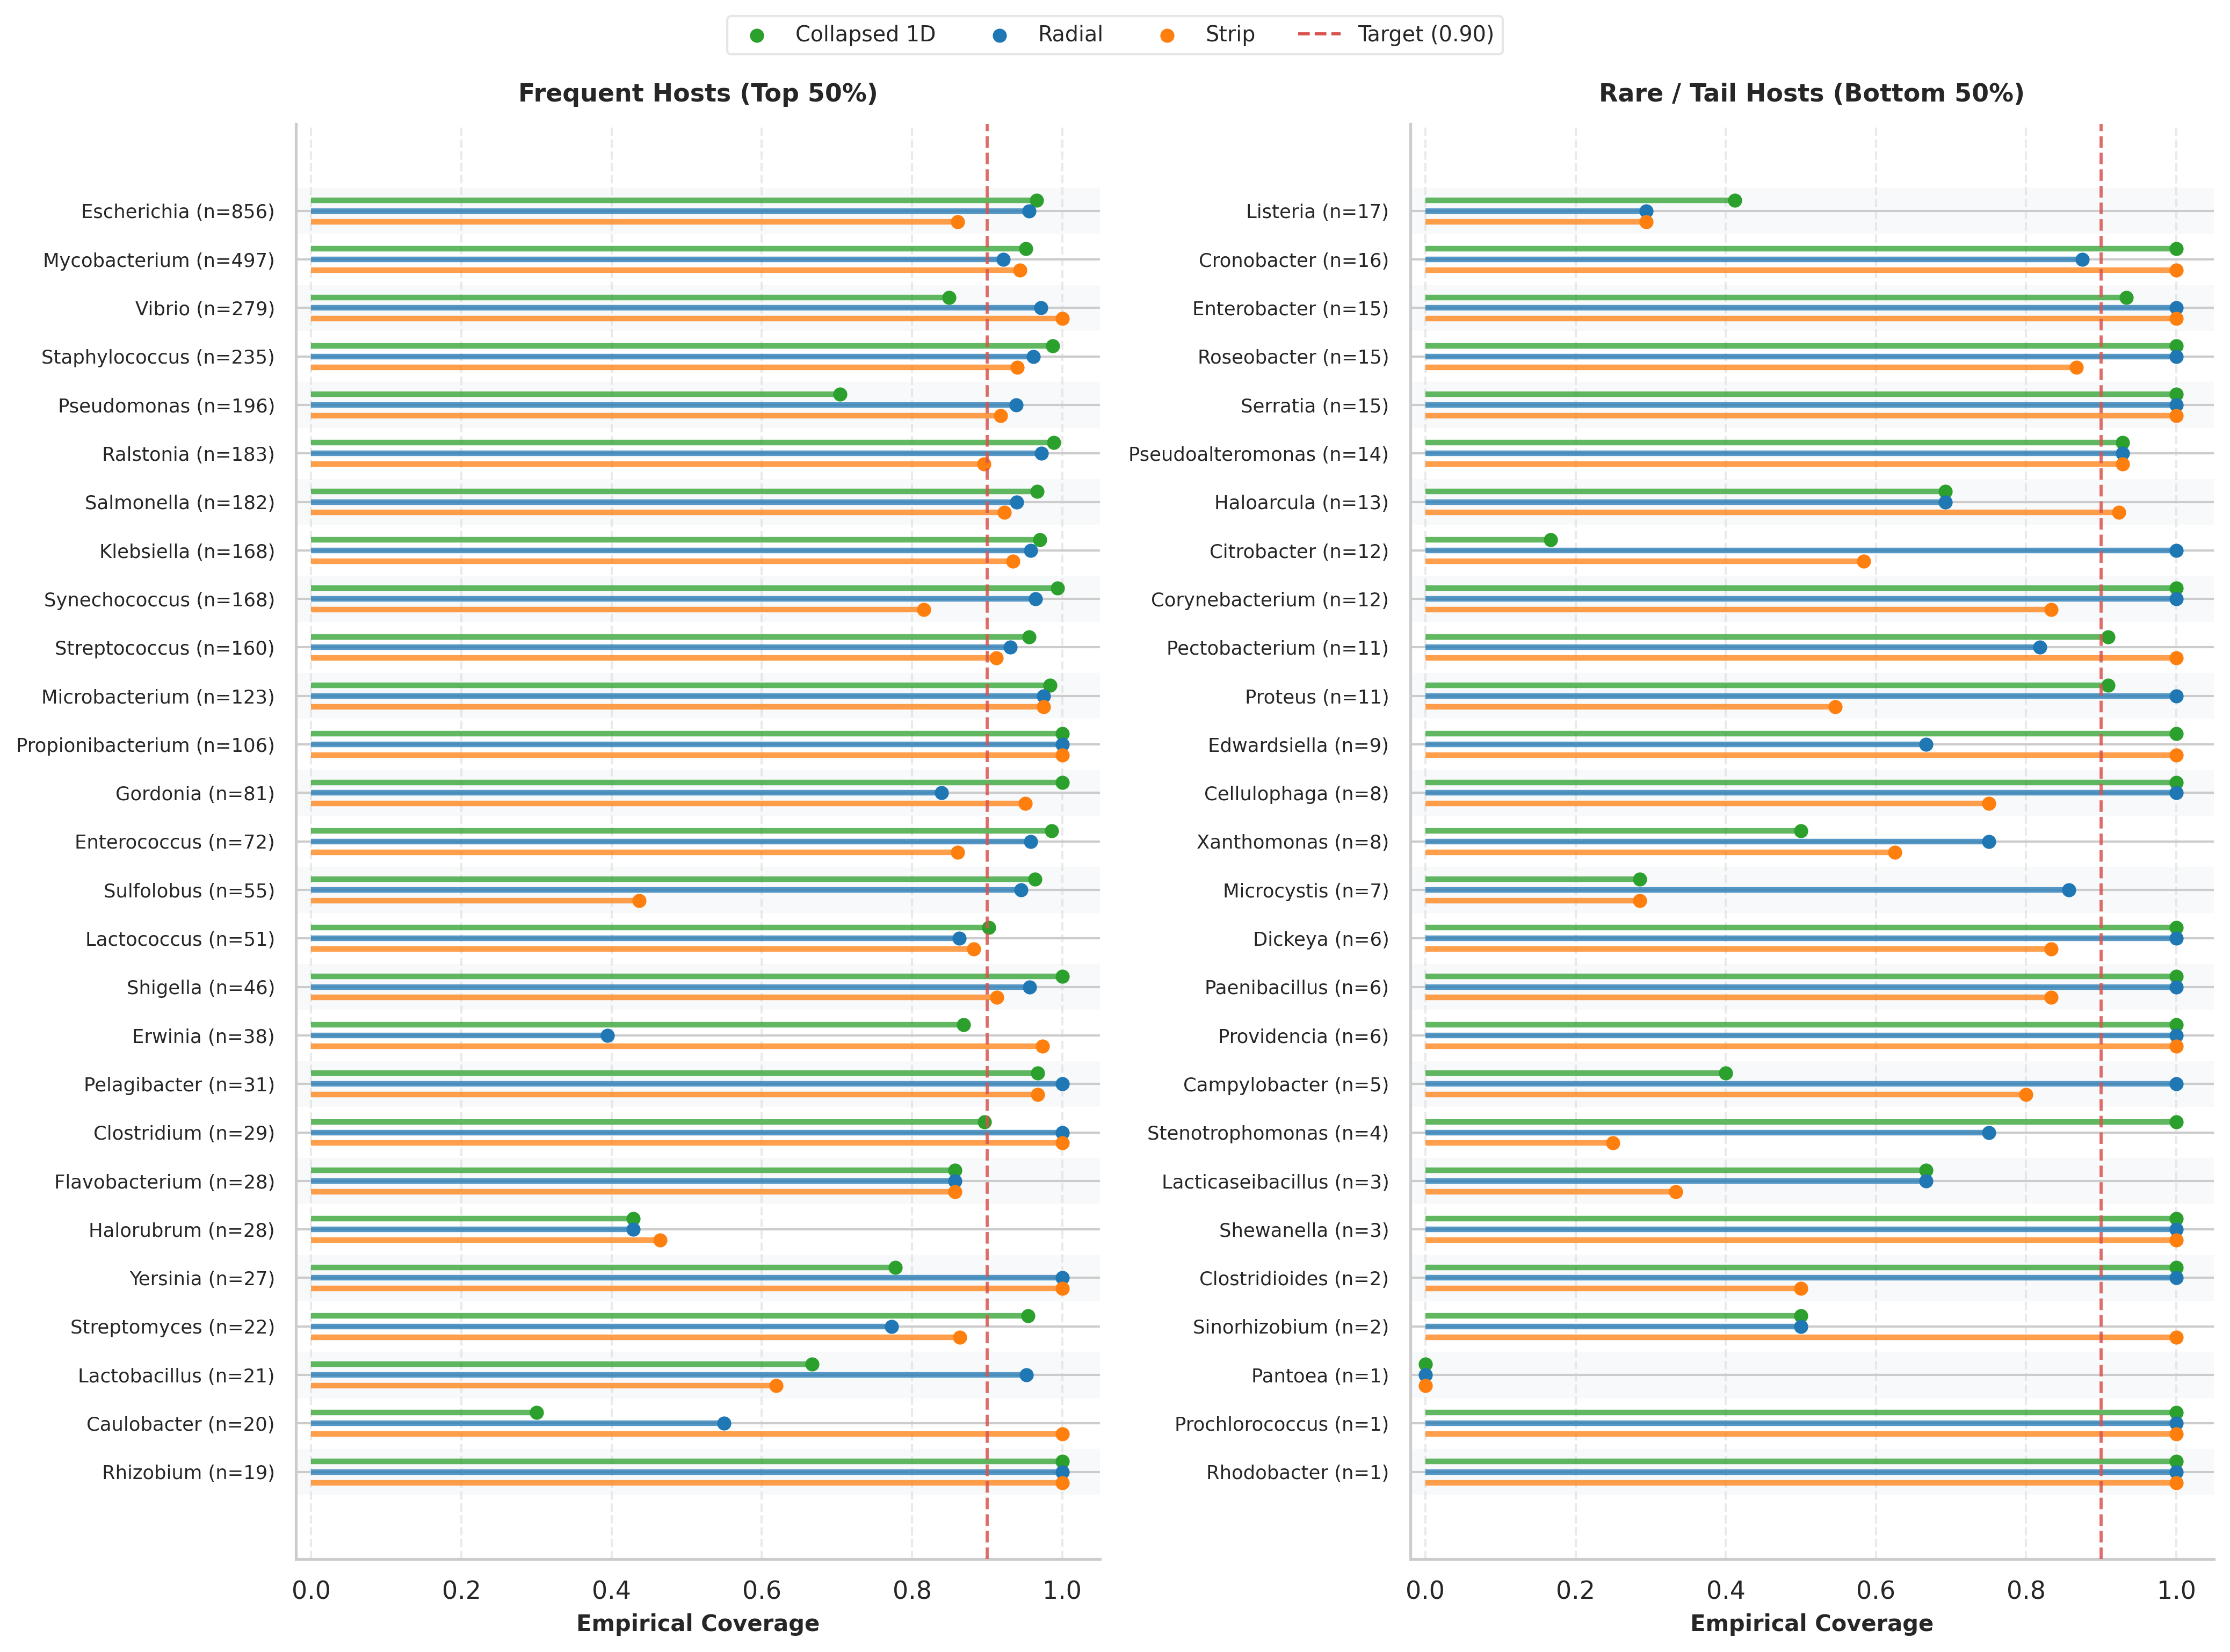

In [66]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_hosts_coverage_combined_split(all_metrics_dict, alpha=0.1):
    train_counts = train_df["host"].value_counts().to_dict()
    test_counts = test_df["host"].value_counts().to_dict()
    hosts_sorted = sorted(all_hosts, key=lambda h: test_counts.get(h, 0), reverse=True)

    # Split hosts across two balanced panels
    mid = int(np.ceil(len(hosts_sorted) / 2))
    panels = [
        ("Frequent Hosts (Top 50%)", hosts_sorted[:mid]),
        ("Rare / Tail Hosts (Bottom 50%)", hosts_sorted[mid:])
    ]

    colors = {
        "Collapsed 1D": "#2ca02c",
        "Radial": "#1f77b4",
        "Strip": "#ff7f0e"
    }
    offsets = {"Collapsed 1D": -0.22, "Radial": 0.0, "Strip": 0.22}

    # Standard landscape proportion fits perfectly on an A4/Letter page
    fig, axes = plt.subplots(1, 2, figsize=(14, 10), sharex=True, dpi=300)

    for ax, (panel_title, host_subset) in zip(axes, panels):
        y_pos = np.arange(len(host_subset))
        
        # Subtle alternating background bands
        for idx in range(len(host_subset)):
            if idx % 2 == 0:
                ax.axhspan(idx - 0.45, idx + 0.45, color="#f8f9fa", zorder=0)

        # Plot grouped points + connectors (cleaner and thinner than wide bars)
        for method_name, metrics in all_metrics_dict.items():
            vals = [metrics["per_host_coverage"].get(h, 0.0) for h in host_subset]
            y_shifted = y_pos + offsets[method_name]
            
            # Baseline stem and marker
            ax.hlines(y_shifted, 0, vals, color=colors[method_name], alpha=0.75, linewidth=2.5, zorder=2)
            ax.scatter(vals, y_shifted, color=colors[method_name], label=method_name, s=28, zorder=3)
            

        # Target coverage line
        target = 1.0 - alpha
        ax.axvline(target, color="#d9534f", linestyle="--", linewidth=1.4, alpha=0.85, zorder=4)

        # Integrated labels: Genus name + sample support on the y-axis directly
        formatted_labels = [
            f"{h} (n={test_counts.get(h, 0)})" for h in host_subset
        ]
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(formatted_labels, fontsize=8.5)
        ax.invert_yaxis()
        ax.set_xlim(-0.02, 1.05)
        ax.set_xlabel("Empirical Coverage", fontsize=10, fontweight="bold")
        ax.set_title(panel_title, fontsize=11, fontweight="bold", pad=10)
        ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=1)
        ax.spines[["top", "right"]].set_visible(False)

    # Single unified horizontal legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    # Deduplicate legend items
    by_label = dict(zip(labels, handles))
    by_label[f"Target ({1-alpha:.2f})"] = plt.Line2D([0], [0], color="#d9534f", linestyle="--", linewidth=1.4)
    
    fig.legend(
        by_label.values(), by_label.keys(),
        loc="upper center", bbox_to_anchor=(0.5, 1.03),
        ncol=4, fontsize=9.5, frameon=True, facecolor="white", edgecolor="#e0e0e0"
    )

    plt.tight_layout()
    plt.savefig("coverage_breakdown_fixed.pdf", bbox_inches="tight")
    plt.show()

# Run
plot_all_hosts_coverage_combined_split({
    "Collapsed 1D": collapsed_metrics,
    "Radial": radial_metrics,
    "Strip": strip_metrics
}, alpha=0.10)

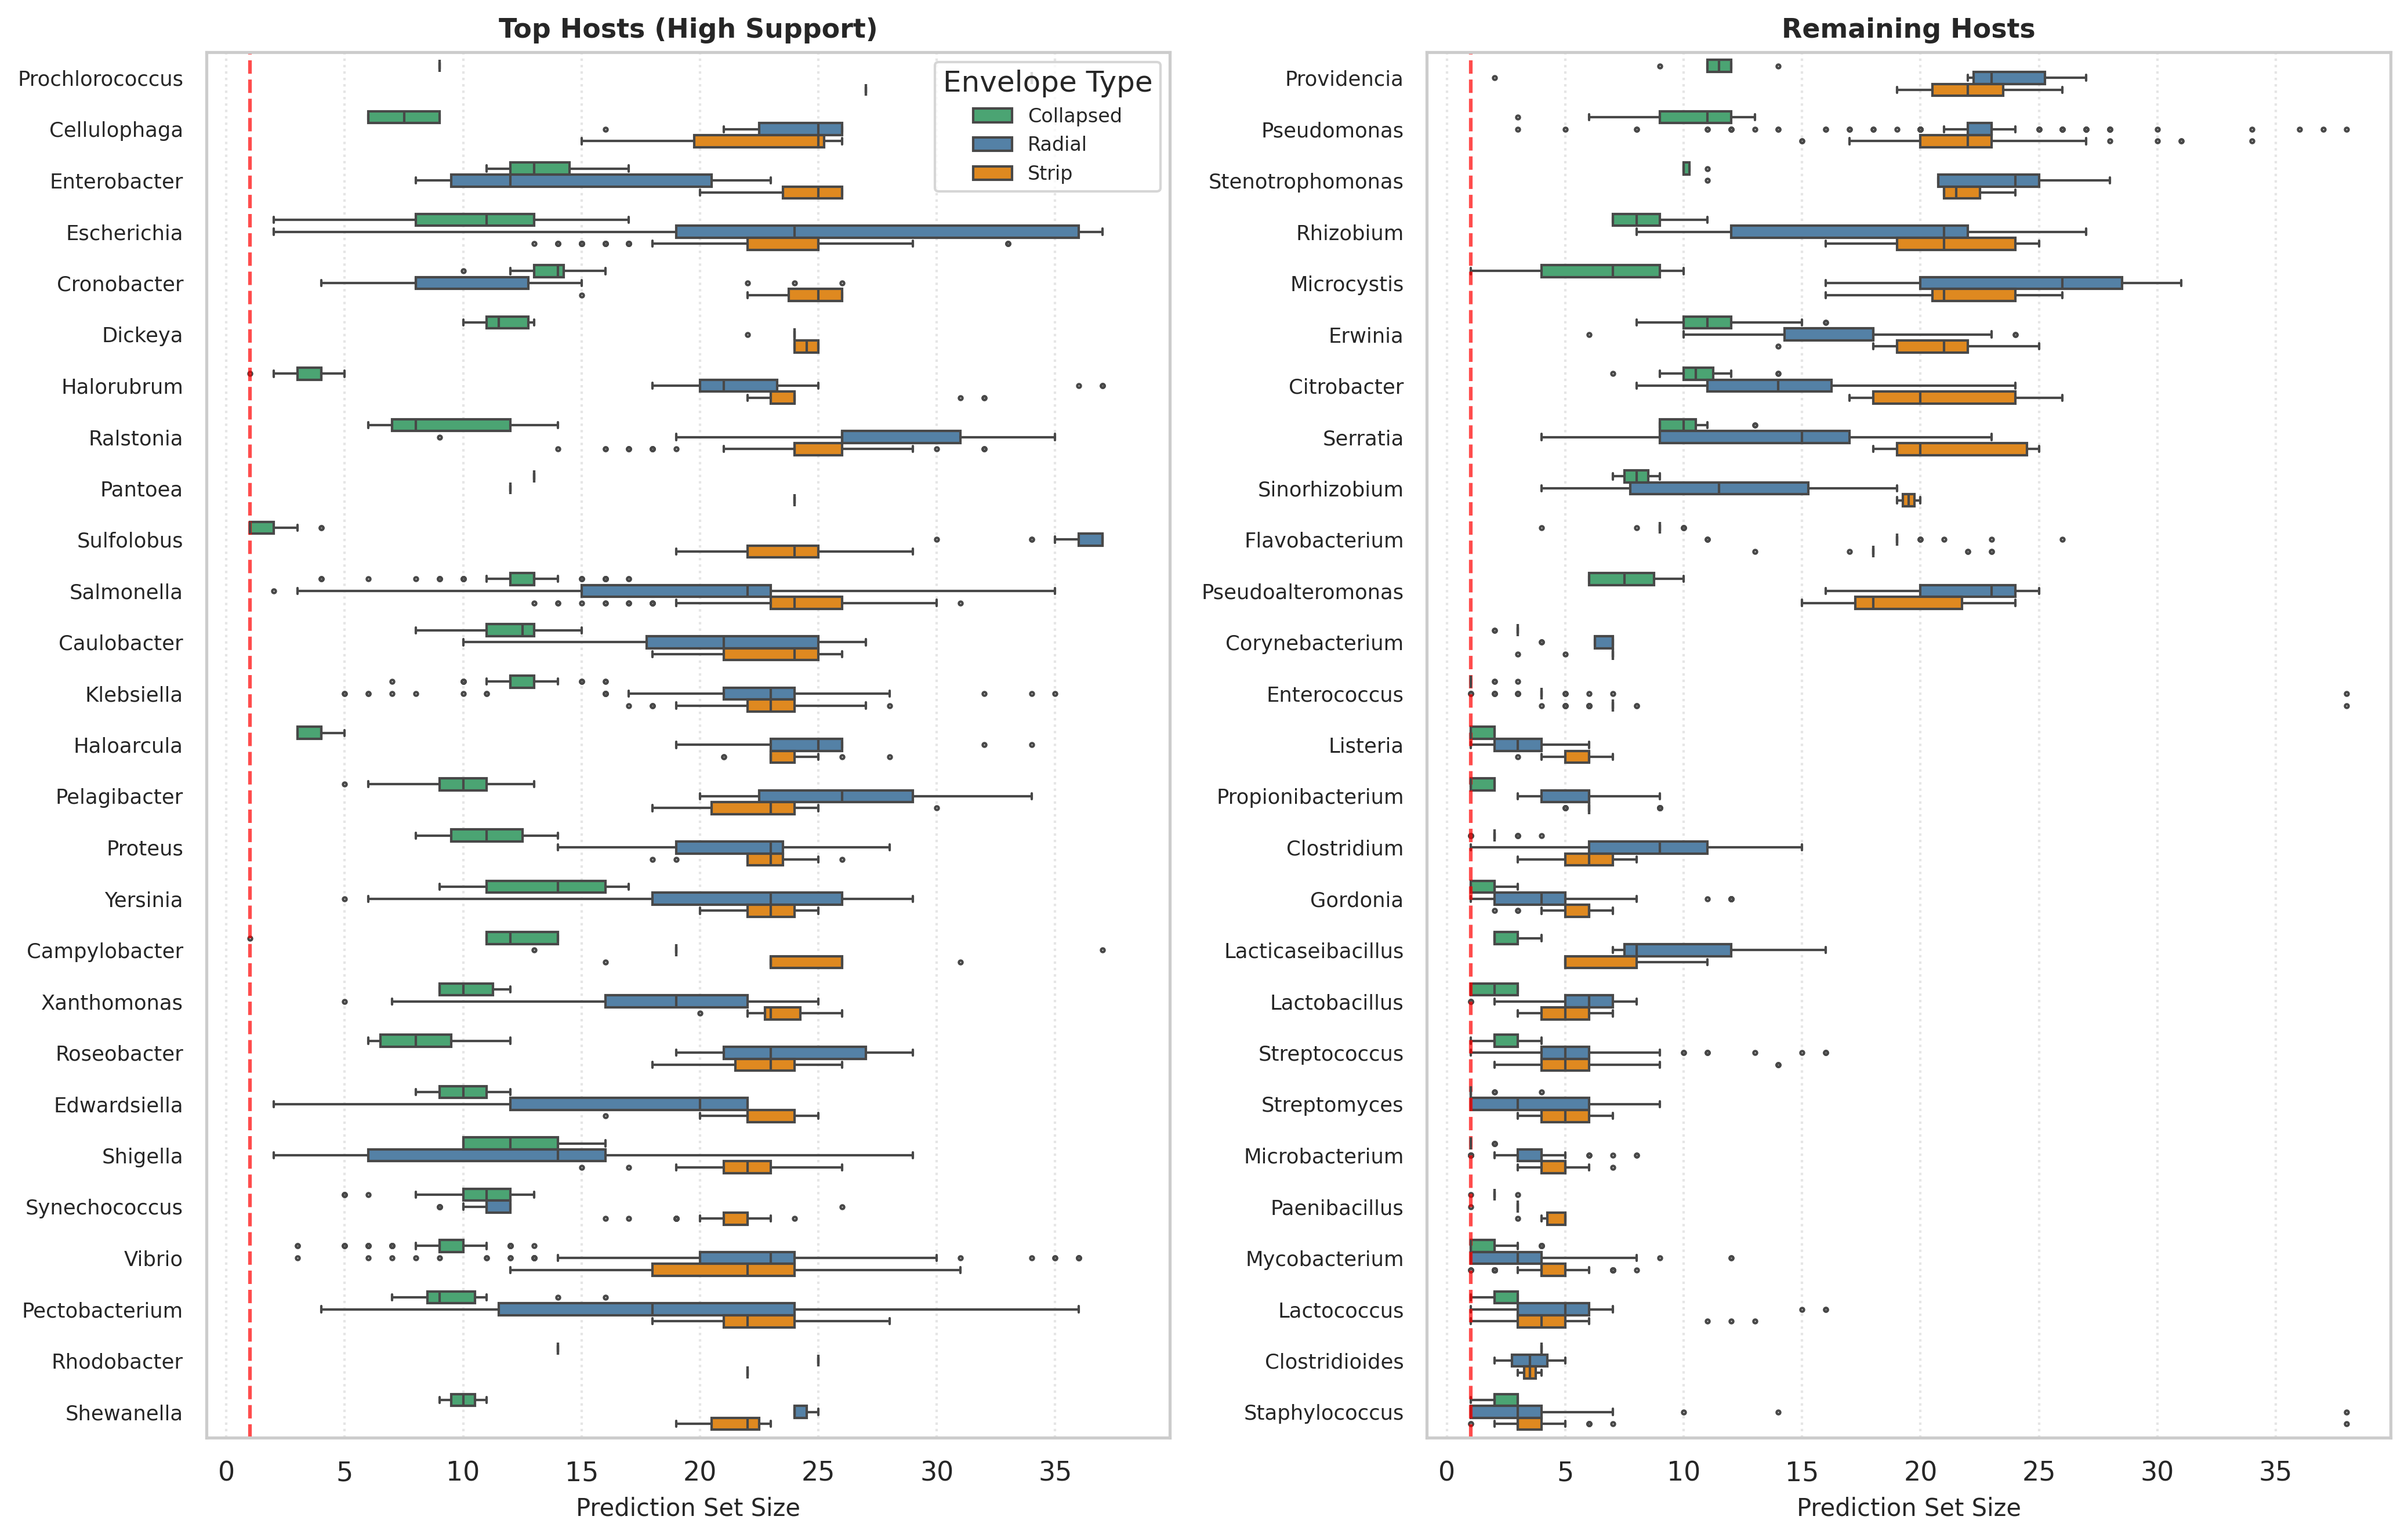

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Assuming df_all_sets is already prepared
# order_ref contains all host names sorted by frequency/median

mid = len(order_ref) // 2
splits = [
    ("Top Hosts (High Support)", order_ref[:mid]),
    ("Remaining Hosts", order_ref[mid:]),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharex=True, dpi=300)

palette = {"Collapsed": "mediumseagreen", "Radial": "steelblue", "Strip": "darkorange"}

for ax, (title, hosts_subset) in zip(axes, splits):
    sub_df = df_all_sets[df_all_sets["True Host"].isin(hosts_subset)]

    sns.boxplot(
        data=sub_df,
        x="Set Size",
        y="True Host",
        hue="Envelope Type",
        order=hosts_subset,
        palette=palette,
        fliersize=1.5,
        width=0.7,
        ax=ax,
    )

    ax.axvline(x=1, color="red", linestyle="--", alpha=0.7)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("Prediction Set Size", fontsize=10)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.grid(axis="x", linestyle=":", alpha=0.5)

    # Keep legend on first panel only, remove from second
    if ax == axes[0]:
        ax.legend(title="Envelope Type", fontsize=8, loc="upper right")
    else:
        ax.legend_.remove()

plt.tight_layout()
plt.savefig("split_host_plot.pdf", bbox_inches="tight")
plt.show()

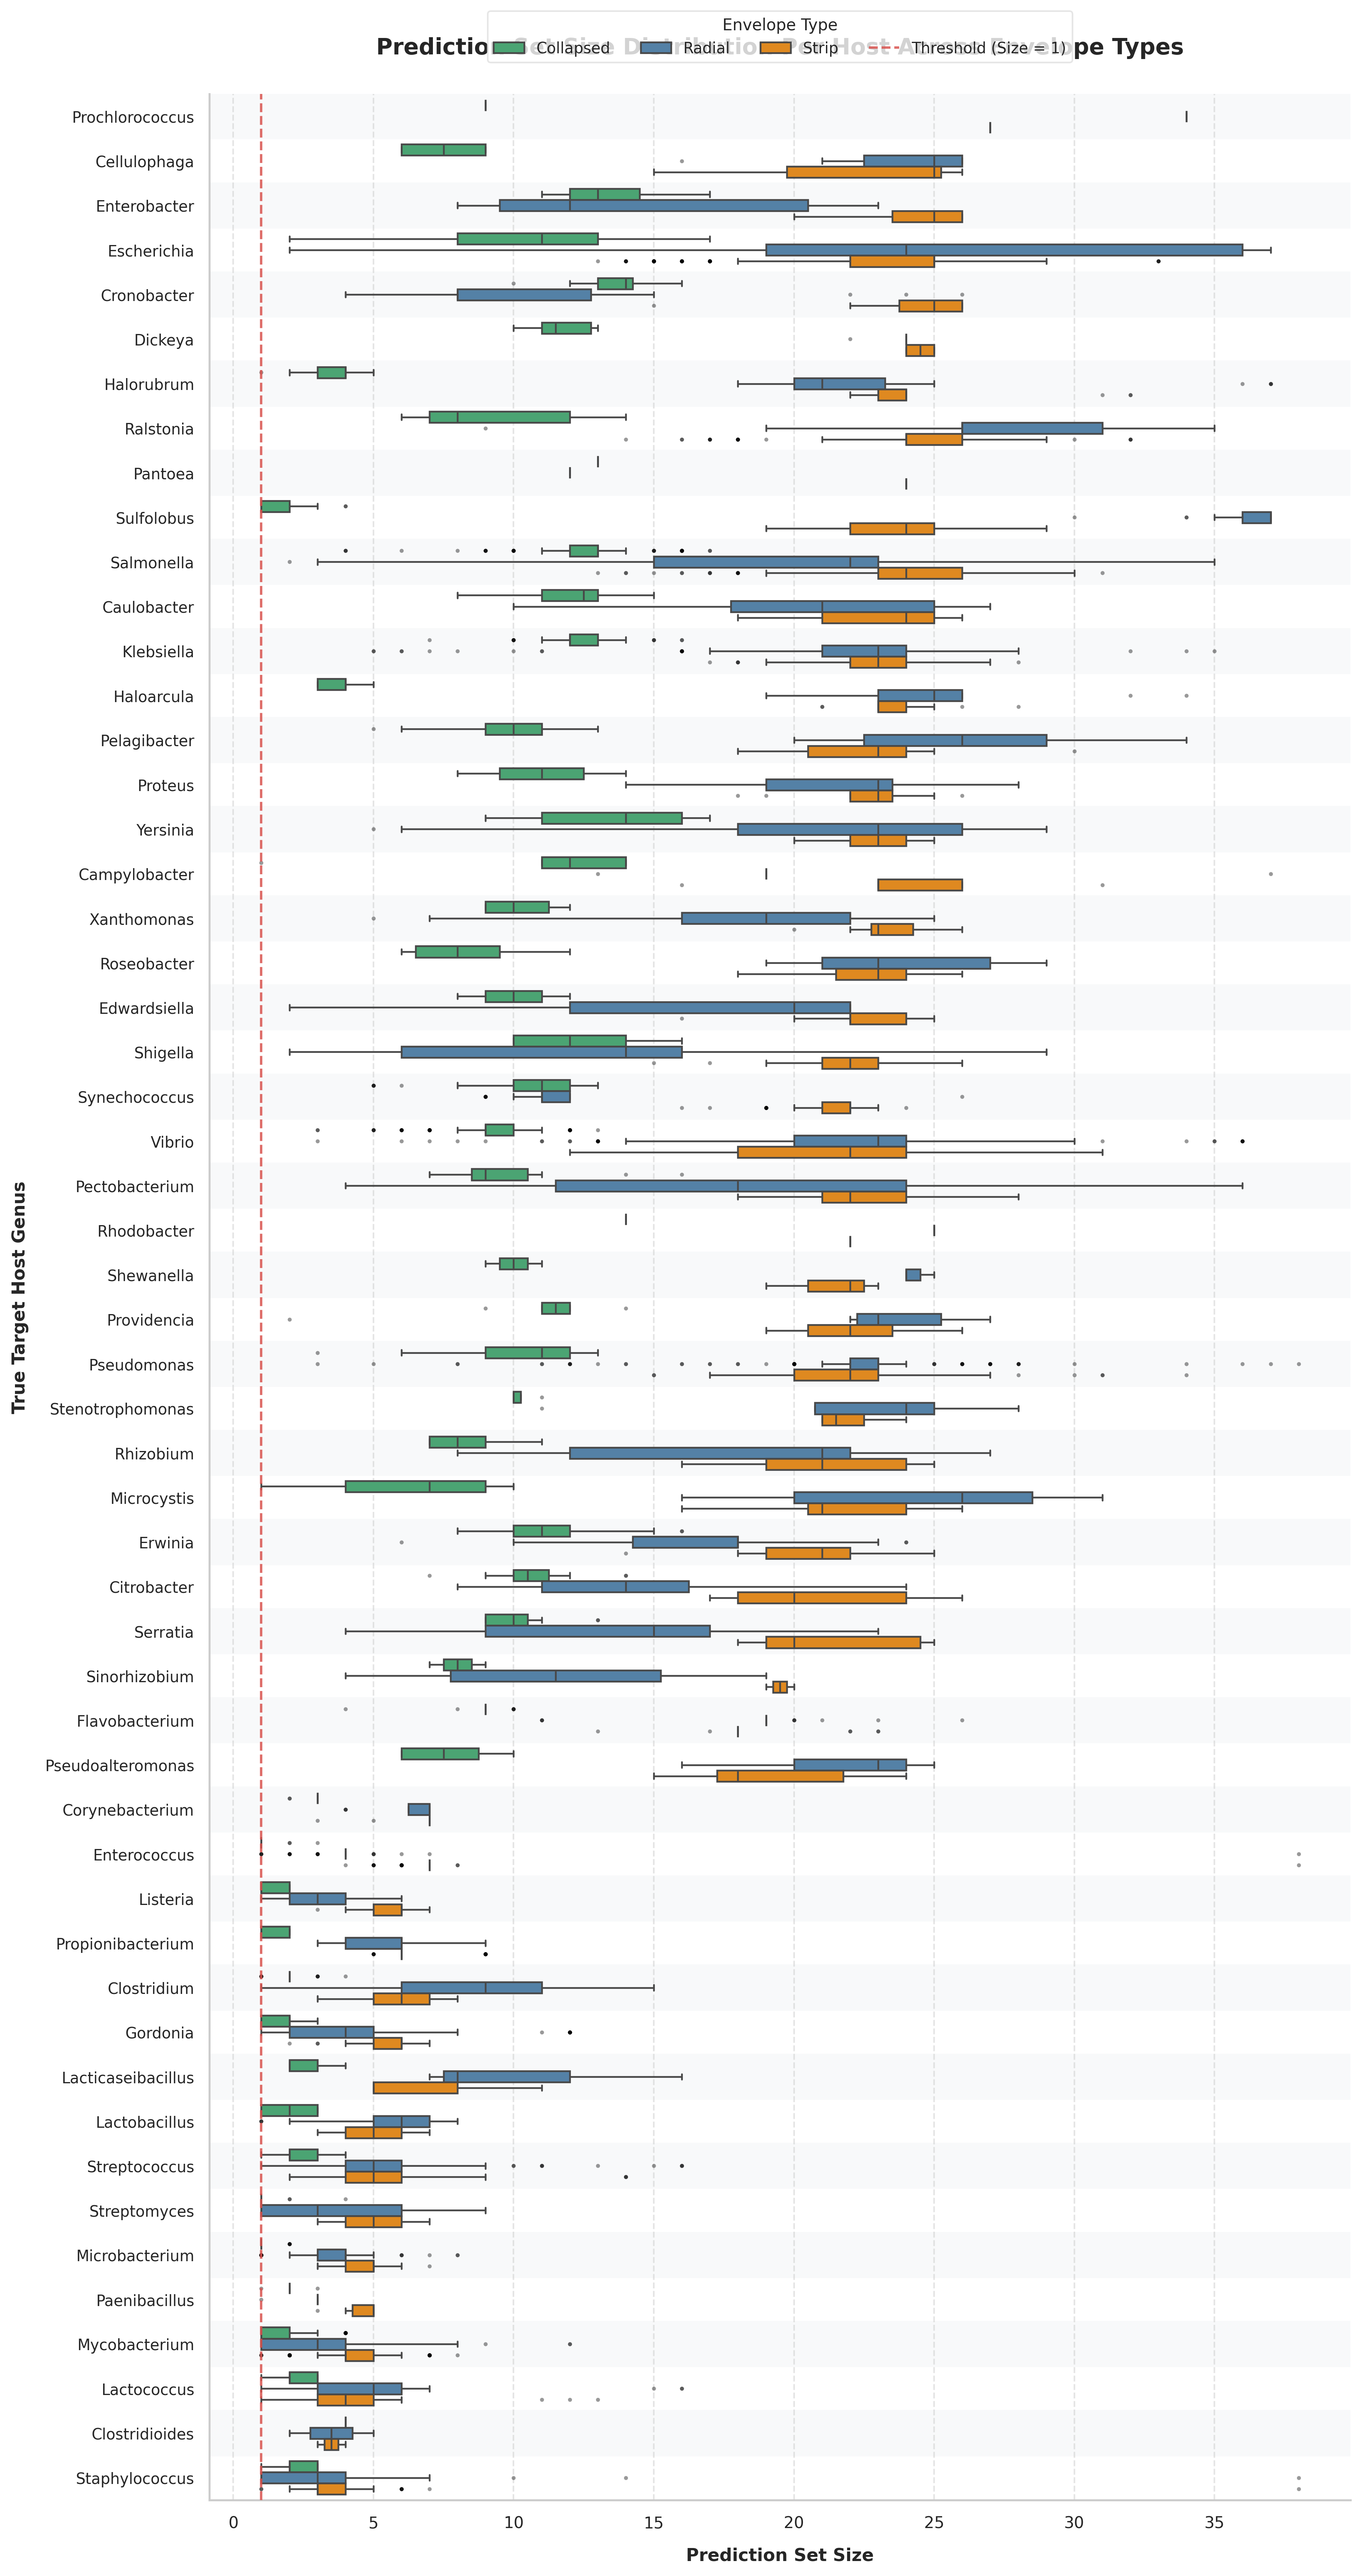

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

methods = ["collapsed", "radial", "strip"]
method_display = {"collapsed": "Collapsed", "radial": "Radial", "strip": "Strip"}
palette = {"Collapsed": "mediumseagreen", "Radial": "steelblue", "Strip": "darkorange"}

# 1. Transform data into long format
data_list = []
for method in methods:
    for h in all_hosts:
        sizes = [
            len(r["prediction_set"])
            for r, true_h in zip(results_by_method[method], test_labels)
            if true_h == h
        ]
        for s in sizes if sizes else [np.nan]:
            data_list.append(
                {"True Host": h, "Set Size": s, "Envelope Type": method_display[method]}
            )

df_all_sets = pd.DataFrame(data_list)

# 2. Sort hosts cleanly by median of 'Strip' (or fall back if empty)
order_ref = (
    df_all_sets[df_all_sets["Envelope Type"] == "Strip"]
    .groupby("True Host")["Set Size"]
    .median()
    .sort_values(ascending=False)
    .index
)

# 3. Dynamic figure height to guarantee every label has room
n_hosts = len(order_ref)
fig_height = max(10, n_hosts * 0.38 + 2.0)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)

# Alternating row background for effortless row-scanning
for idx in range(n_hosts):
    if idx % 2 == 0:
        ax.axhspan(idx - 0.5, idx + 0.5, color="#f8f9fa", zorder=0)

# 4. Boxplot
sns.boxplot(
    data=df_all_sets,
    x="Set Size",
    y="True Host",
    hue="Envelope Type",
    order=order_ref,
    palette=palette,
    fliersize=2.5,
    flierprops={"alpha": 0.4, "markerfacecolor": "black", "markeredgewidth": 0},
    linewidth=1.1,
    width=0.75,
    ax=ax,
    zorder=2,
)

# Reference line
thresh_line = ax.axvline(
    x=1, color="#d9534f", linestyle="--", linewidth=1.5, alpha=0.85, zorder=3
)

# 5. Styling & Typography
ax.set_title(
    "Prediction Set Size Distribution Per Host Across Envelope Types",
    fontsize=14,
    fontweight="bold",
    pad=25,
)
ax.set_xlabel("Prediction Set Size", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel("True Target Host Genus", fontsize=11, fontweight="bold", labelpad=10)

ax.tick_params(axis="y", labelsize=9.5)
ax.tick_params(axis="x", labelsize=10)
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=1)
sns.despine(top=True, right=True)

# 6. Put the legend neatly at the top outside the chart
handles, labels = ax.get_legend_handles_labels()
handles.append(thresh_line)
labels.append("Threshold (Size = 1)")

ax.legend(
    handles=handles,
    labels=labels,
    title="Envelope Type",
    title_fontsize="10",
    fontsize=9.5,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
)

plt.tight_layout()
plt.savefig("improved_host_plot.pdf", bbox_inches="tight")  # Vector PDF for sharp report rendering
plt.show()

#### Set size distribution

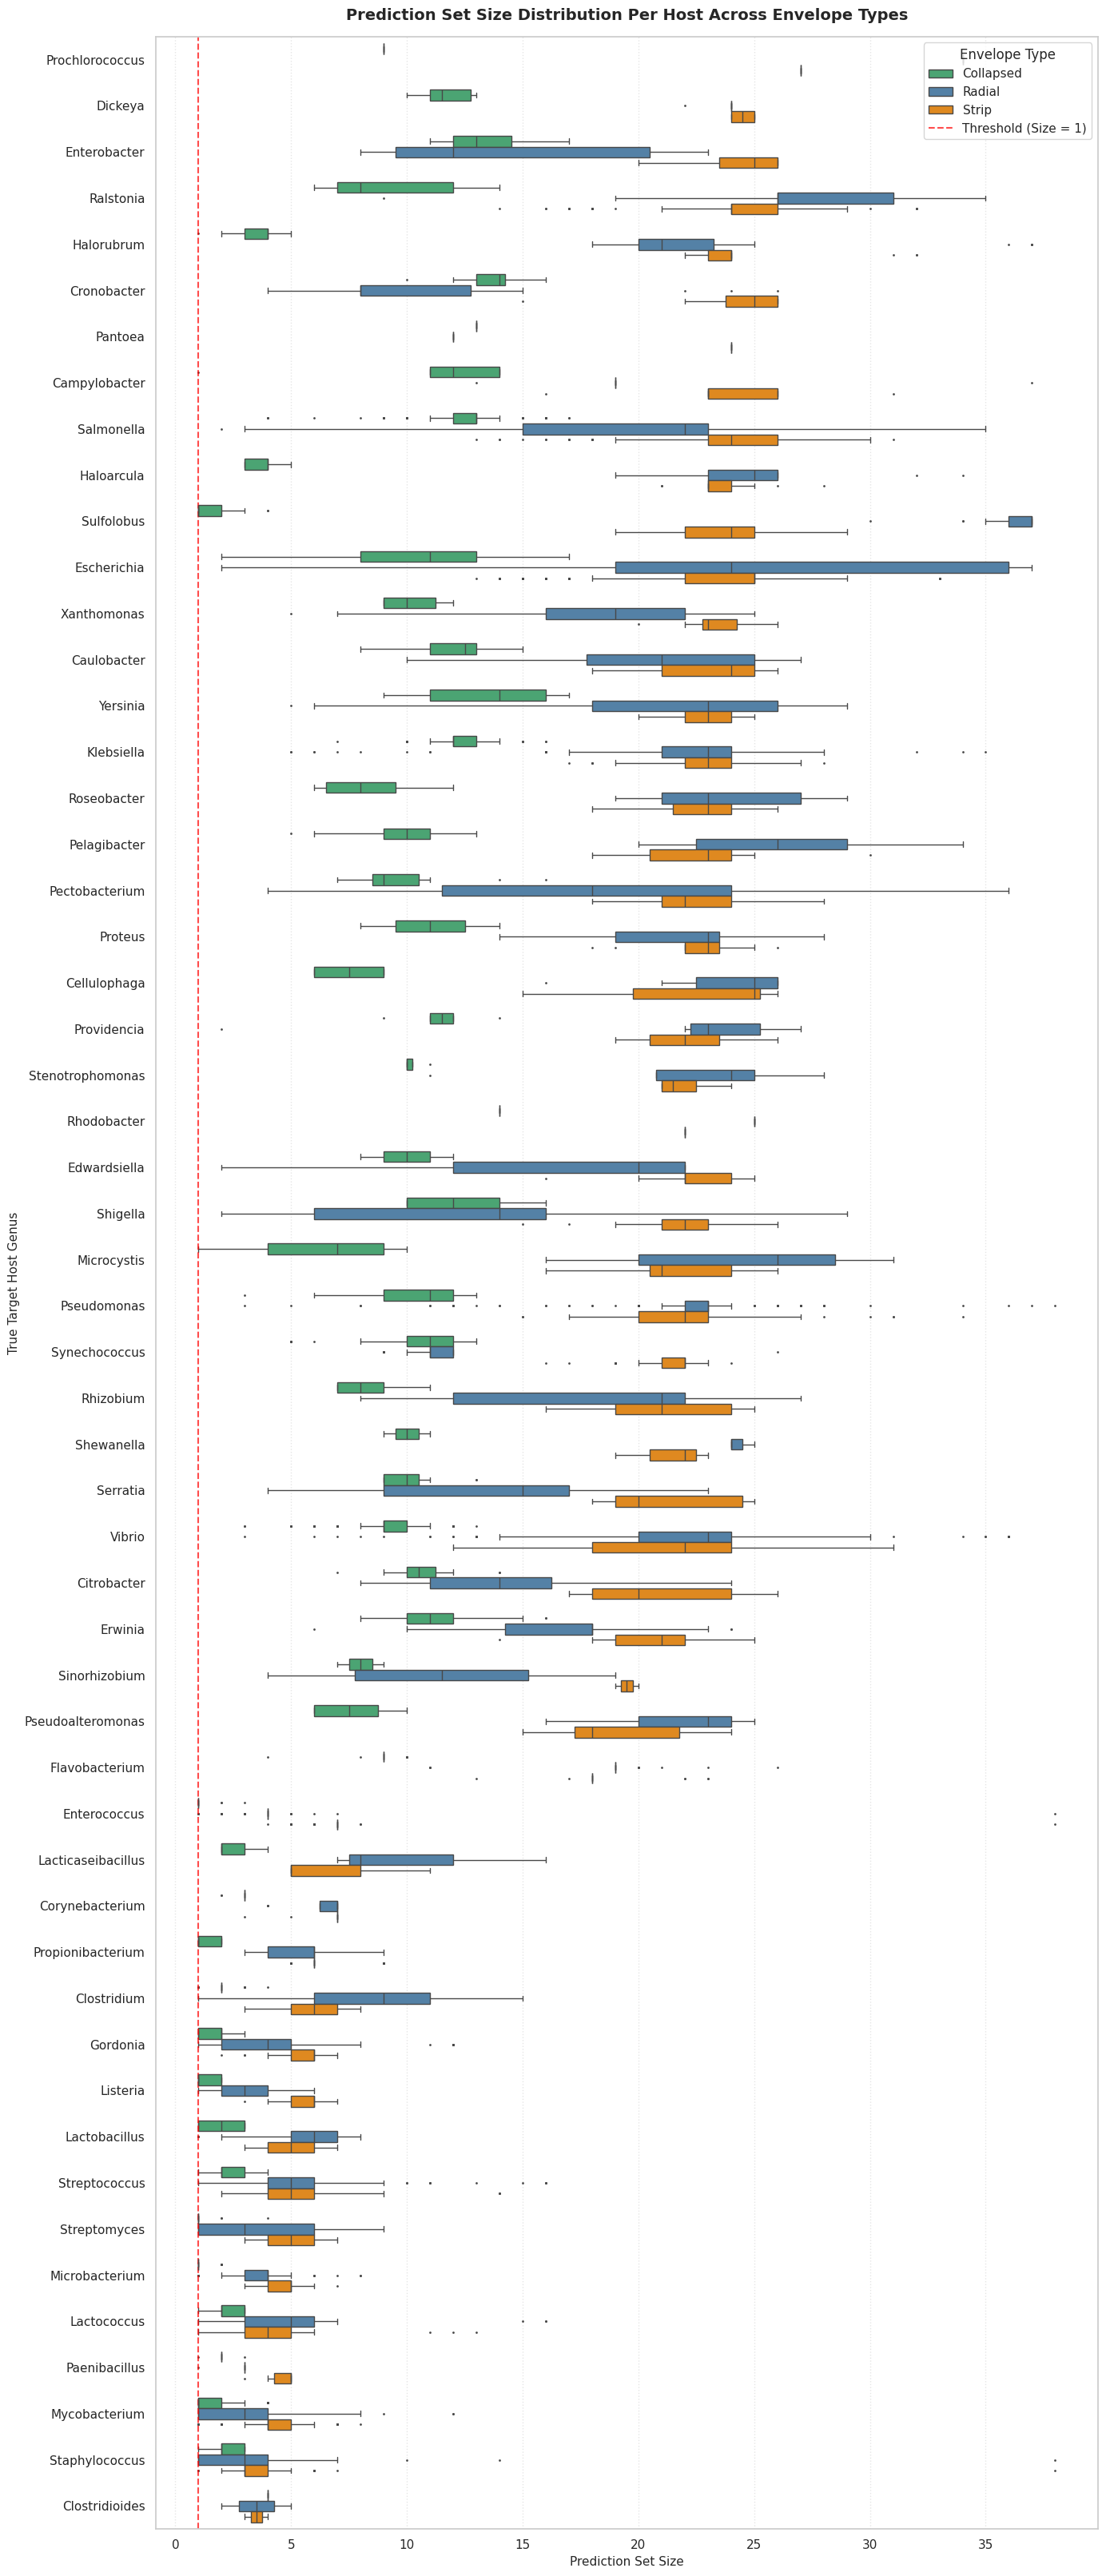

In [61]:
import seaborn as sns
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

methods = ["collapsed", "radial", "strip"]
method_display = {"collapsed": "Collapsed", "radial": "Radial", "strip": "Strip"}
colors = {"collapsed": "mediumseagreen", "radial": "steelblue", "strip": "darkorange"}

# order hosts by training set size, richest first, so the plot doubles as a
# richness-vs-set-size view left to right
hosts_sorted = sorted(all_hosts, key=lambda h: train_df["host"].value_counts().get(h, 0), reverse=True)
positions_base = np.arange(len(hosts_sorted))
box_width = 0.25

# 1. Transform your data into a "long-format" DataFrame
# Seaborn works best when each row is a single observation.
data_list = []
for method in methods:
    for h in hosts_sorted:
        sizes = [len(r["prediction_set"]) 
                 for r, true_h in zip(results_by_method[method], test_labels) if true_h == h]
        for s in (sizes if sizes else [np.nan]):
            data_list.append({"True Host": h, "Set Size": s, "Envelope Type": method_display[method]})

df_all_sets = pd.DataFrame(data_list)

# 2. Sort hosts based on the mean size of one of the types (e.g., 'Strip')
# This keeps the plot organized as in your example.
order_ref = df_all_sets[df_all_sets["Envelope Type"] == "Strip"].groupby("True Host")["Set Size"].mean().sort_values(ascending=False).index

# 3. Create the Plot
plt.figure(figsize=(14, max(8, len(hosts_sorted) * 0.6)))

sns.boxplot(
    data=df_all_sets,
    x="Set Size",
    y="True Host",
    hue="Envelope Type",
    order=order_ref,
    palette=[colors[m] for m in methods], # Maps your custom colors
    fliersize=1,
    width=0.7
)

# 4. Final Polish
plt.axvline(x=1, color="red", linestyle="--", alpha=0.7, label="Threshold (Size = 1)")
plt.title("Prediction Set Size Distribution Per Host Across Envelope Types", fontsize=14, fontweight="bold", pad=15 )
plt.xlabel("Prediction Set Size", fontsize=11)
plt.ylabel("True Target Host Genus", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.legend(title="Envelope Type", loc="upper right")

plt.tight_layout()
plt.show()

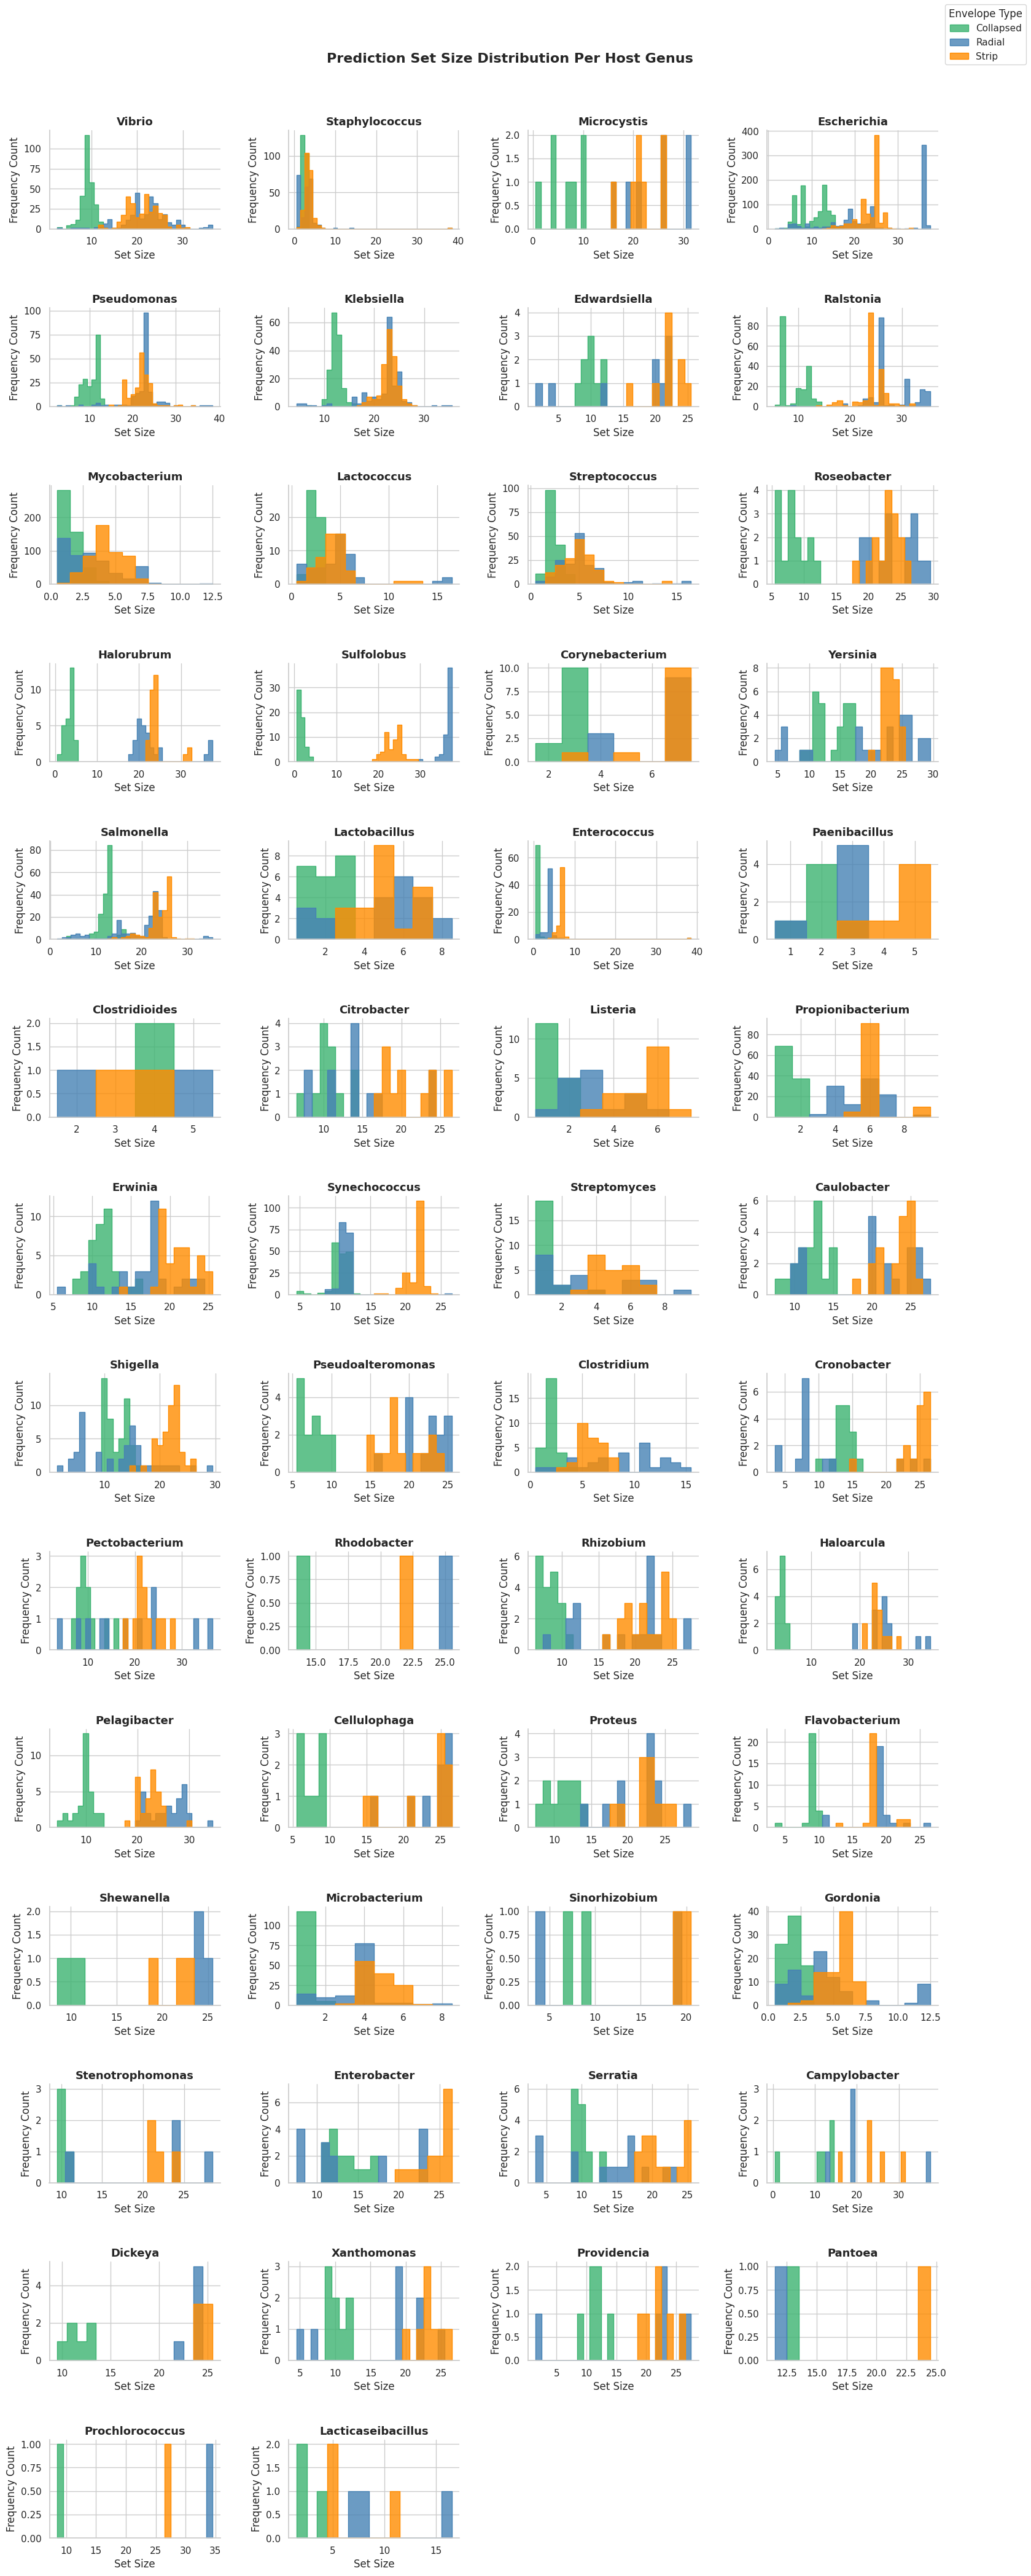

In [28]:
# 1. Gather the set sizes for ALL methods
all_data = []
for method in methods:
    for i, res in enumerate(results_by_method[method]):
        all_data.append({
            "True Host": test_labels[i],
            "Prediction Set Size": len(res["prediction_set"]),
            "Method": method_display[method]
        })

df_all = pd.DataFrame(all_data)

# 2. Define the palette mapping
palette_mapping = {
    "Collapsed": "mediumseagreen", 
    "Radial": "steelblue", 
    "Strip": "darkorange"
}

# 3. Create the FacetGrid with the palette argument
g = sns.FacetGrid(
    df_all, 
    col="True Host", 
    hue="Method", 
    col_wrap=4, 
    sharex=False, 
    sharey=False, 
    height=3, 
    aspect=1.3,
    palette=palette_mapping  # Custom colors applied here
)

g.map_dataframe(sns.histplot, x="Prediction Set Size", discrete=True, element="step", alpha=0.8)

for ax in g.axes.flat:
    ax.set_xlabel("Set Size")
    ax.tick_params(labelbottom=True)
    ax.set_ylabel("Frequency Count")

g.add_legend(title="Envelope Type", loc="upper right", frameon=True)
g.set_titles("{col_name}", fontweight="bold", size=13)
plt.subplots_adjust(top=0.95, hspace=0.8, wspace=0.4)
plt.suptitle("Prediction Set Size Distribution Per Host Genus", fontsize=16, fontweight="bold")
plt.show()

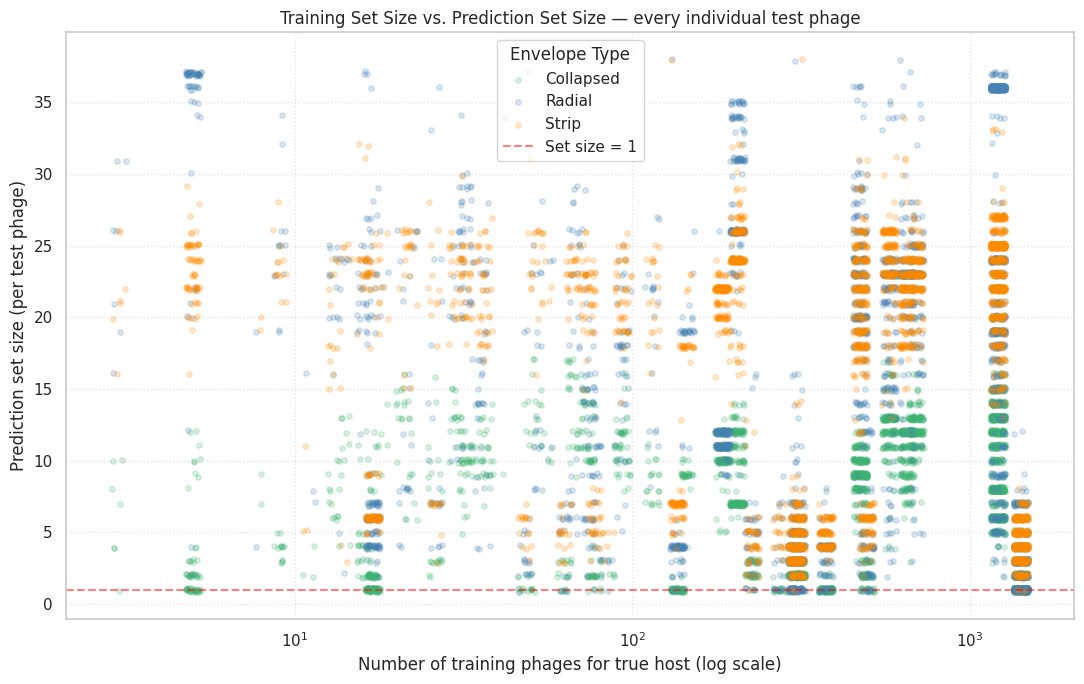

In [29]:
import matplotlib.pyplot as plt
import numpy as np

train_counts = train_df["host"].value_counts()
methods = ["collapsed", "radial", "strip"]
colors = {"collapsed": "mediumseagreen", "radial": "steelblue", "strip": "darkorange"}

fig, ax = plt.subplots(figsize=(11, 7))
rng = np.random.default_rng(0)

for method in methods:
    xs, ys = [], []
    for r, true_h in zip(results_by_method[method], test_labels):
        if true_h not in train_counts:
            continue
        xs.append(train_counts[true_h])
        ys.append(len(r["prediction_set"]))
    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)

    x_jitter = xs * np.exp(rng.uniform(-0.05, 0.05, size=len(xs)))  # multiplicative, since x is log-scaled
    y_jitter = ys + rng.uniform(-0.15, 0.15, size=len(ys))

    ax.scatter(x_jitter, y_jitter, label=method.capitalize(),
               color=colors[method], alpha=0.2, s=15)

ax.set_xscale("log")
ax.set_xlabel("Number of training phages for true host (log scale)")
ax.set_ylabel("Prediction set size (per test phage)")
ax.set_title("Training Set Size vs. Prediction Set Size — every individual test phage")
ax.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="Set size = 1")
ax.legend(title="Envelope Type")
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

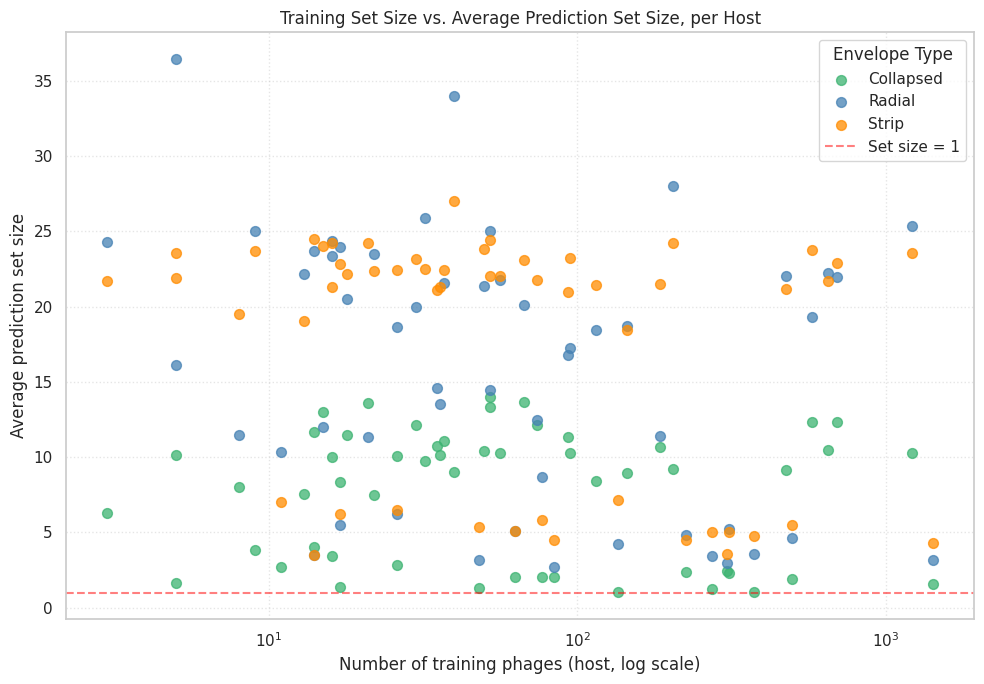

In [30]:
import matplotlib.pyplot as plt
import numpy as np

train_counts = train_df["host"].value_counts()
methods = ["collapsed", "radial", "strip"]
colors = {"collapsed": "mediumseagreen", "radial": "steelblue", "strip": "darkorange"}

fig, ax = plt.subplots(figsize=(10, 7))

for method in methods:
    xs, ys = [], []
    for h in all_hosts:
        sizes = [len(r["prediction_set"])
                 for r, true_h in zip(results_by_method[method], test_labels) if true_h == h]
        if not sizes or h not in train_counts:
            continue
        xs.append(train_counts[h])
        ys.append(np.mean(sizes))
    ax.scatter(xs, ys, label=method.capitalize(), color=colors[method], alpha=0.75, s=50)

ax.set_xscale("log")
ax.set_xlabel("Number of training phages (host, log scale)")
ax.set_ylabel("Average prediction set size")
ax.set_title("Training Set Size vs. Average Prediction Set Size, per Host")
ax.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="Set size = 1")
ax.legend(title="Envelope Type")
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

### Heat Maps

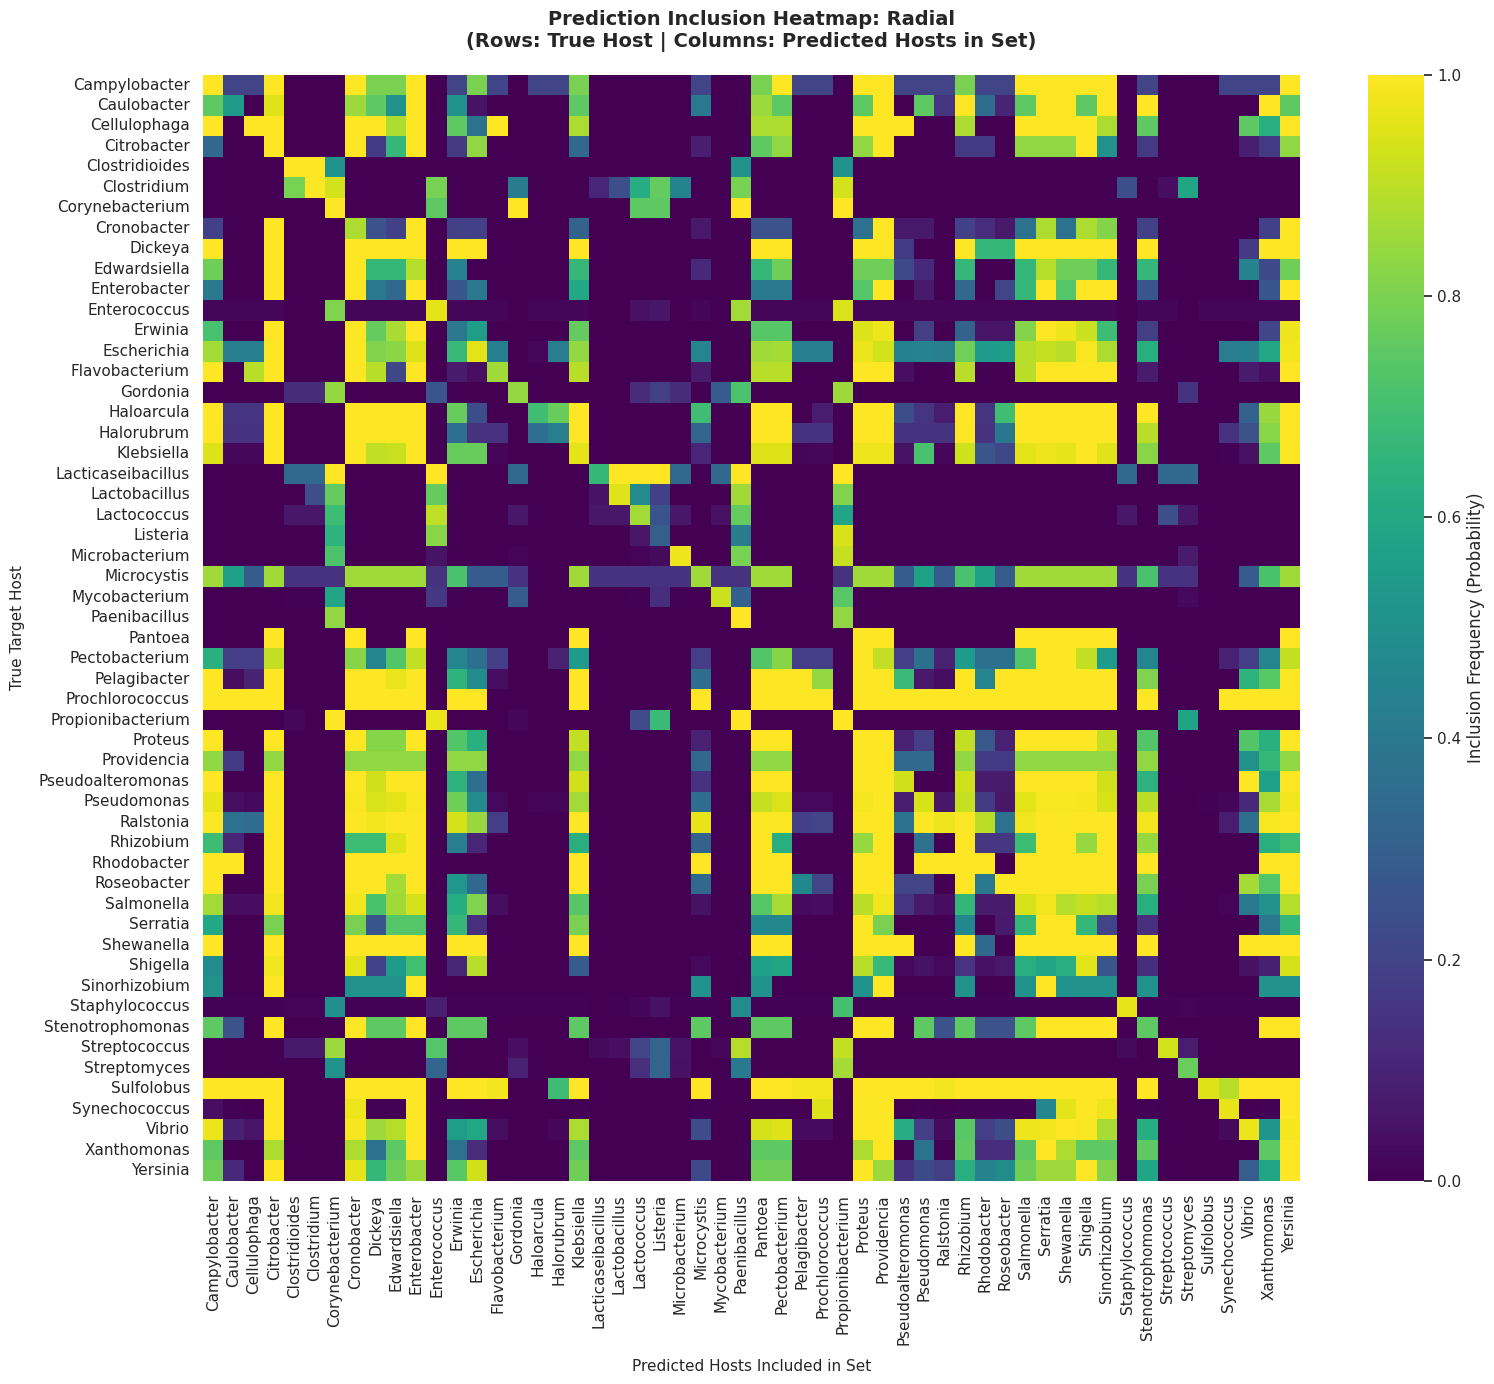

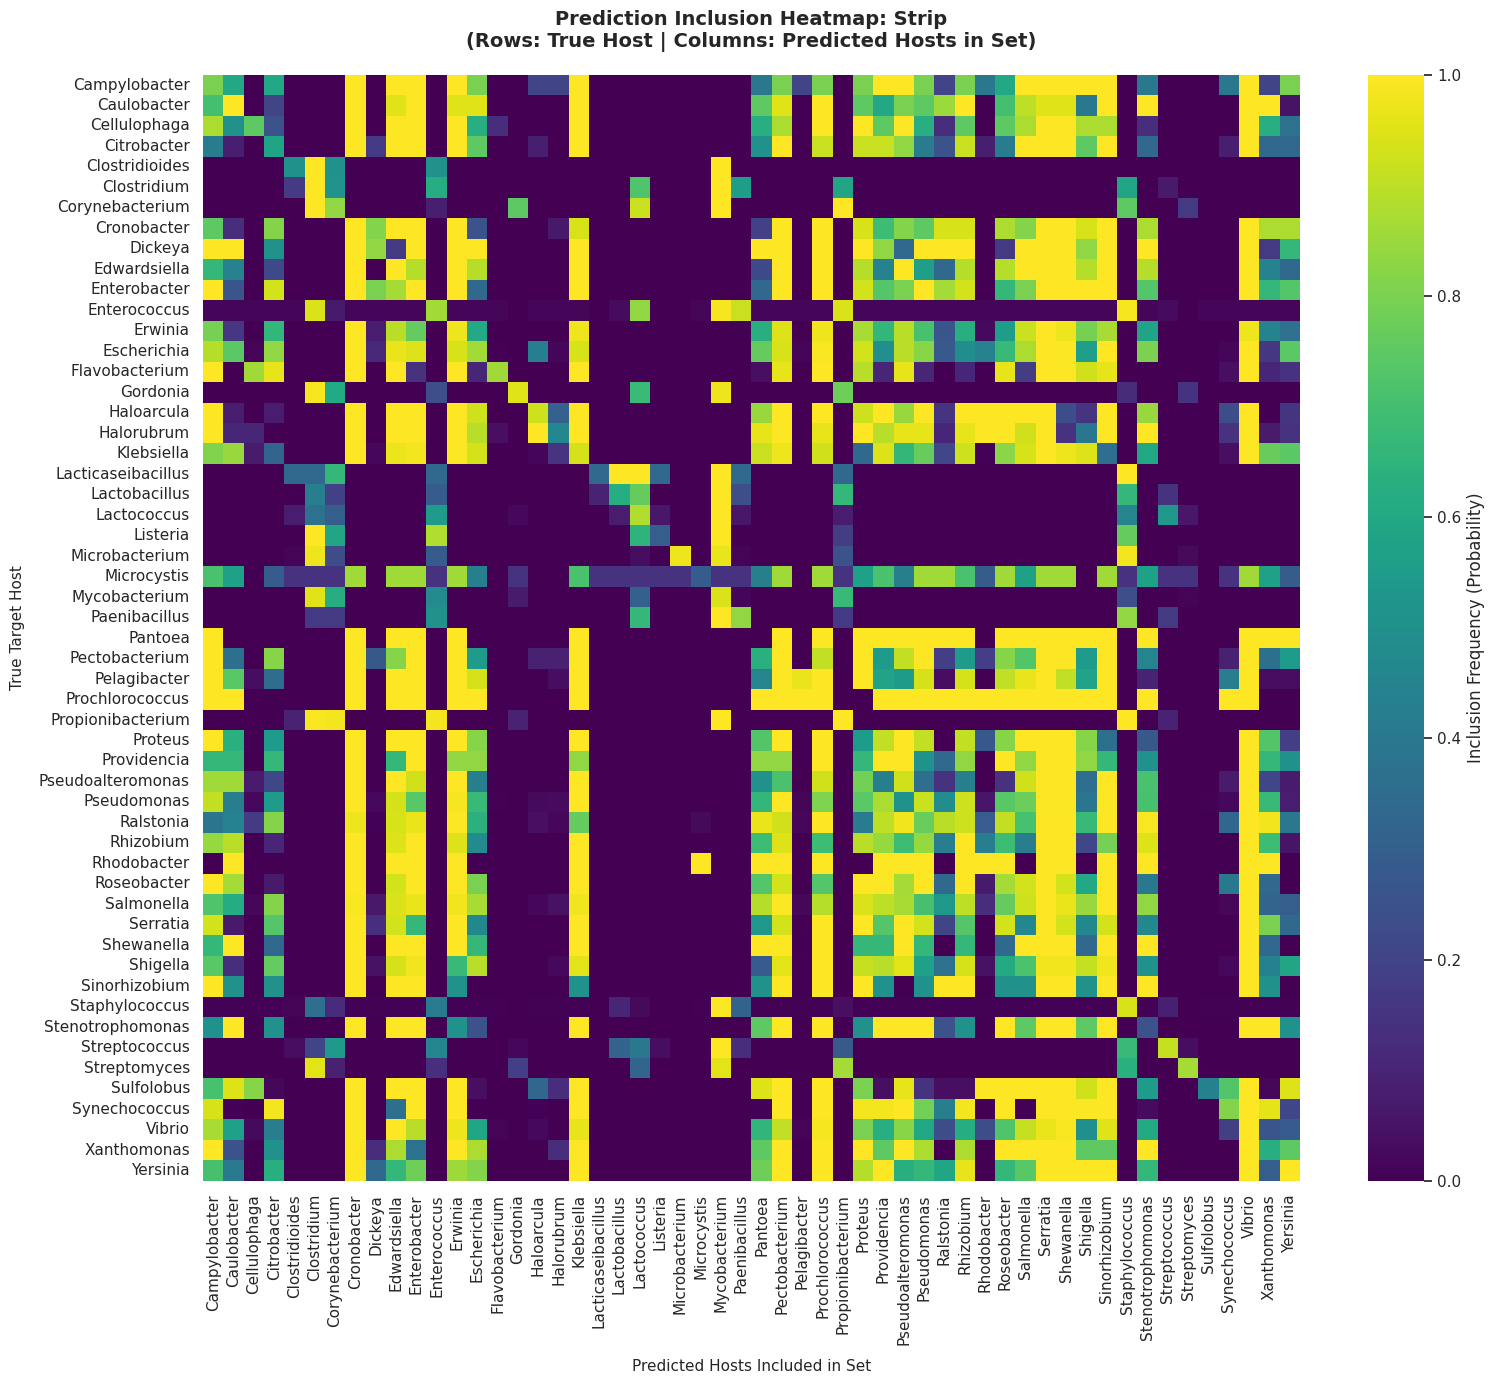

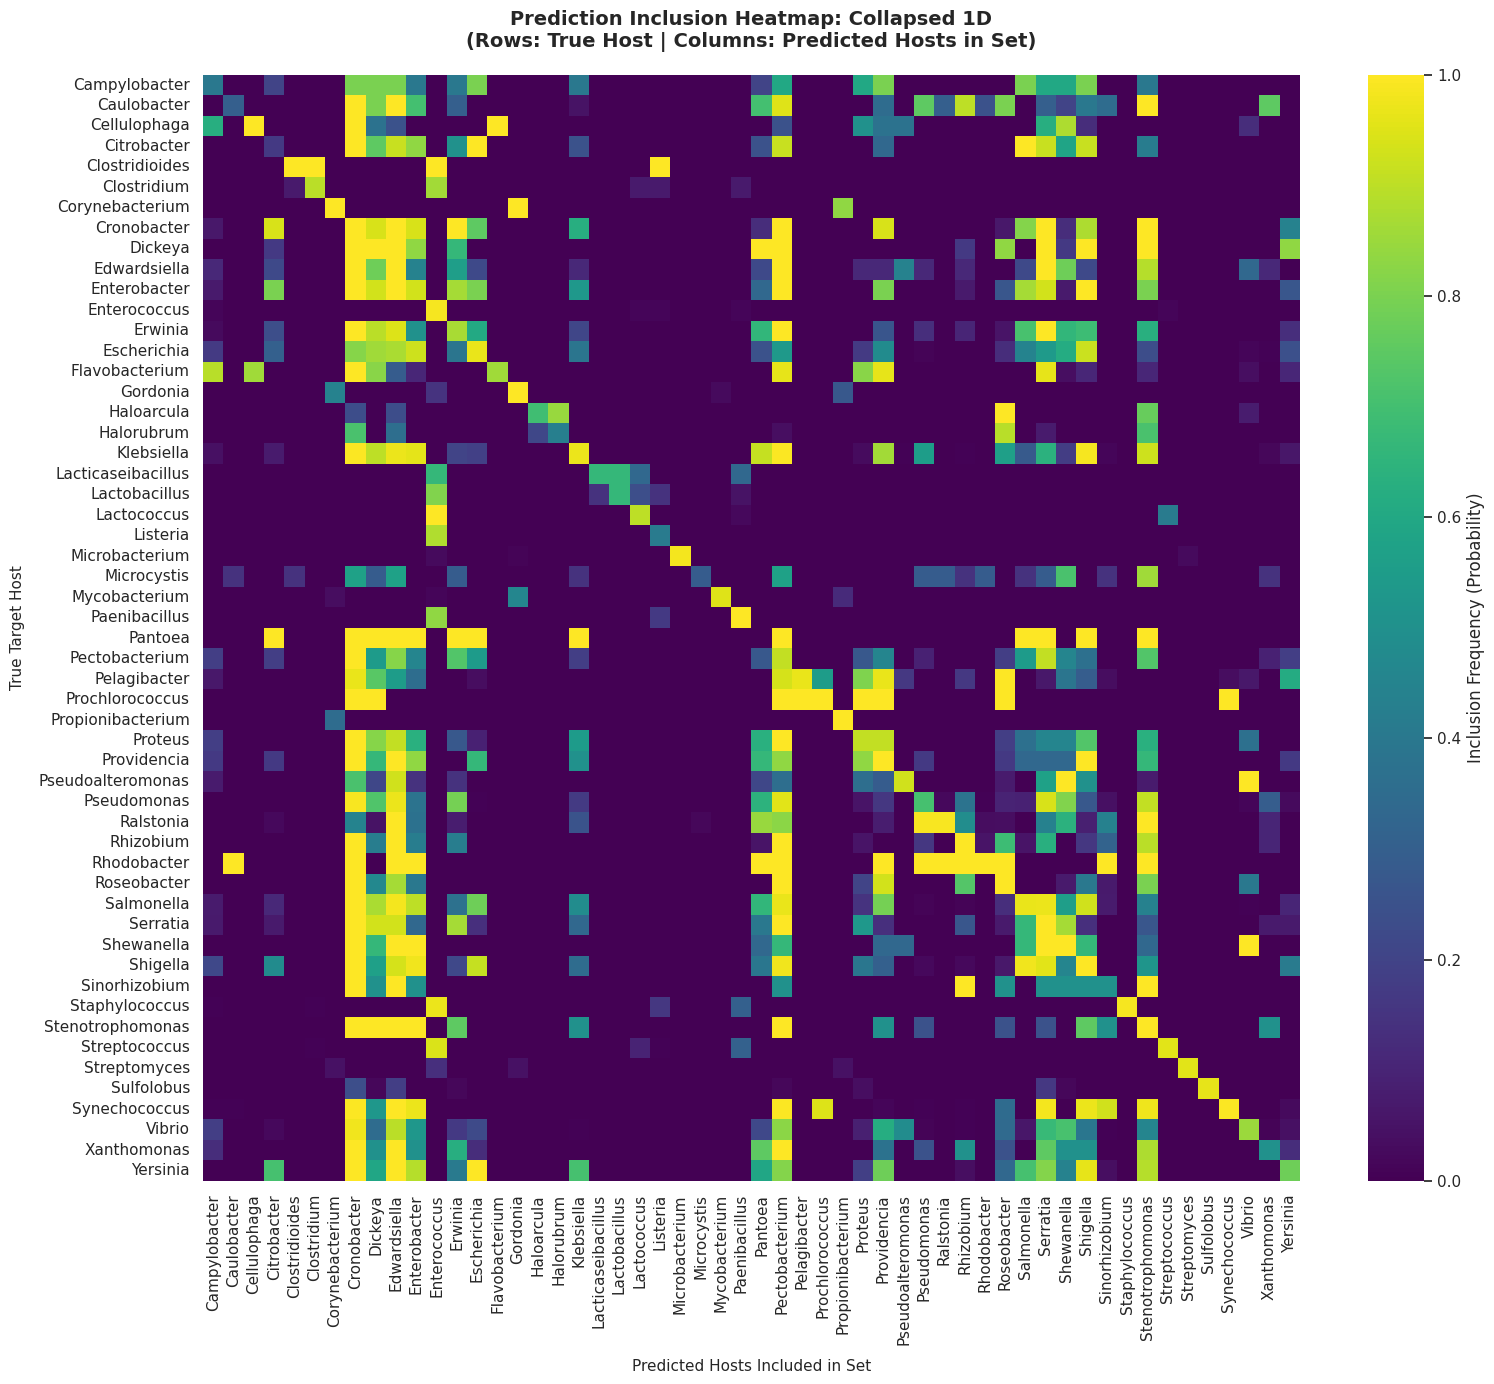

In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# AFTER — never rebind the globals; use local names for this cell only
unique_hosts = sorted(list(set(test_labels)))
valid_host_set = set(unique_hosts)   # was: host_col_map = set(all_hosts)
host_to_idx = {host: idx for idx, host in enumerate(unique_hosts)}

# Extracting from 'results_by_method' matching the keys from your execution loop
methods_dict = {
    "Radial": results_by_method["radial"],
    "Strip": results_by_method["strip"],
    "Collapsed 1D": results_by_method["collapsed"]
}

# Create the supporting df_set_sizes DataFrame used for the row normalization sums
df_set_sizes = pd.DataFrame({"True Host": test_labels})


# --- 2. GENERATE THE HEATMAPS ---
for method_name, results_list in methods_dict.items():
    # Initialize a matrix of zeros: shape (True Hosts, Predicted Hosts)
    matrix_counts = np.zeros((len(unique_hosts), len(unique_hosts)))   # was len(all_hosts)
    
    for idx, true_lbl in enumerate(test_labels):
        row_idx = host_to_idx[true_lbl]
        pred_set = results_list[idx]["prediction_set"]
        
        for pred_host in pred_set:
            if pred_host in valid_host_set:                                     # was host_col_map
                col_idx = host_to_idx[pred_host]                                # was all_hosts.index(pred_host) — also O(n), this is a free speed fix
                matrix_counts[row_idx, col_idx] += 1
                
    # Calculate total true samples per host to normalize into inclusion probabilities
    row_sums = df_set_sizes.groupby("True Host").size().reindex(unique_hosts).values[:, None]
    
    # Divide counts by sums safely (avoiding division by zero)
    df_heatmap = pd.DataFrame(matrix_counts / np.where(row_sums == 0, 1, row_sums),
                           index=unique_hosts, columns=unique_hosts)   # was columns=all_hosts
    # Plotting configuration
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        df_heatmap, 
        cmap="viridis", 
        vmin=0.0, 
        vmax=1.0, 
        cbar_kws={'label': 'Inclusion Frequency (Probability)'}, 
        xticklabels=True, 
        yticklabels=True
    )
    plt.title(f"Prediction Inclusion Heatmap: {method_name}\n(Rows: True Host | Columns: Predicted Hosts in Set)", fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted Hosts Included in Set", fontsize=11, labelpad=10)
    plt.ylabel("True Target Host", fontsize=11, labelpad=10)
    plt.tight_layout()
    plt.show()

## Testing

#### filtering out hosts with low sample hosts

In [32]:
print("\n" + "="*75)
print(" FILTERING OUT LOW-DATA HOSTS")
print("="*75)

# Task 2: Kick out hosts with lower data baseline counts in the train split
min_train_phages_required = 100
train_host_counts = pd.Series(train_labels).value_counts()
robust_hosts = train_host_counts[train_host_counts >= min_train_phages_required].index.tolist()

print(f"Original unique hosts evaluated: {len(all_hosts)}")
print(f"Hosts selected (with >= {min_train_phages_required} training samples): {len(robust_hosts)}")
print(f"Remaining hosts to evaluate: {sorted(robust_hosts)}")

# Task 3: Modulate the number of bins to M=5 for the robust hosts group
modulated_M = 5
print(f"\nRe-building Strip envelopes for {len(robust_hosts)} hosts (have >= {min_train_phages_required} training phages)")


host_col_map = {h: [i for i, c in enumerate(score_cols) if c.split("_")[0] == h] for h in all_hosts}

robust_per_host_envs_s = {}
for h in robust_hosts:
    h_idx = host_col_map[h]
    mask_h = train_labels == h
    n_h = mask_h.sum()
    train_nc_h = train_nc[mask_h][:, h_idx]
    
    # Mirroring split validation structure from build_per_host_envelopes
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    half = n_h // 2
    S1 = train_nc_h[idx[:half]]
    S2 = train_nc_h[idx[half:]]
    labels_S2 = np.array([h] * len(S2))
    
    # Custom calibration with dynamic custom parameters
    env = strip_build_envelope(S1, S2, labels_S2, [h], alpha, number_of_bins=modulated_M)
    robust_per_host_envs_s[h] = {"envelope": env, "col_indices": h_idx}

# Evaluate the filtered set on the test set sequence loop
robust_strip_results = []
robust_test_labels = []

for i, acc in enumerate(test_df.index):
    true_host = test_labels[i]
    if true_host not in robust_hosts:
        continue # Skip test sequences that don't belong to our filtered robust hosts
        
    allowed = candidate_hosts_for(acc)
    # Restrict tracking targets to allowed lists that exist inside the robust envelopes structure
    active = {h: robust_per_host_envs_s[h] for h in allowed if h in robust_per_host_envs_s}
    if not active:
        active = robust_per_host_envs_s
        
    robust_strip_results.append(predict_host(test_raw[i:i+1], active, list(active.keys()))[0])
    robust_test_labels.append(true_host)

# Calculate metrics configuration updates
robust_strip_metrics = evaluate_multiclass(robust_strip_results, np.array(robust_test_labels), robust_hosts, alpha)

print("\n--- NEW STRIP PERFORMANCE ---")
print(f"Robust Strip Coverage (M={modulated_M}): {robust_strip_metrics['coverage']:.3f}")
print(f"Robust Strip Average Set Size: {robust_strip_metrics['avg_set_size']:.2f}")


 FILTERING OUT LOW-DATA HOSTS
Original unique hosts evaluated: 54
Hosts selected (with >= 100 training samples): 17
Remaining hosts to evaluate: ['Enterococcus', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Klebsiella', 'Lactococcus', 'Microbacterium', 'Mycobacterium', 'Pseudomonas', 'Ralstonia', 'Rhizobium', 'Salmonella', 'Staphylococcus', 'Streptococcus', 'Streptomyces', 'Synechococcus', 'Vibrio']

Re-building Strip envelopes for 17 hosts (have >= 100 training phages)

--- NEW STRIP PERFORMANCE ---
Robust Strip Coverage (M=5): 0.969
Robust Strip Average Set Size: 4.53


#### 2D envelopes

In [33]:
def get_2d_scores(df, host, func_x, func_y):
    return df[[f"{host}_{func_x}", f"{host}_{func_y}"]]

def build_2d_envelope(train_df, host, func_x, func_y, alpha, method, seed=42, M=5):
    raw = get_2d_scores(train_df[train_df["host"] == host], host, func_x, func_y).values
    nc = raw_to_nc(raw)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(nc))
    S1, S2 = nc[idx[:len(nc)//2]], nc[idx[len(nc)//2:]]
    labels_S2 = np.array([host] * len(S2))
    if method == "collapsed":
        return collapsed_build_envelope(S1, S2, labels_S2, [host], alpha)
    elif method == "radial":
        return radial_build_envelope(S1, S2, labels_S2, [host], alpha, M=M, rng=rng)
    else:
        return strip_build_envelope(S1, S2, labels_S2, [host], alpha, number_of_bins=NB)

In [34]:
def plot_diagnostic_host_envelope_2d(host_name, func_x, func_y):
    cx, cy = f"{host_name}_{func_x}", f"{host_name}_{func_y}"
    if cx not in score_cols or cy not in score_cols:
        print(f"{host_name}: missing {func_x}/{func_y} columns")
        return
    own_raw = get_2d_scores(test_df[test_df["host"] == host_name], host_name, func_x, func_y).values
    other_raw = get_2d_scores(test_df[test_df["host"] != host_name], host_name, func_x, func_y).values
    own_nc, other_nc = raw_to_nc(own_raw), raw_to_nc(other_raw)

    # -----------------------------------------------------------------
    # NEW: Isolate phages where lysin exists but annealing is missing
    # -----------------------------------------------------------------
    if func_x == "lysin" and func_y == "annealing":
        own_only_lysin = own_nc[~np.isnan(own_nc[:, 0]) & np.isnan(own_nc[:, 1]), 0]
        other_only_lysin = other_nc[~np.isnan(other_nc[:, 0]) & np.isnan(other_nc[:, 1]), 0]
    else:
        own_only_lysin, other_only_lysin = np.array([]), np.array([])
    # -----------------------------------------------------------------

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, method in zip(axes, ["collapsed", "radial", "strip"]):
        env = build_2d_envelope(train_df, host_name, func_x, func_y, alpha, method)
        own_in = is_in_region(own_nc, env) if len(own_nc) else np.array([])
        other_in = is_in_region(other_nc, env) if len(other_nc) else np.array([])

        # --- true negatives: plot first, underneath everything else ---
        if len(other_nc):
            other_out = ~other_in
            ax.scatter(other_nc[other_out, 0], other_nc[other_out, 1],
                       c="steelblue", s=15, alpha=0.5, marker="x", label="other host outside (TN)", zorder=1)

        if len(own_nc):
            ax.scatter(own_nc[own_in, 0], own_nc[own_in, 1], c="steelblue", s=20, label="true host inside (TP)", zorder=3)
            ax.scatter(own_nc[~own_in, 0], own_nc[~own_in, 1], c="firebrick",  marker="x",  s=30, label="true host outside (FN)", zorder=3)
        if len(other_nc):
            ax.scatter(other_nc[other_in, 0], other_nc[other_in, 1], c="firebrick", s=20, label="other host inside (FP)", zorder=3)

        # -----------------------------------------------------------------
        # NEW: Plot the vertical dotted lines for phages missing annealing
        # -----------------------------------------------------------------
        if len(other_only_lysin):
            for i, x_val in enumerate(other_only_lysin):
                lbl = "other host (lysin only)" if i == 0 else ""
                ax.axvline(x=x_val, color="steelblue", linestyle=":", alpha=0.35, linewidth=1, label=lbl, zorder=1)

        if len(own_only_lysin):
            for i, x_val in enumerate(own_only_lysin):
                lbl = "true host (lysin only)" if i == 0 else ""
                ax.axvline(x=x_val, color="firebrick", linestyle=":", alpha=0.5, linewidth=1.2, label=lbl, zorder=2)
        # -----------------------------------------------------------------

        if method == "collapsed":
            t = env["q_tilde"] * env["t_hat"]
            ax.plot([0, 2*t], [2*t, 0], "k--", lw=1.5)
        elif method == "radial":
            def get_safe_max(data, default=1.0):
                if len(data) == 0: return default
                finite_data = data[np.isfinite(data)]
                return finite_data.max() if len(finite_data) > 0 else default

            x_max = max(get_safe_max(own_nc[:, 0]), get_safe_max(other_nc[:, 0]))
            y_max = max(get_safe_max(own_nc[:, 1]), get_safe_max(other_nc[:, 1]))

            gx, gy = np.meshgrid(np.linspace(0, x_max, 250), np.linspace(0, y_max, 250))
            grid_nc = np.column_stack([gx.ravel(), gy.ravel()])
            grid_in = radial_is_in_region(grid_nc, env).astype(float).reshape(gx.shape)

            ax.imshow(grid_in, origin='lower', extent=[0, x_max, 0, y_max],
                      cmap='Greys', alpha=0.2, vmin=0, vmax=1, aspect='auto')
            ax.contour(gx, gy, grid_in, levels=[0.5], colors="darkorange", linewidths=1.5)
        else:
            def get_safe_max(data, default=1.0):
                if len(data) == 0: return default
                finite_data = data[np.isfinite(data)]
                return finite_data.max() if len(finite_data) > 0 else default

            x_max = max(get_safe_max(own_nc[:, 0]), get_safe_max(other_nc[:, 0]))
            y_max = max(get_safe_max(own_nc[:, 1]), get_safe_max(other_nc[:, 1]))

            gx, gy = np.meshgrid(np.linspace(0, x_max, 250), np.linspace(0, y_max, 250))
            grid_nc = np.column_stack([gx.ravel(), gy.ravel()])

            mask_raw = strip_is_in_region(grid_nc, env)
            grid_in = np.nan_to_num(mask_raw.astype(float)).reshape(gx.shape)

            ax.imshow(grid_in, origin='lower', extent=[0, x_max, 0, y_max],
                      cmap='Greys', alpha=0.2, vmin=0, vmax=1, aspect='auto')
            ax.contour(gx, gy, grid_in, levels=[0.5], colors="teal", linewidths=1.5)

        tp = int(own_in.sum()) if len(own_nc) else 0
        fn = int((~own_in).sum()) if len(own_nc) else 0
        fp = int(other_in.sum()) if len(other_nc) else 0
        tn = int((~other_in).sum()) if len(other_nc) else 0
 # ... rest of your code remains exactly the same ...
        own_cov = own_in.mean() if len(own_nc) else float("nan")
        ax.set_title(f"{host_name} — {method}\nown_cov={own_cov:.2f} \nTP={tp} FN={fn} FP={fp} TN={tn}")
        ax.set_xlabel(f"{func_x}"); ax.set_ylabel(f"{func_y}")
        ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

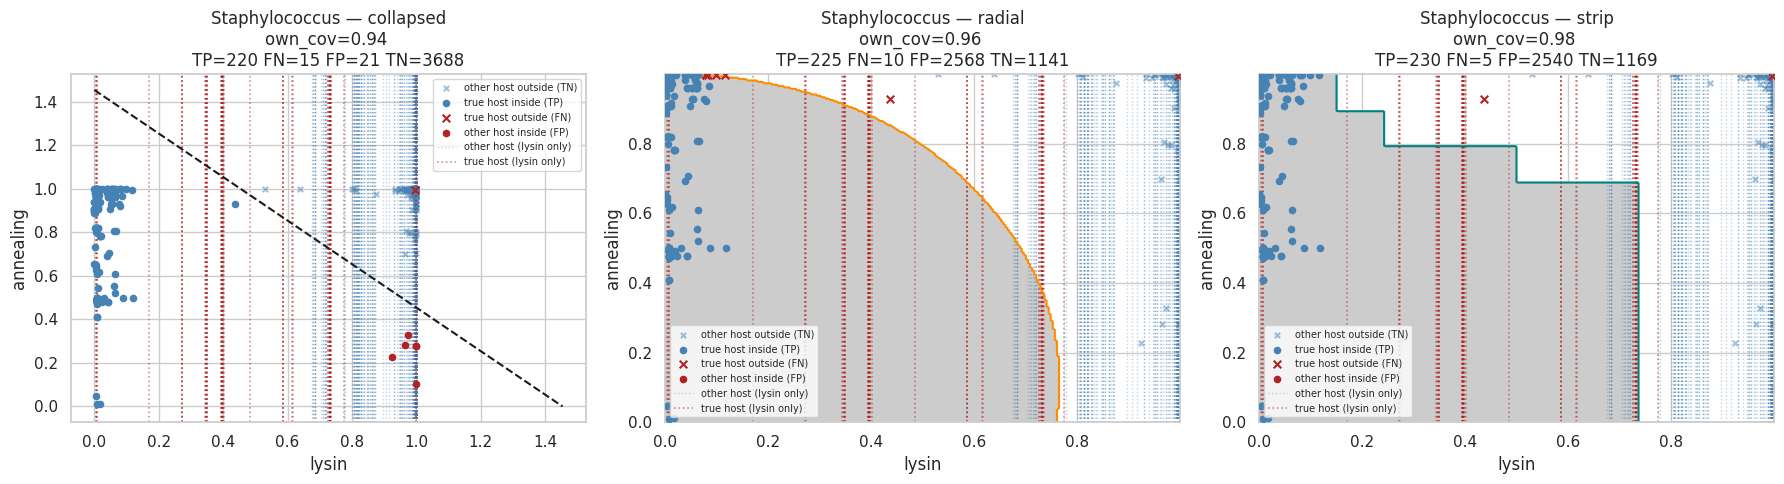

In [35]:
plot_diagnostic_host_envelope_2d("Staphylococcus", "lysin", "annealing")

### Checks

#### checking if the calibration even self covers 
   - isolate one host
   - build strip envelope
   - check coverage on S2
   - if coverage is not 0.9 then the bug is in "strip_shape_discovery" or "quantile_for_class"
   - else issue maybe in how the test data is fed

In [36]:
host = "Escherichia"  # pick a big one so sample noise isn't the excuse
h_idx = host_col_map[host]
mask_h = train_labels == host
train_nc_h = train_nc[mask_h][:, h_idx]

rng = np.random.default_rng(42)
n_h = train_nc_h.shape[0]
idx = rng.permutation(n_h)
half = n_h // 2
S1 = train_nc_h[idx[:half]]
S2 = train_nc_h[idx[half:]]
labels_S2 = np.array([host] * len(S2))

env = strip_build_envelope(S1, S2, labels_S2, [host], alpha)
tau2 = strip_tau_scores(S2, env["bin_edges"], env["limits"], env["marginal_quantiles"])
print("Self-coverage on S2 (must be ~0.9):", np.mean(tau2 <= env["t_hat"]))

# Now check against this host's actual test-fold points
mask_test_h = test_labels == host
test_nc_h = test_nc[mask_test_h][:, h_idx]
tau_test = strip_tau_scores(test_nc_h, env["bin_edges"], env["limits"], env["marginal_quantiles"])
print("Test-fold coverage (target ~0.9):", np.mean(tau_test <= env["t_hat"]))

Self-coverage on S2 (must be ~0.9): 1.0
Test-fold coverage (target ~0.9): 0.9964953271028038


#### Are the scors actually bounded in [0,1]?

In [37]:
print("train_nc min/max:", np.nanmin(train_nc), np.nanmax(train_nc))
print("test_nc min/max:", np.nanmin(test_nc), np.nanmax(test_nc))
print("Any negative NC?", np.nansum(train_nc < 0), np.nansum(test_nc < 0))
print("Any NC > 1?", np.nansum(train_nc > 1), np.nansum(test_nc > 1))

train_nc min/max: 2.9536373347127665e-12 0.9999998999999901
test_nc min/max: 2.662170484057924e-11 0.9999998999999901
Any negative NC? 0 0
Any NC > 1? 0 0


#### degenerate columns (zero variance in S1)

In [38]:
# Check if the host exists and how many samples it has
h_idx = host_col_map[host]
train_nc_h = train_nc[train_labels == host][:, h_idx]
n_h = train_nc_h.shape[0]

print(f"Debug: Found {n_h} samples for host '{host}'")

if n_h > 0:
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    S1 = train_nc_h[idx[:n_h//2]]
    print(f"Debug: S1 shape is {S1.shape}")
    
    if S1.shape[0] == 0:
        print("Warning: S1 is empty because n_h was less than 2.")
else:
    print(f"Error: No data found for host '{host}'. Check your labels and map.")

Debug: Found 1215 samples for host 'Escherichia'
Debug: S1 shape is (607, 40)


In [39]:
h_idx = host_col_map[host]
train_nc_h = train_nc[train_labels == host][:, h_idx]
rng = np.random.default_rng(42)
n_h = train_nc_h.shape[0]
idx = rng.permutation(n_h)
S1 = train_nc_h[idx[:n_h//2]]

for j in range(S1.shape[1]):
    col = S1[:, j]
    col_valid = col[~np.isnan(col)]
    if len(col_valid) == 0:
        print(f"col {j}: ALL NaN in S1")
    elif np.nanmin(col) == np.nanmax(col):
        print(f"col {j}: constant value {np.nanmin(col)} — degenerate bin_edges")

#### per-host breakdown to see if failure is uniform or concentrated

In [40]:
per_host_strip_cov = {}
for h in all_hosts:
    h_idx = host_col_map[h]
    if len(h_idx) == 0:
        continue
    mask_h = train_labels == h
    n_h = mask_h.sum()
    if n_h < 3:
        continue
    train_nc_h = train_nc[mask_h][:, h_idx]
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    half = n_h // 2
    S1 = train_nc_h[idx[:half]]
    S2 = train_nc_h[idx[half:]]
    labels_S2 = np.array([h] * len(S2))

    env = strip_build_envelope(S1, S2, labels_S2, [h], alpha)
    tau2 = strip_tau_scores(S2, env["bin_edges"], env["limits"], env["marginal_quantiles"])
    self_cov = np.mean(tau2 <= env["t_hat"])

    mask_test_h = test_labels == h
    if mask_test_h.sum() == 0:
        continue
    test_nc_h = test_nc[mask_test_h][:, h_idx]
    tau_test = strip_tau_scores(test_nc_h, env["bin_edges"], env["limits"], env["marginal_quantiles"])
    test_cov = np.mean(tau_test <= env["t_hat"])

    per_host_strip_cov[h] = (n_h, self_cov, test_cov)

import pandas as pd
df_diag = pd.DataFrame(per_host_strip_cov, index=["n_h", "self_cov", "test_cov"]).T
df_diag = df_diag.sort_values("test_cov")
print(df_diag.to_string())

                       n_h  self_cov  test_cov
Pantoea               15.0  1.000000  0.000000
Halorubrum            16.0  1.000000  0.071429
Paenibacillus         84.0  0.952381  0.166667
Edwardsiella           5.0  1.000000  0.222222
Sulfolobus             5.0  1.000000  0.290909
Caulobacter           30.0  1.000000  0.350000
Cellulophaga          22.0  1.000000  0.625000
Lactobacillus         63.0  0.937500  0.714286
Pectobacterium        26.0  1.000000  0.727273
Erwinia               93.0  0.978723  0.736842
Yersinia              67.0  0.941176  0.814815
Proteus               37.0  0.947368  0.818182
Providencia           18.0  1.000000  0.833333
Streptomyces         274.0  0.912409  0.863636
Gordonia             495.0  0.907258  0.864198
Xanthomonas           95.0  0.937500  0.875000
Klebsiella           695.0  0.905172  0.892857
Ralstonia            205.0  0.922330  0.896175
Shigella              74.0  0.972973  0.913043
Citrobacter           35.0  1.000000  0.916667
Haloarcula   

#### Fallback count

In [41]:
fallback_counts = {}
for h in all_hosts:
    h_idx = host_col_map[h]
    if len(h_idx) == 0:
        continue
    mask_h = train_labels == h
    n_h = mask_h.sum()
    if n_h < 3:
        continue
    train_nc_h = train_nc[mask_h][:, h_idx]
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    S1 = train_nc_h[idx[:n_h // 2]]
    N1, K = S1.shape

    bin_edges = np.array([
        np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), NB + 1)
        for j in range(K)
    ])
    total_pairs = 0
    fallback_pairs = 0
    for j in range(K):
        for m in range(NB):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                total_pairs += 1
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() < 3:
                    fallback_pairs += 1
    fallback_counts[h] = (n_h, K, fallback_pairs / total_pairs)

import pandas as pd
df_fb = pd.DataFrame(fallback_counts, index=["n_h", "K", "fallback_rate"]).T
print(df_fb.sort_values("fallback_rate", ascending=False).to_string())
print("\nOverall mean fallback rate:", df_fb["fallback_rate"].mean())

                       n_h     K  fallback_rate
Haloarcula             9.0  30.0       1.000000
Edwardsiella           5.0  39.0       1.000000
Sulfolobus             5.0  26.0       1.000000
Microcystis            3.0  38.0       1.000000
Pseudoalteromonas     13.0  38.0       0.991750
Sinorhizobium          8.0  38.0       0.990896
Lacticaseibacillus    11.0  30.0       0.988046
Halorubrum            16.0  31.0       0.983871
Pantoea               15.0  40.0       0.972949
Roseobacter           17.0  37.0       0.943393
Shewanella            16.0  40.0       0.932564
Clostridioides        14.0  36.0       0.918254
Dickeya               14.0  37.0       0.908258
Providencia           18.0  40.0       0.900897
Propionibacterium     17.0  31.0       0.897634
Pelagibacter          32.0  37.0       0.852252
Cronobacter           21.0  40.0       0.848077
Cellulophaga          22.0  36.0       0.826032
Pectobacterium        26.0  40.0       0.814744
Prochlorococcus       40.0  37.0       0

### Using only selected features

In [42]:
def select_top_features(train_nc, train_labels, host, h_idx, k_select=5):
    """Pick the k_select columns (of this host's own scoring functions) that
    best separate this host's true phages from everyone else's, by comparing
    median NC for true-host phages vs. all other phages on each column.
    Smaller NC = better match, so a bigger (median_other - median_h) gap
    means that column is more discriminative for this host."""
    mask_h = train_labels == host
    scores = []
    for col in h_idx:
        vals_h = train_nc[mask_h, col]
        vals_other = train_nc[~mask_h, col]
        med_h = np.nanmedian(vals_h)
        med_other = np.nanmedian(vals_other)
        gap = (med_other - med_h) if not (np.isnan(med_h) or np.isnan(med_other)) else -np.inf
        scores.append(gap)
    order = np.argsort(scores)[::-1]
    return [h_idx[i] for i in order[:k_select]]


def build_strip_envelope_for_host(train_nc, train_labels, host, h_idx, alpha, number_of_bins = NB):
    mask_h = train_labels == host
    n_h = mask_h.sum()
    train_nc_h = train_nc[mask_h][:, h_idx]
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    half = n_h // 2
    S1 = train_nc_h[idx[:half]]
    S2 = train_nc_h[idx[half:]]
    labels_S2 = np.array([host] * len(S2))
    return strip_build_envelope(S1, S2, labels_S2, [host], alpha, number_of_bins=NB)


def evaluate_strip_set_sizes(hosts_list, feature_select=False, k_select=5):
    envelopes = {}
    col_idx_map = {}
    for h in hosts_list:
        h_idx = host_col_map[h]
        h_idx_use = select_top_features(train_nc, train_labels, h, h_idx, k_select) if feature_select else h_idx
        col_idx_map[h] = h_idx_use
        envelopes[h] = build_strip_envelope_for_host(train_nc, train_labels, h, h_idx_use, alpha)

    mask_test = np.isin(test_labels, hosts_list)
    test_nc_sub = test_nc[mask_test]
    test_labels_sub = test_labels[mask_test]
    n_test = test_nc_sub.shape[0]
    n_hosts = len(hosts_list)

    # (n_test, n_hosts) matrix of raw tau scores and thresholds, built one host at a time
    tau_matrix = np.zeros((n_test, n_hosts))
    t_hats = np.zeros(n_hosts)
    for col, h in enumerate(hosts_list):
        env = envelopes[h]
        x = test_nc_sub[:, col_idx_map[h]]
        tau_matrix[:, col] = strip_tau_scores(x, env["bin_edges"], env["limits"], env["marginal_quantiles"])
        t_hats[col] = env["t_hat"]

    in_region = tau_matrix <= t_hats[np.newaxis, :]
    set_sizes = in_region.sum(axis=1)

    # forced fallback for empty sets: pick the host with smallest tau
    empty_rows = set_sizes == 0
    forced_choice = np.argmin(tau_matrix[empty_rows], axis=1) if empty_rows.any() else np.array([])

    host_arr = np.array(hosts_list)
    covered = 0
    final_set_sizes = []
    forced_idx = 0
    for row in range(n_test):
        true_host = test_labels_sub[row]
        if set_sizes[row] == 0:
            pred_set = [host_arr[forced_choice[forced_idx]]]
            forced_idx += 1
            final_set_sizes.append(1)
        else:
            pred_set = list(host_arr[in_region[row]])
            final_set_sizes.append(set_sizes[row])
        if true_host in pred_set:
            covered += 1

    coverage = covered / n_test
    avg_set_size = np.mean(final_set_sizes)
    return coverage, avg_set_size


filtered_hosts = ['Enterococcus', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Klebsiella',
                   'Lactococcus', 'Microbacterium', 'Mycobacterium', 'Pseudomonas', 'Ralstonia',
                   'Salmonella', 'Staphylococcus', 'Streptococcus', 'Streptomyces', 'Synechococcus', 'Vibrio']

print("=== OLD: full K, no feature selection ===")
cov_old, size_old = evaluate_strip_set_sizes(filtered_hosts, feature_select=False)
print(f"coverage={cov_old:.3f}  avg_set_size={size_old:.3f}\n")

for k in [3, 5, 8]:
    print(f"=== NEW: top-{k} feature selection per host ===")
    cov_new, size_new = evaluate_strip_set_sizes(filtered_hosts, feature_select=True, k_select=k)
    print(f"coverage={cov_new:.3f}  avg_set_size={size_new:.3f}\n")

=== OLD: full K, no feature selection ===
coverage=0.969  avg_set_size=12.077

=== NEW: top-3 feature selection per host ===
coverage=0.865  avg_set_size=11.190

=== NEW: top-5 feature selection per host ===
coverage=0.860  avg_set_size=11.334

=== NEW: top-8 feature selection per host ===
coverage=0.876  avg_set_size=11.115



In [43]:
zero_data_fallback = 0
partial_fallback = 0
total_fallback = 0

for h in all_hosts:
    h_idx = host_col_map[h]
    if len(h_idx) == 0: continue
    mask_h = train_labels == h
    n_h = mask_h.sum()
    if n_h < 3: continue
    train_nc_h = train_nc[mask_h][:, h_idx]
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    S1 = train_nc_h[idx[:n_h // 2]]
    N1, K = S1.shape
    bin_edges = np.array([np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), NB + 1) for j in range(K)])

    for j in range(K):
        for m in range(NB):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() < 3:
                    total_fallback += 1
                    non_nan_i = S1[~np.isnan(S1[:, i]), i]
                    if len(non_nan_i) == 0:
                        zero_data_fallback += 1
                    else:
                        partial_fallback += 1

print(f"Total fallback pairs: {total_fallback}")
print(f"  -> partial (host has SOME data for column i): {partial_fallback} ({partial_fallback/total_fallback:.1%})")
print(f"  -> zero-data (1.0 sentinel fires):             {zero_data_fallback} ({zero_data_fallback/total_fallback:.1%})")

Total fallback pairs: 246389
  -> partial (host has SOME data for column i): 228499 (92.7%)
  -> zero-data (1.0 sentinel fires):             17890 (7.3%)


### Set-size box plot using ONLY lysin + tail_appendage

- not every host has both lysin and tail-appendage column --> we filter for hosts that have both (drop the rest)

In [44]:
# --- Restrict host_col_map to just lysin + tail_appendage ---
lysin_ta_host_col_map = {}
for h in all_hosts:
    cols = []
    for suffix in ["lysin", "tail_appendage"]:
        col_name = f"{h}_{suffix}"
        if col_name in score_cols:
            cols.append(score_cols.index(col_name))
    if len(cols) == 2:
        lysin_ta_host_col_map[h] = cols

lysin_ta_hosts = list(lysin_ta_host_col_map.keys())
missing_hosts = [h for h in all_hosts if h not in lysin_ta_host_col_map]
if missing_hosts:
    print(f"Skipping {len(missing_hosts)} host(s) without both lysin & tail_appendage columns: {missing_hosts}")
print(f"Building lysin+tail_appendage envelopes for {len(lysin_ta_hosts)} hosts")

# --- Build per-host envelopes for each method, using only these 2 columns ---
envs_2fn = {}
for method in ["collapsed", "radial", "strip"]:
    print(f"\nBuilding {method} envelopes (lysin + tail_appendage only)...")
    envs_2fn[method] = build_per_host_envelopes(
        train_nc, train_labels, lysin_ta_hosts, score_cols, lysin_ta_host_col_map, alpha,
        method=method, seed=42
    )

# --- Predict with gram-type filtering, restricted to hosts that have both functions ---
results_by_method_2fn = {}
metrics_by_method_2fn = {}
eval_labels_2fn = None

for method_name, envs in envs_2fn.items():
    results = []
    kept_labels = []
    for i, acc in enumerate(test_df.index):
        true_host = test_labels[i]
        if true_host not in lysin_ta_hosts:
            continue  # no lysin/tail_appendage envelope exists for this host's true label
        allowed = candidate_hosts_for(acc)
        active = {h: envs[h] for h in allowed if h in envs}
        if not active:
            active = envs
        results.append(predict_host(test_raw[i:i+1], active, list(active.keys()))[0])
        kept_labels.append(true_host)

    kept_labels = np.array(kept_labels)
    metrics = evaluate_multiclass(results, kept_labels, lysin_ta_hosts, alpha)
    results_by_method_2fn[method_name] = results
    metrics_by_method_2fn[method_name] = metrics
    eval_labels_2fn = kept_labels  # identical filter across methods

    print(f"{method_name:10s}  coverage={metrics['coverage']:.3f}  "
          f"avg_set_size={metrics['avg_set_size']:.2f}  "
          f"singleton_rate={metrics['singleton_rate']:.3f}  "
          f"forced_rate={metrics['forced_rate']:.3f}")

Skipping 3 host(s) without both lysin & tail_appendage columns: ['Haloarcula', 'Halorubrum', 'Sulfolobus']
Building lysin+tail_appendage envelopes for 51 hosts

Building collapsed envelopes (lysin + tail_appendage only)...
  Built 51 host envelopes

Building radial envelopes (lysin + tail_appendage only)...
  Built 51 host envelopes

Building strip envelopes (lysin + tail_appendage only)...
  Built 51 host envelopes
collapsed   coverage=0.857  avg_set_size=7.79  singleton_rate=0.206  forced_rate=0.016
radial      coverage=0.910  avg_set_size=10.75  singleton_rate=0.066  forced_rate=0.004
strip       coverage=0.928  avg_set_size=8.13  singleton_rate=0.087  forced_rate=0.002


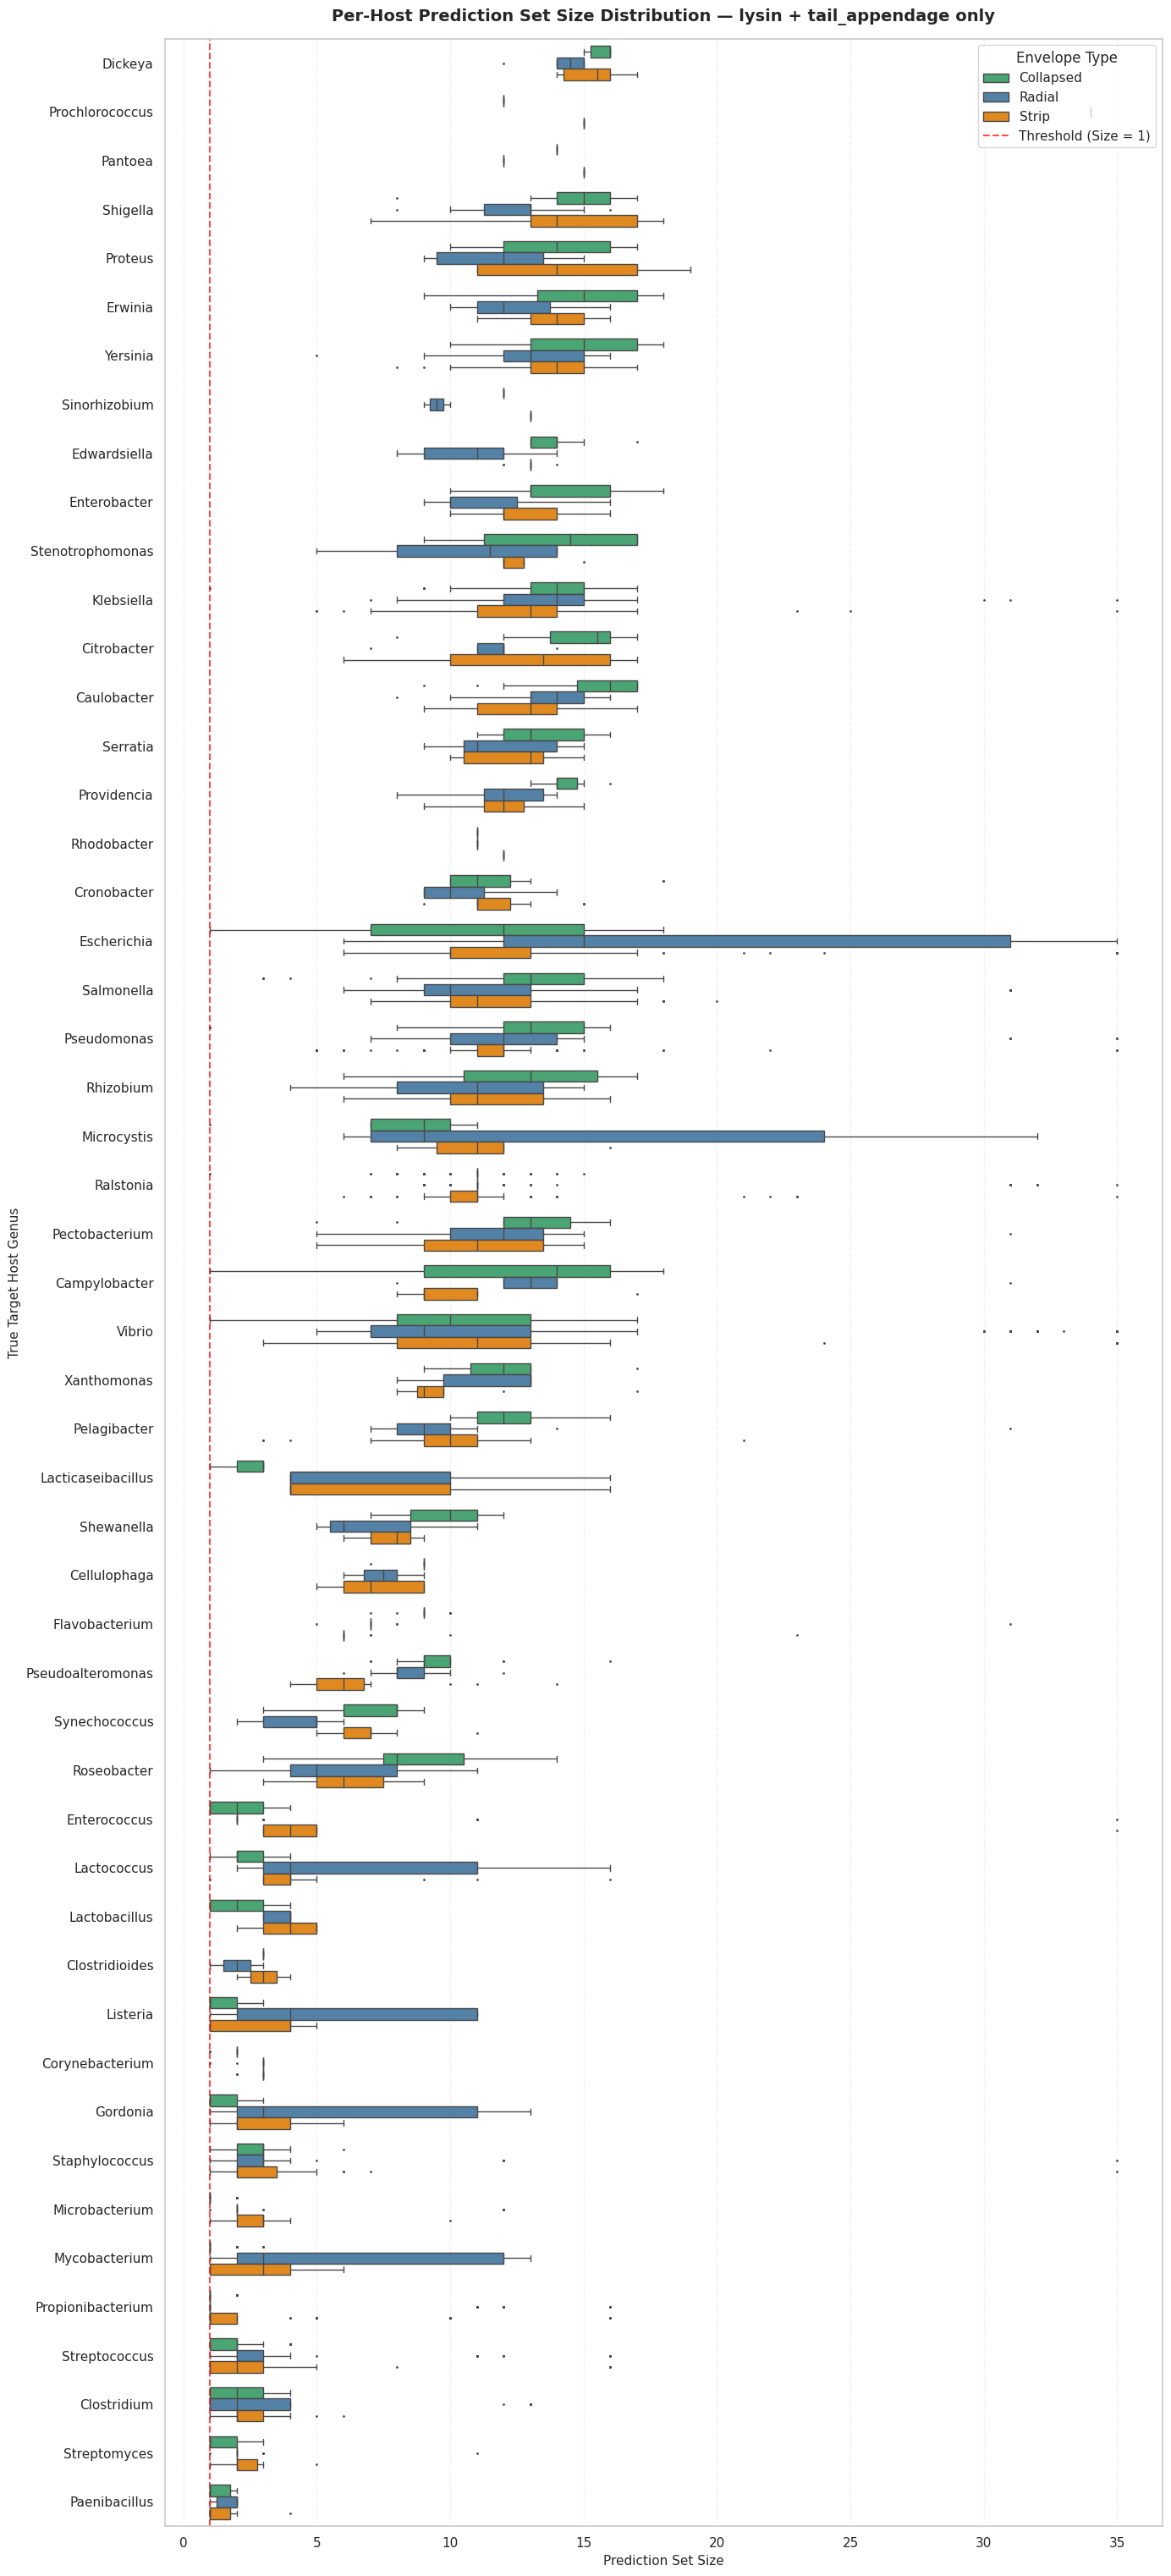

In [45]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

methods = ["collapsed", "radial", "strip"]
method_display = {"collapsed": "Collapsed", "radial": "Radial", "strip": "Strip"}
colors = {"collapsed": "mediumseagreen", "radial": "steelblue", "strip": "darkorange"}

hosts_sorted_2fn = sorted(lysin_ta_hosts, key=lambda h: train_df["host"].value_counts().get(h, 0), reverse=True)

data_list = []
for method in methods:
    for h in hosts_sorted_2fn:
        sizes = [len(r["prediction_set"])
                 for r, true_h in zip(results_by_method_2fn[method], eval_labels_2fn) if true_h == h]
        for s in (sizes if sizes else [np.nan]):
            data_list.append({"True Host": h, "Set Size": s, "Envelope Type": method_display[method]})

df_all_sets_2fn = pd.DataFrame(data_list)

order_ref_2fn = (df_all_sets_2fn[df_all_sets_2fn["Envelope Type"] == "Strip"]
                  .groupby("True Host")["Set Size"].mean().sort_values(ascending=False).index)

plt.figure(figsize=(14, max(8, len(hosts_sorted_2fn) * 0.6)))

sns.boxplot(
    data=df_all_sets_2fn,
    x="Set Size",
    y="True Host",
    hue="Envelope Type",
    order=order_ref_2fn,
    palette=[colors[m] for m in methods],
    fliersize=1,
    width=0.7
)

plt.axvline(x=1, color="red", linestyle="--", alpha=0.7, label="Threshold (Size = 1)")
plt.title("Per-Host Prediction Set Size Distribution \u2014 lysin + tail_appendage only",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Prediction Set Size", fontsize=11)
plt.ylabel("True Target Host Genus", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.legend(title="Envelope Type", loc="upper right")

plt.tight_layout()
plt.show()

In [46]:
staph_cols = [c for c in phage_scores.columns if c.startswith("Staphylococcus")]
print("Staphylococcus predictors:", staph_cols)

Staphylococcus predictors: ['Staphylococcus_DNA-associated', 'Staphylococcus_DNA_polymerase', 'Staphylococcus_RNA-associated', 'Staphylococcus_adsorption-related', 'Staphylococcus_annealing', 'Staphylococcus_anti-restriction', 'Staphylococcus_baseplate', 'Staphylococcus_capsid', 'Staphylococcus_cell_wall_depolymerase', 'Staphylococcus_ejection', 'Staphylococcus_endolysin', 'Staphylococcus_head-tail_joining', 'Staphylococcus_helicase', 'Staphylococcus_holin', 'Staphylococcus_integration', 'Staphylococcus_lysin', 'Staphylococcus_lysis', 'Staphylococcus_lysis_inhibitor', 'Staphylococcus_nuclease', 'Staphylococcus_nucleotide_metabolism', 'Staphylococcus_packaging_assembly', 'Staphylococcus_phosphorylation', 'Staphylococcus_portal', 'Staphylococcus_primase', 'Staphylococcus_pvp', 'Staphylococcus_reductase', 'Staphylococcus_replication_initiation', 'Staphylococcus_spanin', 'Staphylococcus_super_infection', 'Staphylococcus_tail', 'Staphylococcus_tail_appendage', 'Staphylococcus_tail_sheath', 

In [47]:
import numpy as np

# Mask for rows where the true host is Staphylococcus
mask_staph = train_df["host"] == "Staphylococcus"

# Calculate the mean raw score for each Staphylococcus column
staph_means = train_df.loc[mask_staph, staph_cols].mean().sort_values()

print("Weakest predictors (lowest mean scores) for Staphylococcus:")
print(staph_means.head(40)) # Adjust head() to see more or fewer

Weakest predictors (lowest mean scores) for Staphylococcus:
Staphylococcus_spanin                       0.020545
Staphylococcus_annealing                    0.074469
Staphylococcus_capsid                       0.208505
Staphylococcus_tail_sheath                  0.223140
Staphylococcus_ejection                     0.293442
Staphylococcus_terminase                    0.298583
Staphylococcus_replication_initiation       0.299091
Staphylococcus_phosphorylation              0.313093
Staphylococcus_val                          0.313496
Staphylococcus_transcriptional_regulator    0.316210
Staphylococcus_transcriptional_repressor    0.333023
Staphylococcus_baseplate                    0.346524
Staphylococcus_helicase                     0.393097
Staphylococcus_packaging_assembly           0.401471
Staphylococcus_anti-restriction             0.408803
Staphylococcus_integration                  0.416341
Staphylococcus_head-tail_joining            0.471616
Staphylococcus_RNA-associated          

In [48]:
nan_mask = np.isnan(train_nc)  # or test_nc, whichever you care about
N, K = nan_mask.shape

# How many (i,j) pairs across all points actually hit the new miss_j branch?
hit_count, total_pairs = 0, 0
for j in range(K):
    for i in range(K):
        if i == j:
            continue
        hit_count += ((~nan_mask[:, i]) & nan_mask[:, j]).sum()
        total_pairs += N

print(f"miss_j branch fires on {hit_count} / {total_pairs} pairs ({hit_count/total_pairs:.4%})")

# Are NaNs all-or-nothing per phage, or scattered?
nan_counts_per_row = nan_mask.sum(axis=1)
print(pd.Series(nan_counts_per_row).value_counts().sort_index())

miss_j branch fires on 7724843249 / 37707809260 pairs (20.4861%)
619     1
639     1
650     1
652     1
653     2
       ..
1928    1
1942    1
1944    1
1972    1
1989    1
Name: count, Length: 724, dtype: int64


In [49]:
rows = []
for h in all_hosts:
    h_idx = host_col_map[h]
    if len(h_idx) < 2:
        continue
    mask_h = train_labels == h
    S_h = train_nc[mask_h][:, h_idx]   # this host's phages, this host's own K_h columns only
    nan_mask_h = np.isnan(S_h)
    N_h, K_h = S_h.shape

    hit_count, total_pairs = 0, 0
    for j in range(K_h):
        for i in range(K_h):
            if i == j:
                continue
            hit_count += ((~nan_mask_h[:, i]) & nan_mask_h[:, j]).sum()
            total_pairs += N_h

    frac = hit_count / total_pairs if total_pairs else float("nan")
    rows.append({"host": h, "N": N_h, "K": K_h, "miss_j_frac": frac})

diag_df = pd.DataFrame(rows).sort_values("miss_j_frac", ascending=False)
print(diag_df.to_string(index=False))

              host    N  K  miss_j_frac
        Sulfolobus    5 26     0.244923
    Microbacterium  375 40     0.242412
 Pseudoalteromonas   13 38     0.224751
         Ralstonia  205 39     0.223673
      Pelagibacter   32 37     0.223067
     Streptococcus  310 37     0.220125
      Streptomyces  274 40     0.218173
       Pseudomonas  651 40     0.217301
       Microcystis    3 38     0.216453
     Mycobacterium 1420 39     0.215863
       Lactococcus  226 36     0.214949
          Gordonia  495 38     0.212558
   Prochlorococcus   40 37     0.210886
 Propionibacterium   17 31     0.207843
  Stenotrophomonas   56 40     0.207257
        Halorubrum   16 31     0.206452
       Xanthomonas   95 40     0.203610
       Providencia   18 40     0.201460
        Klebsiella  695 40     0.199525
           Pantoea   15 40     0.198077
     Campylobacter   50 40     0.198064
       Clostridium   77 35     0.196311
      Enterococcus  136 38     0.196155
            Vibrio  474 40     0.196112


In [50]:
def strip_tau_scores_OLD(S, bin_edges, limits, marginal_quantiles):
    N, K = S.shape
    bin_idx = get_bin_indices(S, bin_edges)
    j_idx = np.arange(K)[None, :, None]
    i_idx = np.arange(K)[None, None, :]
    m_idx = bin_idx[:, :, None]
    lims = limits[j_idx, i_idx, m_idx]
    S_i = S[:, np.newaxis, :]
    S_j = S[:, :, np.newaxis]
    nan_i = np.isnan(S_i)
    nan_j = np.isnan(S_j)
    mq = marginal_quantiles[np.newaxis, np.newaxis, :]
    ratio = np.zeros((N, K, K))
    both_avail = (~nan_i) & (~nan_j)
    miss_i = nan_i & (~nan_j)
    ratio = np.where(both_avail, np.broadcast_to(S_i, (N, K, K)) / (lims + 1e-12), ratio)
    ratio = np.where(miss_i, np.broadcast_to(mq, (N, K, K)) / (lims + 1e-12), ratio)
    diag_mask = np.eye(K, dtype=bool)[np.newaxis, :, :]
    ratio = np.where(diag_mask, 0.0, ratio)
    return np.nanmax(ratio, axis=(1, 2))

rows = []
for h in all_hosts:
    h_idx = host_col_map[h]
    if len(h_idx) < 2:
        continue
    mask_h = train_labels == h
    S1 = train_nc[mask_h][:, h_idx]
    bin_edges, limits, marginal_quantiles = strip_shape_discovery(S1, alpha, NB)

    tau_old = strip_tau_scores_OLD(S1, bin_edges, limits, marginal_quantiles)
    tau_new = strip_tau_scores(S1, bin_edges, limits, marginal_quantiles)  # your fixed version, already in the notebook

    changed = np.abs(tau_old - tau_new) > 1e-9
    rows.append({
        "host": h, "N": len(S1),
        "frac_rows_tau_changed": changed.mean(),
        "mean_abs_delta": np.abs(tau_old - tau_new).mean(),
        "max_abs_delta": np.abs(tau_old - tau_new).max(),
    })

pd.DataFrame(rows).sort_values("frac_rows_tau_changed", ascending=False)

,host,N,frac_rows_tau_changed,mean_abs_delta,max_abs_delta
17,Halorubrum,16,0.062500,0.012726,0.203614
21,Lactococcus,226,0.039823,0.001279,0.039160
26,Paenibacillus,84,0.023810,0.005940,0.249469
50,Synechococcus,185,0.021622,0.073433,7.506781
45,Staphylococcus,305,0.013115,0.001098,0.087205
40,Salmonella,578,0.001730,0.000009,0.004946
5,Clostridium,77,0.000000,0.000000,0.000000
4,Clostridioides,14,0.000000,0.000000,0.000000
6,Corynebacterium,26,0.000000,0.000000,0.000000
7,Cronobacter,21,0.000000,0.000000,0.000000


### Rejecting false hosts

In [51]:
# =============================================================================
# EXTENSION: Specificity-Controlled (Impostor-Calibrated) Envelopes
# =============================================================================

def compute_t_hat_specificity(raw_tau_negative, alpha):
    """
    Sets t_hat at the lower alpha-quantile of the INCORRECT host score distribution.
    Ensures P(False Host Admitted) <= alpha.
    """
    if len(raw_tau_negative) == 0:
        return 0.0
    return np.quantile(raw_tau_negative, alpha)


def build_per_host_envelopes_specificity(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                                          method="collapsed", seed=None, **method_kwargs):
    """
    Builds host envelopes where t_hat is calibrated against every OTHER host's
    phages scored on host h's columns at the alpha-quantile.
    """
    rng = np.random.default_rng(seed)
    envelopes = {}

    for h in all_hosts:
        h_idx_full = host_col_map[h]
        if len(h_idx_full) == 0:
            continue

        mask_h = train_labels == h
        n_h = mask_h.sum()
        if n_h < 3:
            continue

        train_nc_h_full = train_nc[mask_h][:, h_idx_full]
        has_data = ~np.isnan(train_nc_h_full).all(axis=0)

        if method == "strip":
            h_idx = list(h_idx_full)
            train_nc_h = train_nc_h_full
        else:
            h_idx = list(np.array(h_idx_full)[has_data])
            train_nc_h = train_nc_h_full[:, has_data]

        # Use ALL of host h's data for shape discovery (no positive split needed)
        S1 = train_nc_h
        dummy_S2 = S1[:1]
        dummy_labels = np.array([h])

        if method == "collapsed":
            env = collapsed_build_envelope(S1, dummy_S2, dummy_labels, [h], alpha)
        elif method == "radial":
            env = radial_build_envelope(
                S1, dummy_S2, dummy_labels, [h], alpha,
                M=method_kwargs.get("M", M), rng=rng,
                kappa=method_kwargs.get("kappa", 16.0),
                neighbor_frac=method_kwargs.get("neighbor_frac", 0.2),
                angular_bandwidth_deg=method_kwargs.get("angular_bandwidth_deg", 30.0),
            )
        else:
            env = strip_build_envelope(
                S1, dummy_S2, dummy_labels, [h], alpha,
                number_of_bins=method_kwargs.get("NB", NB),
                monotonic_window=method_kwargs.get("monotonic_window", 2),
                min_samples=method_kwargs.get("min_samples", 3),
            )

        # --- Negative Calibration: Score every OTHER host's phages on host h's columns ---
        mask_other = train_labels != h
        neg_raw = train_nc[mask_other][:, h_idx]

        if method == "collapsed":
            env_unit = dict(env, t_hat=1.0)
            raw_tau_neg = collapsed_tau(neg_raw, env_unit)
        elif method == "radial":
            env_unit = dict(env, t_hat=1.0)
            raw_tau_neg = radial_tau(neg_raw, env_unit)
        else:
            raw_tau_neg = strip_tau_scores(neg_raw, env["bin_edges"], env["limits"], env["marginal_quantiles"])

        # Override t_hat with specificity bound on false hosts
        env["t_hat"] = compute_t_hat_specificity(raw_tau_neg, alpha)
        envelopes[h] = {"envelope": env, "col_indices": h_idx}

    print(f"Built {len(envelopes)} specificity-controlled host envelopes ({method})")
    return envelopes

In [52]:
def predict_host_specificity(test_raw, per_host_envelopes, active_hosts_list):
    """
    Predicts hosts without forcing singletons when prediction set is empty.
    Empty sets signal high uncertainty / abstention.
    """
    N = len(test_raw)
    n_h = len(active_hosts_list)

    inside_matrix = np.zeros((N, n_h), dtype=bool)

    for j, h in enumerate(active_hosts_list):
        h_idx = per_host_envelopes[h]["col_indices"]
        env_h = per_host_envelopes[h]["envelope"]

        raw_h = test_raw[:, h_idx]
        nc_h = np.where(np.isnan(raw_h), np.nan, 1.0 - raw_h)

        inside_matrix[:, j] = is_in_region(nc_h, env_h)

    results = []
    for i in range(N):
        pred_set = [active_hosts_list[j] for j in range(n_h) if inside_matrix[i, j]]
        results.append({
            "prediction_set": pred_set,
            "is_empty": len(pred_set) == 0,
            "is_singleton": len(pred_set) == 1,
            "is_multi": len(pred_set) > 1,
        })
    return results


def evaluate_specificity(results, true_labels):
    """
    Tracks Precision, Coverage, and Abstention (Empty Set) Rates.
    """
    n = len(results)
    n_empty = sum(1 for r in results if r["is_empty"])
    n_non_empty = n - n_empty
    
    correct_all = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    correct_non_empty = sum(
        1 for i, r in enumerate(results)
        if not r["is_empty"] and true_labels[i] in r["prediction_set"]
    )
    
    precision = (correct_non_empty / n_non_empty) if n_non_empty > 0 else 0.0
    avg_size = np.mean([len(r["prediction_set"]) for r in results])

    return {
        "overall_coverage": correct_all / n,
        "empty_rate": n_empty / n,
        "non_empty_rate": n_non_empty / n,
        "precision": precision,
        "avg_set_size": avg_size
    }

In [53]:
# =============================================================================
# EXPERIMENT: Specificity Control on Test Set (Split 0)
# =============================================================================
print("\n" + "="*60)
print(" RUNNING SPECIFICITY-CONTROLLED (IMPOSTOR BOUNDED) EXPERIMENT ")
print("="*60)

methods = ["collapsed", "radial", "strip"]
spec_results_by_method = {}
spec_metrics_by_method = {}

for method in methods:
    # 1. Build envelopes using impostor scores
    if method == "radial":
        envs_spec = build_per_host_envelopes_specificity(
            train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
            method="radial", seed=42, M=best_M, kappa=best_kappa
        )
    elif method == "strip":
        envs_spec = build_per_host_envelopes_specificity(
            train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
            method="strip", NB=best_NB
        )
    else:
        envs_spec = build_per_host_envelopes_specificity(
            train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
            method="collapsed", seed=42
        )

    # 2. Predict on test split with Gram-type candidate filtering
    results = []
    for i, acc in enumerate(test_df.index):
        allowed = candidate_hosts_for(acc)
        active = {h: envs_spec[h] for h in allowed if h in envs_spec}
        if not active:
            active = envs_spec

        res = predict_host_specificity(test_raw[i:i+1], active, list(active.keys()))[0]
        results.append(res)

    # 3. Evaluate
    metrics = evaluate_specificity(results, test_labels)
    spec_results_by_method[method] = results
    spec_metrics_by_method[method] = metrics

# Print Summary
summary_rows = []
for m_name in methods:
    m = spec_metrics_by_method[m_name]
    summary_rows.append({
        "Method": m_name.capitalize(),
        "Overall Coverage": f"{m['overall_coverage']:.2%}",
        "Abstention (Empty) %": f"{m['empty_rate']:.2%}",
        "Prediction Yield %": f"{m['non_empty_rate']:.2%}",
        "Precision (Non-Empty)": f"{m['precision']:.2%}",
        "Avg Set Size": f"{m['avg_set_size']:.2f}"
    })

print("\n=== SPECIFICITY-CONTROLLED TEST RESULTS ===")
print(pd.DataFrame(summary_rows).to_string(index=False))


 RUNNING SPECIFICITY-CONTROLLED (IMPOSTOR BOUNDED) EXPERIMENT 
Built 54 specificity-controlled host envelopes (collapsed)
Built 54 specificity-controlled host envelopes (radial)
Built 54 specificity-controlled host envelopes (strip)

=== SPECIFICITY-CONTROLLED TEST RESULTS ===
   Method Overall Coverage Abstention (Empty) % Prediction Yield % Precision (Non-Empty) Avg Set Size
Collapsed            0.00%              100.00%              0.00%                 0.00%         0.00
   Radial            0.00%               99.92%              0.08%                 0.00%         0.02
    Strip            0.00%               99.92%              0.08%                 0.00%         0.02


In [54]:
# =============================================================================
# ACTUAL OUTPUTS: which phages got a non-empty specificity-controlled prediction
# =============================================================================

for method in methods:
    results = spec_results_by_method[method]

    rows = []
    for i, acc in enumerate(test_df.index):
        r = results[i]
        if r["is_empty"]:
            continue  # abstained -- not interesting to show, that's the expected majority case
        true_h = test_labels[i]
        rows.append({
            "accession": acc,
            "true_host": true_h,
            "predicted_set": r["prediction_set"],
            "set_size": len(r["prediction_set"]),
            "correct": true_h in r["prediction_set"],
        })

    df_nonempty = pd.DataFrame(rows)

    print(f"\n{'='*60}")
    print(f" {method.upper()} — non-empty predictions: {len(df_nonempty)} / {len(test_df)} test phages")
    print(f"{'='*60}")
    if len(df_nonempty) > 0:
        print(df_nonempty.to_string(index=False))
    else:
        print("  (none — every test phage abstained under this method)")

    df_nonempty.to_csv(f"specificity_nonempty_{method}.csv", index=False)


 COLLAPSED — non-empty predictions: 0 / 3944 test phages
  (none — every test phage abstained under this method)

 RADIAL — non-empty predictions: 3 / 3944 test phages
accession      true_host                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         predicted_set  set_size  correct
 GU169904 Staphylococcus [Campylobacter, Caulobacter, Cellulophaga, Citrobacter, Cronobacter, Dickeya, Edwardsiella, Enterobacter, Erwinia, Escherichia, Flavobacterium, Haloarcula, Halorubrum, Klebsiella, Microcystis, Pantoea, Pectobacterium, Pelagibacter, Prochlorococcus, Proteus, Providencia, Pseud

In [55]:
# Per-host breakdown of where non-empty predictions actually landed
for method in methods:
    results = spec_results_by_method[method]
    rows = []
    for i, acc in enumerate(test_df.index):
        r = results[i]
        if r["is_empty"]:
            continue
        true_h = test_labels[i]
    


        
        for pred_h in r["prediction_set"]:
            rows.append({"predicted_host": pred_h, "true_host": true_h, "correct": true_h == pred_h})

    df = pd.DataFrame(rows)
    print(f"\n=== {method.upper()} — per predicted-host breakdown ===")
    if len(df) > 0:
        summary = df.groupby("predicted_host").agg(
            n_predictions=("correct", "size"),
            n_correct=("correct", "sum")
        )
        summary["precision"] = (summary["n_correct"] / summary["n_predictions"]).round(3)
        print(summary.sort_values("n_predictions", ascending=False).to_string())
    else:
        print("  (no non-empty predictions for any host)")


=== COLLAPSED — per predicted-host breakdown ===
  (no non-empty predictions for any host)

=== RADIAL — per predicted-host breakdown ===
                    n_predictions  n_correct  precision
predicted_host                                         
Campylobacter                   2          0        0.0
Caulobacter                     2          0        0.0
Cellulophaga                    2          0        0.0
Citrobacter                     2          0        0.0
Dickeya                         2          0        0.0
Cronobacter                     2          0        0.0
Halorubrum                      2          0        0.0
Klebsiella                      2          0        0.0
Edwardsiella                    2          0        0.0
Enterobacter                    2          0        0.0
Escherichia                     2          0        0.0
Erwinia                         2          0        0.0
Haloarcula                      2          0        0.0
Flavobacterium       